# **NOTEBOOK:** EDA_y_preparación.ipynb

**OBJETIVO:** Cargar, explorar y limpiar ENAHO 2025

## CONFIGURACIÓN INICIAL

### PASO 1 : IMPORTAR LIBRERIAS 

In [ ]:
import gdown as gd
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest
import warnings
import os
import pandas as pd
warnings.filterwarnings('ignore')

print("\nSe han importando las librerias correctamente. (Recuerda estar en el entorno virtual ven(3.13..130))")



Se han importando las librerias correctamente. (Recuerda estar en el entorno virtual ven(3.13..130))


### PASO 2: CONFIGURAR VISUALIZACIONES

In [2]:
# Configurar pandas para ver mejor los datos
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

print("\nOpciones de visualización configuradas")


Opciones de visualización configuradas


## CARGA DE DATOS

### PASO 1: DESCARGAR DATOS DESDE GOOGLE DRIVE

In [3]:
import os

FILE_ID = "16IzaVtYm6K8IJNsPjk1Aev8z0i7uIlEF"
folder_url = f"https://drive.google.com/drive/folders/{FILE_ID}"

# Verificar si la carpeta ya existe
if os.path.exists("enaho2025"):
    print("Los archivos ya están descargados. Omitiendo descarga.")
    print("   (Si necesitas descargar de nuevo, elimina la carpeta enaho2025 manualmente)")
else:
    print("Descargando archivos desde Google Drive...")
    gd.download_folder(url=folder_url, quiet=False, use_cookies=False)
    print("Archivos descargados satisfactoriamente!")

Los archivos ya están descargados. Omitiendo descarga.
   (Si necesitas descargar de nuevo, elimina la carpeta enaho2025 manualmente)


### PASO 2: CARGAR 4 MODULOS DE ENAHO2025

In [4]:
carpeta_datos = "enaho2025"

# Volvemos a los 4 módulos esenciales
modulos_info = {
    'mod_01': 'modulo_01_vivienda.csv',
    'mod_02': 'modulo_02_miembros.csv',
    'mod_03': 'modulo_03_educacion.csv',
    'mod_34': 'modulo_34_sumarias.csv',
}

print("Cargando modulos...")
modulos = {}

for nombre_corto, nombre_archivo in modulos_info.items():
    ruta_archivo = os.path.join(carpeta_datos, nombre_archivo)
    df_temp = pd.read_csv(ruta_archivo, encoding='latin-1', delimiter=';', on_bad_lines='skip')
    modulos[nombre_corto] = df_temp
    print(f"{nombre_corto}: {df_temp.shape[0]:,} filas x {df_temp.shape[1]} columnas")

print(f"\nTotal modulos cargados: {len(modulos)}/{len(modulos_info)}")

Cargando modulos...
mod_01: 44,599 filas x 336 columnas
mod_02: 115,145 filas x 40 columnas
mod_03: 104,446 filas x 495 columnas
mod_34: 33,702 filas x 161 columnas

Total modulos cargados: 4/4


## ANÁLISIS EXPLORATORIO DE DATOS PRINCIPAL (ANTES DE LIMPIAR)

### PASO 1: ESTRUCTURA DE CADA MODULO (FILAS, COLUMNAS, MEMORIA)

¿Cuántos datos? ¿Qué columnas? ¿Qué tipos?

In [5]:
print("ESTRUCTURA DE CADA MODULO")

for nombre, df in modulos.items():
    print(f"\nModulo > {nombre.upper()}")
    print(f"Filas: {df.shape[0]:,}")
    print(f"Columnas: {df.shape[1]}")
    print(f"Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    
    # Mostrar tipos de datos resumidos
    tipos = df.dtypes.value_counts()
    tipos_str = ", ".join([f"{tipo}: {count}" for tipo, count in tipos.items()])
    print(f"Tipos: {tipos_str}")
    
    # Mostrar primeras 10 columnas (sin importar cuántas haya)
    print(f"Primeras 10 columnas: {df.columns[:10].tolist()}")

    # Mostrar últimas 5 columnas
    if df.shape[1] > 5:
        print(f"Ultimas 5 columnas: {df.columns[-5:].tolist()}")

print("\nEstructura revisada")

ESTRUCTURA DE CADA MODULO

Modulo > MOD_01
Filas: 44,599
Columnas: 336
Memoria: 661.9 MB
Tipos: str: 304, int64: 32
Primeras 10 columnas: ['AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR', 'UBIGEO', 'DOMINIO', 'ESTRATO', 'PERIODO', 'TIPENC']
Ultimas 5 columnas: ['NCONGLOME', 'SUB_CONGLOME', 'LONGITUD', 'LATITUD', 'ALTITUD']

Modulo > MOD_02
Filas: 115,145
Columnas: 40
Memoria: 156.8 MB
Tipos: str: 26, int64: 14
Primeras 10 columnas: ['AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO', 'UBIGEO', 'DOMINIO', 'ESTRATO', 'P201P']
Ultimas 5 columnas: ['T211', 'TICUEST01', 'FACPOB07', 'NCONGLOME', 'SUB_CONGLOME']

Modulo > MOD_03
Filas: 104,446
Columnas: 495
Memoria: 2381.1 MB
Tipos: str: 471, int64: 21, object: 3
Primeras 10 columnas: ['AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO', 'UBIGEO', 'DOMINIO', 'ESTRATO', 'CODINFOR']
Ultimas 5 columnas: ['I315B', 'FACTOR07', 'FACTORA07', 'NCONGLOME', 'SUB_CONGLOME']

Modulo > MOD_34
Filas: 33,702
Columnas: 161
Memoria: 193.2 MB
Tipos:

**Observaciones:** Aquí se puede visualizar cuantas filas (registros) y columnas (caracteristicas) tiene cada modulo. En este caso, el modulo que posee más caracteristicas es el Modulo 03, referente a la educación. 
Por su parte, el módulo con mayor cantidad de registros es el Modulo 02: miembros del hogar (por persona). 

### PASO 2: VISTA PREVIA DE DATOS (PRIMERAS FILAS, MUESTRAS)

¿Qué valores tienen las primeras filas?

In [6]:
print("VISTA PREVIA DE LOS DATOS")

for nombre, df in modulos.items():
    print(f"\n{nombre.upper()} - Primeras 3 filas:")
    # Mostrar solo primeras 6 columnas para no saturar
    print(df.iloc[:, :20].head(3))
    
    print(f"\n{nombre.upper()} - Muestra aleatoria (3 filas):")
    print(df.iloc[:, :20].sample(3))
    
    print("-" * 50)

VISTA PREVIA DE LOS DATOS

MOD_01 - Primeras 3 filas:
    AÑO  MES  CONGLOME  VIVIENDA  HOGAR  UBIGEO  DOMINIO  ESTRATO  PERIODO  TIPENC    FECENT  RESULT PANEL P22 P23 P24A P24B P25$1 P25$2 P25$3
0  2025    1     15009        12     11   10101        4        4        2       1  20250113       1         2        1    1     1     0     1
1  2025    1     15009        25     11   10101        4        4        2       1  20250114       1         2        3    2     0     1     0
2  2025    1     15009        36     11   10101        4        4        2       1  20250113       5                                          

MOD_01 - Muestra aleatoria (3 filas):
        AÑO  MES  CONGLOME  VIVIENDA  HOGAR  UBIGEO  DOMINIO  ESTRATO  PERIODO  TIPENC    FECENT  RESULT PANEL P22 P23 P24A P24B P25$1 P25$2 P25$3
25532  2025    7     20189        49     11  250101        7        2        1       1  20250708       1         2        4    3     0     1     0
10911  2025    3     20322         1     

### PASO 3: ANALISIS DE VALORES NULOS 

¿Hay celdas vacías? ¿Cuántas? ¿En qué columnas?

In [7]:
print("\n" + "="*80)
print("ANALISIS DE VALORES NULOS")
print("="*80)

resumen_nulos = []

for nombre, df in modulos.items():
    total_celdas = df.shape[0] * df.shape[1]
    total_nulos = df.isnull().sum().sum()
    pct_nulos = (total_nulos / total_celdas) * 100
    
    nulos_por_col = df.isnull().sum()
    cols_con_nulos = nulos_por_col[nulos_por_col > 0]
    
    resumen_nulos.append({
        'Modulo': nombre.upper(),
        'Total Celdas': total_celdas,
        'Total Nulos': total_nulos,
        '% Nulos': f"{pct_nulos:.2f}%",
        'Cols con Nulos': len(cols_con_nulos)
    })
    
    print(f"\nModulo > {nombre.upper()}")
    print(f"Total celdas: {total_celdas:,}")
    print(f"Total nulos: {total_nulos:,} ({pct_nulos:.2f}%)")
    print(f"Columnas con nulos: {len(cols_con_nulos)} de {df.shape[1]}")
    
    if len(cols_con_nulos) > 0:
        print(f"Top 3 columnas con mas nulos:")
        for col, nulos in nulos_por_col.nlargest(3).items():
            pct = (nulos / len(df)) * 100
            print(f"      - {col}: {nulos:,} ({pct:.1f}%)")

print("\n" + "-"*60)
print("RESUMEN DE VALORES NULOS:")
print("-"*60)
print(pd.DataFrame(resumen_nulos).to_string(index=False))


ANALISIS DE VALORES NULOS

Modulo > MOD_01
Total celdas: 14,985,264
Total nulos: 0 (0.00%)
Columnas con nulos: 0 de 336

Modulo > MOD_02
Total celdas: 4,605,800
Total nulos: 0 (0.00%)
Columnas con nulos: 0 de 40

Modulo > MOD_03
Total celdas: 51,700,770
Total nulos: 0 (0.00%)
Columnas con nulos: 0 de 495

Modulo > MOD_34
Total celdas: 5,426,022
Total nulos: 0 (0.00%)
Columnas con nulos: 0 de 161

------------------------------------------------------------
RESUMEN DE VALORES NULOS:
------------------------------------------------------------
Modulo  Total Celdas  Total Nulos % Nulos  Cols con Nulos
MOD_01      14985264            0   0.00%               0
MOD_02       4605800            0   0.00%               0
MOD_03      51700770            0   0.00%               0
MOD_34       5426022            0   0.00%               0


### PASO 4: DETECCION DE VALORES ESPECIALES

¿Hay nulos que fueron codificados? 

In [8]:
print("\n" + "="*80)
print("BUSCANDO VALORES QUE PARECEN NULOS CODIFICADOS")
print("="*80)

valores_sospechosos = [99, 999, 9999, -1, -9, 888, 99999]

for nombre, df in modulos.items():
    print(f"\nModulo >{nombre.upper()}")
    
    for col in df.columns[:10]:
        for valor in valores_sospechosos:
            if valor in df[col].values:
                count = df[col].eq(valor).sum()
                print(f"   Columna {col}: tiene el valor {valor} ({count} veces)")
                break


BUSCANDO VALORES QUE PARECEN NULOS CODIFICADOS

Modulo >MOD_01
   Columna VIVIENDA: tiene el valor 99 (259 veces)

Modulo >MOD_02
   Columna VIVIENDA: tiene el valor 99 (653 veces)

Modulo >MOD_03
   Columna VIVIENDA: tiene el valor 99 (598 veces)

Modulo >MOD_34
   Columna VIVIENDA: tiene el valor 99 (197 veces)


### PASO 5: ESTADISTICAS DESCRIPTIVAS 

¿Cuál es el promedio? ¿El mínimo? ¿El máximo?

In [9]:
print("\n" + "="*70)
print("ESTADISTICAS DESCRIPTIVAS")
print("="*70)

for nombre, df in modulos.items():
    df_num = df.select_dtypes(include=['float64', 'int64'])
    
    if len(df_num.columns) > 0:
        print(f"\nModulo > {nombre.upper()} - Variables numericas ({len(df_num.columns)} columnas):")
        print(df_num.describe().round(2))
    else:
        print(f"\nModulo >{nombre.upper()} - No tiene variables numericas")


ESTADISTICAS DESCRIPTIVAS

Modulo > MOD_01 - Variables numericas (32 columnas):
           AÑO       MES  CONGLOME  VIVIENDA     HOGAR     UBIGEO   DOMINIO   ESTRATO   PERIODO    TIPENC       FECENT    RESULT  P1175$01  P1175$02  P1175$04  P1175$05  P1175$06  P1175$07  P1175$08  P1175$09  P1175$10  P1175$11  P1175$12  P1175$13  P1175$14  P1175$15  P1175$16  P1175$17  TICUEST01   CODCCPP  NCONGLOME  SUB_CONGLOME
count  44599.0  44599.00  44599.00  44599.00  44599.00   44599.00  44599.00  44599.00  44599.00  44599.00     44599.00  44599.00  44599.00  44599.00  44599.00  44599.00  44599.00  44599.00  44599.00  44599.00  44599.00  44599.00  44599.00  44599.00  44599.00   44599.0  44599.00  44599.00    44599.0  44599.00   44599.00      44599.00
mean    2025.0      6.51  17805.21     77.24     11.12  130583.15      4.92      4.15      2.50      2.47  20250665.51      2.31      0.51      0.03      0.01      0.00      0.00      0.00      0.18      0.00      0.00      0.05      0.02      0.06 

## LIMPIEZA DE DATOS

### CHECK 1: VALORES NULOS Y ESPECIALES

#### BLOQUE 1: REEMPLAZAR VALORES ESPECIALES POR NaN

In [ ]:
# Definir valores especiales de ENAHO (estándar)
valores_especiales = [-1, 99, 999, 9999, 99999, 999999]

def limpiar_valores_especiales(df, nombre=""):
    """Reemplaza valores especiales por NaN y muestra el cambio"""
    antes = df.isna().sum().sum()
    df_limpio = df.replace(valores_especiales, np.nan)
    despues = df_limpio.isna().sum().sum()
    diferencia = despues - antes
    print(f"  {nombre}: {antes:,} → {despues:,} nulos (+{diferencia:,} nuevos)")
    return df_limpio

print("\nReemplazando valores especiales en todos los módulos:")

for nombre in modulos.keys():
    modulos[nombre] = limpiar_valores_especiales(modulos[nombre], nombre)

print("\nTodos los valores especiales han sido reemplazados por NaN")


Reemplazando valores especiales en todos los módulos:
  mod_01: 0 → 300 nulos (+300 nuevos)
  mod_02: 0 → 678 nulos (+678 nuevos)
  mod_03: 0 → 841 nulos (+841 nuevos)
  mod_34: 0 → 229 nulos (+229 nuevos)

Todos los valores especiales han sido reemplazados por NaN


#### BLOQUE 2: VERIFICAR REMPLAZO

In [ ]:
print("\nBuscando valores especiales que hayan quedado:")
print("-" * 50)

# Buscar cada valor especial en todos los módulos
for val in valores_especiales:
    total = 0
    for nombre, df in modulos.items():
        total += (df == val).sum().sum()
    if total > 0:
        print(f"Aún hay {total:,} ocurrencias del valor {val}")
    else:
        print(f"No hay ocurrencias del valor {val}")

# Mostrar estadísticas de nulos actuales
print("\nNUEVOS NULOS POR MÓDULO (después del reemplazo):")
print("-" * 50)
for nombre, df in modulos.items():
    nulos = df.isna().sum().sum()
    total_celdas = df.shape[0] * df.shape[1]
    pct = (nulos / total_celdas) * 100
    print(f"  {nombre}: {nulos:,} nulos de {total_celdas:,} celdas ({pct:.2f}%)")

print("\nVerificación completada")


Buscando valores especiales que hayan quedado:
--------------------------------------------------
No hay ocurrencias del valor -1
No hay ocurrencias del valor 99
No hay ocurrencias del valor 999
No hay ocurrencias del valor 9999
No hay ocurrencias del valor 99999
No hay ocurrencias del valor 999999

NUEVOS NULOS POR MÓDULO (después del reemplazo):
--------------------------------------------------
  mod_01: 300 nulos de 14,985,264 celdas (0.00%)
  mod_02: 678 nulos de 4,605,800 celdas (0.01%)
  mod_03: 841 nulos de 51,700,770 celdas (0.00%)
  mod_34: 229 nulos de 5,426,022 celdas (0.00%)

Verificación completada


#### BLOQUE 3: ANALIZAR NULOS POR COLUMNO Y DECIDIR ESTRATÉGIA

In [ ]:
# Crear una lista para guardar el reporte
reporte_nulos = []

print("\nANALIZANDO CADA COLUMNA:")
print("="*60)

for nombre, df in modulos.items():
    print(f"\n{nombre.upper()} ({df.shape[0]:,} filas, {df.shape[1]} columnas):")
    print("-" * 40)
    
    # Contar columnas con nulos
    columnas_con_nulos = 0
    
    for col in df.columns:
        nulos = df[col].isna().sum()
        if nulos > 0:
            columnas_con_nulos += 1
            pct = (nulos / len(df)) * 100
            
            # Clasificar por porcentaje
            if pct > 50:
                categoria = "ELIMINAR COLUMNA"
            elif pct > 5:
                categoria = "IMPUTAR (mediana/moda)"
            else:
                categoria = "ELIMINAR FILAS"
            
            print(f"  {col}: {nulos:,} ({pct:.1f}%) → {categoria}")
            
            # Guardar en reporte
            reporte_nulos.append({
                'Modulo': nombre,
                'Columna': col,
                'Nulos': nulos,
                'Porcentaje': round(pct, 1),
                'Estrategia': categoria
            })
    
    if columnas_con_nulos == 0:
        print("No hay columnas con nulos")

print("\n" + "="*60)
print(f"RESUMEN DE ESTRATEGIAS:")
print("-" * 40)

# Contar estrategias
from collections import Counter
conteo_estrategias = Counter([r['Estrategia'] for r in reporte_nulos])

for estrategia, count in conteo_estrategias.items():
    print(f"  {estrategia}: {count} columnas")

print(f"\nTotal de columnas con nulos: {len(reporte_nulos)}")
print("\nAnálisis completado")


ANALIZANDO CADA COLUMNA:

MOD_01 (44,599 filas, 336 columnas):
----------------------------------------
  VIVIENDA: 259 (0.6%) → ELIMINAR FILAS
  CODCCPP: 35 (0.1%) → ELIMINAR FILAS
  NCONGLOME: 6 (0.0%) → ELIMINAR FILAS

MOD_02 (115,145 filas, 40 columnas):
----------------------------------------
  VIVIENDA: 653 (0.6%) → ELIMINAR FILAS
  NCONGLOME: 25 (0.0%) → ELIMINAR FILAS

MOD_03 (104,446 filas, 495 columnas):
----------------------------------------
  VIVIENDA: 598 (0.6%) → ELIMINAR FILAS
  P300A: 111 (0.1%) → ELIMINAR FILAS
  P301A: 111 (0.1%) → ELIMINAR FILAS
  NCONGLOME: 21 (0.0%) → ELIMINAR FILAS

MOD_34 (33,702 filas, 161 columnas):
----------------------------------------
  VIVIENDA: 197 (0.6%) → ELIMINAR FILAS
  IG03HD3: 1 (0.0%) → ELIMINAR FILAS
  INGAUTHD: 1 (0.0%) → ELIMINAR FILAS
  ISECAUHD: 1 (0.0%) → ELIMINAR FILAS
  INGEXTHD: 1 (0.0%) → ELIMINAR FILAS
  INGTRAHD: 2 (0.0%) → ELIMINAR FILAS
  INGRENHD: 3 (0.0%) → ELIMINAR FILAS
  INGOEXHD: 13 (0.0%) → ELIMINAR FILAS


#### BLOQUE 4: APLICAR ESTRATEGIA

In [ ]:
def aplicar_estrategia_nulos(df, nombre=""):
    """Aplica la estrategia definida para cada columna"""
    registros = []
    columnas_eliminadas = 0
    columnas_imputadas = 0
    filas_eliminadas = 0
    
    for col in df.columns:
        nulos = df[col].isna().sum()
        pct = (nulos / len(df)) * 100
        
        if pct > 50:
            # ELIMINAR COLUMNA
            df = df.drop(columns=[col])
            columnas_eliminadas += 1
            registros.append(f"{col}: ELIMINAR COLUMNA ({pct:.1f}% nulos)")
            
        elif pct > 5:
            # IMPUTAR
            if df[col].dtype in ['float64', 'int64']:
                # Imputar con mediana para numéricas
                mediana = df[col].median()
                df[col] = df[col].fillna(mediana)
                columnas_imputadas += 1
                registros.append(f"{col}: IMPUTAR con mediana = {mediana:.2f}")
            else:
                # Imputar con moda para categóricas
                moda = df[col].mode()[0] if not df[col].mode().empty else 0
                df[col] = df[col].fillna(moda)
                columnas_imputadas += 1
                registros.append(f"{col}: IMPUTAR con moda = {moda}")
                
        elif pct > 0:
            # ELIMINAR FILAS
            df = df.dropna(subset=[col])
            filas_eliminadas += nulos
            registros.append(f"{col}: ELIMINAR FILAS ({pct:.1f}% nulos)")
    
    return df, registros, columnas_eliminadas, columnas_imputadas, filas_eliminadas

# Aplicar a todos los módulos
print("\nAPLICANDO ESTRATEGIA A CADA MÓDULO:")
print("="*60)

totales = {
    'columnas_eliminadas': 0,
    'columnas_imputadas': 0,
    'filas_eliminadas': 0
}

for nombre in modulos.keys():
    print(f"\n{nombre.upper()}:")
    print("-" * 40)
    
    df_original_shape = modulos[nombre].shape
    
    modulos[nombre], registros, col_elim, col_imp, filas_elim = aplicar_estrategia_nulos(
        modulos[nombre], nombre
    )
    
    for registro in registros:
        print(registro)
    
    # Actualizar totales
    totales['columnas_eliminadas'] += col_elim
    totales['columnas_imputadas'] += col_imp
    totales['filas_eliminadas'] += filas_elim
    
    print(f"\n  Resumen: {col_elim} columnas eliminadas, {col_imp} columnas imputadas, {filas_elim} filas eliminadas")
    print(f"  Antes: {df_original_shape[0]:,} filas x {df_original_shape[1]} columnas")
    print(f"  Después: {modulos[nombre].shape[0]:,} filas x {modulos[nombre].shape[1]} columnas")

print("\n" + "="*60)
print(f"RESUMEN GLOBAL:")
print(f"  Columnas eliminadas: {totales['columnas_eliminadas']}")
print(f"  Columnas imputadas: {totales['columnas_imputadas']}")
print(f"  Filas eliminadas: {totales['filas_eliminadas']:,}")

print("\nEstrategia aplicada correctamente")


APLICANDO ESTRATEGIA A CADA MÓDULO:

MOD_01:
----------------------------------------
VIVIENDA: ELIMINAR FILAS (0.6% nulos)
CODCCPP: ELIMINAR FILAS (0.1% nulos)
NCONGLOME: ELIMINAR FILAS (0.0% nulos)

  Resumen: 0 columnas eliminadas, 0 columnas imputadas, 300 filas eliminadas
  Antes: 44,599 filas x 336 columnas
  Después: 44,299 filas x 336 columnas

MOD_02:
----------------------------------------
VIVIENDA: ELIMINAR FILAS (0.6% nulos)
NCONGLOME: ELIMINAR FILAS (0.0% nulos)

  Resumen: 0 columnas eliminadas, 0 columnas imputadas, 678 filas eliminadas
  Antes: 115,145 filas x 40 columnas
  Después: 114,467 filas x 40 columnas

MOD_03:
----------------------------------------
VIVIENDA: ELIMINAR FILAS (0.6% nulos)
P300A: ELIMINAR FILAS (0.1% nulos)
NCONGLOME: ELIMINAR FILAS (0.0% nulos)

  Resumen: 0 columnas eliminadas, 0 columnas imputadas, 729 filas eliminadas
  Antes: 104,446 filas x 495 columnas
  Después: 103,717 filas x 495 columnas

MOD_34:
-------------------------------------

#### BLOQUE 5: VERIFICACIÓN FINAL

In [ ]:
# 1. Verificar que no queden valores especiales
print("\nVerificando que NO queden valores especiales:")
print("-" * 40)
for val in valores_especiales:
    total = 0
    for nombre, df in modulos.items():
        total += (df == val).sum().sum()
    if total > 0:
        print(f"AÚN HAY {total:,} ocurrencias de {val}")
    else:
        print(f"No hay {val}")

# 2. Verificar nulos restantes
print("\nVerificando nulos restantes:")
print("-" * 40)
total_nulos = 0
for nombre, df in modulos.items():
    nulos = df.isna().sum().sum()
    total_nulos += nulos
    if nulos == 0:
        print(f"{nombre}: 0 nulos")
    else:
        print(f"{nombre}: {nulos:,} nulos")

if total_nulos == 0:
    print("\n¡NO HAY NULOS EN NINGÚN MÓDULO!")
else:
    print(f"\nAún hay {total_nulos:,} nulos en total")
    print("   Algunas columnas pueden tener nulos por diseño de ENAHO")

# 3. Mostrar tamaño final de módulos
print("\nTAMAÑO FINAL DE LOS MÓDULOS:")
print("-" * 40)
for nombre, df in modulos.items():
    print(f"  {nombre}: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")

print("\n" + "="*80)
print("CHECK 1 COMPLETADO")
print("="*80)


Verificando que NO queden valores especiales:
----------------------------------------
No hay -1
No hay 99
No hay 999
No hay 9999
No hay 99999
No hay 999999

Verificando nulos restantes:
----------------------------------------
mod_01: 0 nulos
mod_02: 0 nulos
mod_03: 0 nulos
mod_34: 0 nulos

¡NO HAY NULOS EN NINGÚN MÓDULO!

TAMAÑO FINAL DE LOS MÓDULOS:
----------------------------------------
  mod_01: 44,299 filas x 336 columnas
  mod_02: 114,467 filas x 40 columnas
  mod_03: 103,717 filas x 495 columnas
  mod_34: 33,475 filas x 161 columnas

CHECK 1 COMPLETADO


### CHECK 2: VALORES DUPLICADOS

##### BLOQUE 1: Identificar filas duplicadas exactas

In [ ]:
total_duplicados = 0

for nombre, df in modulos.items():
    duplicados = df.duplicated().sum()
    total_duplicados += duplicados
    if duplicados > 0:
        print(f"  {nombre}: {duplicados:,} filas duplicadas exactas")
    else:
        print(f"  {nombre}: 0 filas duplicadas")

print(f"\nTotal de filas duplicadas exactas: {total_duplicados:,}")

if total_duplicados == 0:
    print("\nNo hay filas duplicadas exactas en ningun modulo.")
else:
    print("\nHay filas duplicadas exactas que deben eliminarse.")

  mod_01: 0 filas duplicadas
  mod_02: 0 filas duplicadas
  mod_03: 0 filas duplicadas
  mod_05: 0 filas duplicadas
  mod_11: 0 filas duplicadas
  mod_16: 0 filas duplicadas
  mod_34: 0 filas duplicadas
  mod_37: 0 filas duplicadas

Total de filas duplicadas exactas: 0

No hay filas duplicadas exactas en ningun modulo.


##### BLOQUE 2: Identificar duplicados por claves del hogar

In [ ]:
keys = ['AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR']

print("\nVerificando si todos los modulos tienen las claves de identificacion:")
for nombre, df in modulos.items():
    claves_presentes = all(k in df.columns for k in keys)
    if claves_presentes:
        print(f"  {nombre}: tiene todas las claves")
    else:
        faltantes = [k for k in keys if k not in df.columns]
        print(f"  {nombre}: faltan {faltantes}")

print("\nContando duplicados por claves del hogar:")
total_duplicados_claves = 0

for nombre, df in modulos.items():
    if all(k in df.columns for k in keys):
        duplicados = df.duplicated(subset=keys).sum()
        total_duplicados_claves += duplicados
        if duplicados > 0:
            print(f"  {nombre}: {duplicados:,} filas duplicadas por claves")
        else:
            print(f"  {nombre}: 0 filas duplicadas por claves")

print(f"\nTotal de duplicados por claves: {total_duplicados_claves:,}")

if total_duplicados_claves == 0:
    print("\nNo hay duplicados por claves del hogar.")
else:
    print("\nHay duplicados por claves. Un mismo hogar aparece mas de una vez.")


Verificando si todos los modulos tienen las claves de identificacion:
  mod_01: tiene todas las claves
  mod_02: tiene todas las claves
  mod_03: tiene todas las claves
  mod_34: tiene todas las claves

Contando duplicados por claves del hogar:
  mod_01: 0 filas duplicadas por claves
  mod_02: 80,967 filas duplicadas por claves
  mod_03: 70,217 filas duplicadas por claves
  mod_34: 0 filas duplicadas por claves

Total de duplicados por claves: 151,184

Hay duplicados por claves. Un mismo hogar aparece mas de una vez.


##### BLOQUE 3: Identificar columnas duplicadas   

In [ ]:
total_columnas_duplicadas = 0

for nombre, df in modulos.items():
    columnas_duplicadas = df.columns[df.columns.duplicated()].tolist()
    if columnas_duplicadas:
        total_columnas_duplicadas += len(columnas_duplicadas)
        print(f"  {nombre}: columnas duplicadas: {columnas_duplicadas}")
    else:
        print(f"  {nombre}: 0 columnas duplicadas")

print(f"\nTotal de columnas duplicadas: {total_columnas_duplicadas}")

if total_columnas_duplicadas == 0:
    print("\nNo hay columnas duplicadas en ningun modulo.")
else:
    print("\nHay columnas duplicadas que deben eliminarse.")

  mod_01: 0 columnas duplicadas
  mod_02: 0 columnas duplicadas
  mod_03: 0 columnas duplicadas
  mod_34: 0 columnas duplicadas

Total de columnas duplicadas: 0

No hay columnas duplicadas en ningun modulo.


##### BLOQUE 4: Eliminar duplicados

In [ ]:
total_eliminados = 0

print("\nEliminando filas duplicadas exactas:")
for nombre, df in modulos.items():
    antes = len(df)
    df = df.drop_duplicates()
    despues = len(df)
    eliminados = antes - despues
    total_eliminados += eliminados
    if eliminados > 0:
        print(f"  {nombre}: {eliminados:,} filas eliminadas")
    else:
        print(f"  {nombre}: 0 filas eliminadas")
    modulos[nombre] = df

print(f"\nTotal de filas duplicadas eliminadas: {total_eliminados:,}")

if total_eliminados == 0:
    print("\nNo habia filas duplicadas para eliminar.")
else:
    print("\nTodas las filas duplicadas fueron eliminadas.")


Eliminando filas duplicadas exactas:
  mod_01: 0 filas eliminadas
  mod_02: 0 filas eliminadas
  mod_03: 0 filas eliminadas
  mod_34: 0 filas eliminadas

Total de filas duplicadas eliminadas: 0

No habia filas duplicadas para eliminar.


##### BLOQUE 5: Verificacion final

In [ ]:
print("\nVerificando que no queden duplicados:")
total_duplicados = 0

for nombre, df in modulos.items():
    duplicados = df.duplicated().sum()
    total_duplicados += duplicados
    if duplicados > 0:
        print(f"  {nombre}: {duplicados} duplicados restantes")
    else:
        print(f"  {nombre}: 0 duplicados")

if total_duplicados == 0:
    print("\nNo hay duplicados en ningun modulo. CHECK 2 COMPLETADO.")
else:
    print(f"\nAun hay {total_duplicados} duplicados. Revisar.")

print("\nTamanio final de los modulos:")
for nombre, df in modulos.items():
    print(f"  {nombre}: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")


Verificando que no queden duplicados:
  mod_01: 0 duplicados
  mod_02: 0 duplicados
  mod_03: 0 duplicados
  mod_34: 0 duplicados

No hay duplicados en ningun modulo. CHECK 2 COMPLETADO.

Tamanio final de los modulos:
  mod_01: 44,299 filas x 336 columnas
  mod_02: 114,467 filas x 40 columnas
  mod_03: 103,717 filas x 495 columnas
  mod_34: 33,475 filas x 161 columnas


### CHECK 3: TIPOS DE DATOS


- Proposito: Verificar que cada columna tenga el tipo de datos correcto. Las columnas numéricas deben ser int64 o float64. Las columnas de texto deben ser object o string. Las fechas deben ser datetime. Esto es necesario porque muchos algoritmos (como K-means) solo funcionan con datos numéricos. 

#### BLOQUE 1: Verificar tipos de datos actuales

In [ ]:
for nombre, df in modulos.items():
    print(f"\n{nombre.upper()}:")
    print("-" * 40)
    tipos = df.dtypes.value_counts()
    for tipo, count in tipos.items():
        print(f"  {tipo}: {count} columnas")
    
    # Mostrar columnas con tipo object (texto)
    object_cols = df.select_dtypes(include=['object']).columns
    if len(object_cols) > 0:
        print(f"\n  Columnas tipo object (texto): {len(object_cols)}")
        for col in list(object_cols)[:5]:
            print(f"    {col}")
        if len(object_cols) > 5:
            print(f"    ... y {len(object_cols) - 5} columnas mas")


MOD_01:
----------------------------------------
  str: 304 columnas
  int64: 29 columnas
  float64: 3 columnas

  Columnas tipo object (texto): 304
    PANEL
    P22
    P23
    P24A
    P24B
    ... y 299 columnas mas

MOD_02:
----------------------------------------
  str: 26 columnas
  int64: 12 columnas
  float64: 2 columnas

  Columnas tipo object (texto): 26
    P203A
    P203B
    P204
    P205
    P206
    ... y 21 columnas mas

MOD_03:
----------------------------------------
  str: 471 columnas
  int64: 17 columnas
  float64: 4 columnas
  object: 3 columnas

  Columnas tipo object (texto): 474
    P301B
    P301C
    P301D
    P301A0
    P301A1
    ... y 469 columnas mas

MOD_34:
----------------------------------------
  str: 79 columnas
  int64: 42 columnas
  object: 29 columnas
  float64: 11 columnas

  Columnas tipo object (texto): 108
    IA01HD
    GA03HD
    GA04HD
    SG23
    SIG24
    ... y 103 columnas mas


#### BLOQUE 2: Identificar columnas que deberían ser numéricas

In [ ]:
for nombre, df in modulos.items():
    object_cols = df.select_dtypes(include=['object']).columns
    
    if len(object_cols) > 0:
        print(f"\n{nombre.upper()}:")
        print("-" * 40)
        
        for col in object_cols[:10]:
            # Ver si se puede convertir a numerico
            try:
                pd.to_numeric(df[col])
                print(f"  {col}: PUEDE ser numerica")
            except:
                print(f"  {col}: NO puede ser numerica (contiene texto)")
        
        if len(object_cols) > 10:
            print(f"  ... y {len(object_cols) - 10} columnas mas")


MOD_01:
----------------------------------------
  PANEL: NO puede ser numerica (contiene texto)
  P22: NO puede ser numerica (contiene texto)
  P23: NO puede ser numerica (contiene texto)
  P24A: NO puede ser numerica (contiene texto)
  P24B: NO puede ser numerica (contiene texto)
  P25$1: NO puede ser numerica (contiene texto)
  P25$2: NO puede ser numerica (contiene texto)
  P25$3: NO puede ser numerica (contiene texto)
  P25$4: NO puede ser numerica (contiene texto)
  P25$5: NO puede ser numerica (contiene texto)
  ... y 294 columnas mas

MOD_02:
----------------------------------------
  P203A: NO puede ser numerica (contiene texto)
  P203B: NO puede ser numerica (contiene texto)
  P204: NO puede ser numerica (contiene texto)
  P205: NO puede ser numerica (contiene texto)
  P206: NO puede ser numerica (contiene texto)
  P207: NO puede ser numerica (contiene texto)
  P208A: NO puede ser numerica (contiene texto)
  P208B: NO puede ser numerica (contiene texto)
  P209: NO puede ser 

#### BLOQUE 3: Convertir columnas a tipos correctos

In [ ]:
def corregir_tipos(df, nombre=""):
    """Convierte columnas object a numericas cuando sea posible"""
    convertidas = []
    
    for col in df.columns:
        if df[col].dtype == 'object':
            try:
                # Intentar convertir a numerico
                df[col] = pd.to_numeric(df[col], errors='coerce')
                convertidas.append(col)
            except:
                pass
    
    return df, convertidas

total_convertidas = 0

for nombre in modulos.keys():
    modulos[nombre], convertidas = corregir_tipos(modulos[nombre], nombre)
    if len(convertidas) > 0:
        print(f"\n{nombre.upper()}: {len(convertidas)} columnas convertidas a numericas")
        for col in convertidas[:5]:
            print(f"  {col}")
        if len(convertidas) > 5:
            print(f"  ... y {len(convertidas) - 5} columnas mas")
        total_convertidas += len(convertidas)

if total_convertidas == 0:
    print("\nNo se encontraron columnas para convertir.")
else:
    print(f"\nTotal de columnas convertidas: {total_convertidas}")

print("\n" + "="*80)
print("CONVIRTIENDO INGBRUHD A NUMERICO (METODO DEFINITIVO)")
print("="*80)

if 'mod_34' in modulos:
    df_mod34 = modulos['mod_34']
    
    if 'INGBRUHD' in df_mod34.columns:
        print(f"Tipo antes: {df_mod34['INGBRUHD'].dtype}")
        
        # METODO 1: Convertir directamente (maneja la mayoría de casos)
        df_mod34['INGBRUHD'] = pd.to_numeric(df_mod34['INGBRUHD'], errors='coerce')
        
        print(f"Tipo despues de pd.to_numeric: {df_mod34['INGBRUHD'].dtype}")
        
        # Si sigue siendo object, forzar conversion
        if df_mod34['INGBRUHD'].dtype == 'object':
            print("Aun es object. Forzando conversion...")
            # Convertir a string, limpiar, luego a numerico
            df_mod34['INGBRUHD'] = df_mod34['INGBRUHD'].astype(str)
            df_mod34['INGBRUHD'] = df_mod34['INGBRUHD'].str.replace(',', '')
            df_mod34['INGBRUHD'] = df_mod34['INGBRUHD'].str.replace(' ', '')
            df_mod34['INGBRUHD'] = df_mod34['INGBRUHD'].str.replace('$', '')
            df_mod34['INGBRUHD'] = pd.to_numeric(df_mod34['INGBRUHD'], errors='coerce')
            print(f"Tipo despues de forzar: {df_mod34['INGBRUHD'].dtype}")
        
        # Verificar nulos
        nulos = df_mod34['INGBRUHD'].isna().sum()
        print(f"Nulos: {nulos:,}")
        
        # Verificar si quedan valores no numericos
        if df_mod34['INGBRUHD'].dtype == 'object':
            print("AUN ES OBJECT. Valores unicos:")
            print(df_mod34['INGBRUHD'].dropna().unique()[:10])
        else:
            # Mostrar estadísticas
            print(f"\nEstadísticas de INGBRUHD:")
            print(f"  Media: {df_mod34['INGBRUHD'].mean():.2f}")
            print(f"  Mediana: {df_mod34['INGBRUHD'].median():.2f}")
            print(f"  Min: {df_mod34['INGBRUHD'].min():.2f}")
            print(f"  Max: {df_mod34['INGBRUHD'].max():.2f}")
            print(f"  Nulos: {df_mod34['INGBRUHD'].isna().sum():,}")
        
        # Guardar cambios
        modulos['mod_34'] = df_mod34
    else:
        print("INGBRUHD NO encontrada en MOD_34")
else:
    print("MOD_34 no disponible")


MOD_03: 3 columnas convertidas a numericas
  P303
  P306
  P310

MOD_34: 29 columnas convertidas a numericas
  GA03HD
  SG27
  SIG28
  INSEDTHD
  INSEDLHD
  ... y 24 columnas mas

Total de columnas convertidas: 32

CONVIRTIENDO INGBRUHD A NUMERICO (METODO DEFINITIVO)
Tipo antes: str
Tipo despues de pd.to_numeric: float64
Nulos: 264

Estadísticas de INGBRUHD:
  Media: 15812.75
  Mediana: 2406.00
  Min: 0.00
  Max: 448731.00
  Nulos: 264


#### BLOQUE 4: Verificar tipos despues de la conversion

In [ ]:
for nombre, df in modulos.items():
    print(f"\n{nombre.upper()}:")
    print("-" * 40)
    tipos = df.dtypes.value_counts()
    for tipo, count in tipos.items():
        print(f"  {tipo}: {count} columnas")
    
    # Verificar que no queden columnas object que deberian ser numericas
    object_cols = df.select_dtypes(include=['object']).columns
    if len(object_cols) > 0:
        print(f"\n  Columnas tipo object restantes: {len(object_cols)}")
        for col in list(object_cols)[:5]:
            print(f"    {col}")
    else:
        print("\n  No hay columnas tipo object. Todas son numericas.")


MOD_01:
----------------------------------------
  str: 304 columnas
  int64: 29 columnas
  float64: 3 columnas

  Columnas tipo object restantes: 304
    PANEL
    P22
    P23
    P24A
    P24B

MOD_02:
----------------------------------------
  str: 26 columnas
  int64: 12 columnas
  float64: 2 columnas

  Columnas tipo object restantes: 26
    P203A
    P203B
    P204
    P205
    P206

MOD_03:
----------------------------------------
  str: 471 columnas
  int64: 20 columnas
  float64: 4 columnas

  Columnas tipo object restantes: 471
    P301B
    P301C
    P301D
    P301A0
    P301A1

MOD_34:
----------------------------------------
  str: 78 columnas
  int64: 42 columnas
  float64: 41 columnas

  Columnas tipo object restantes: 78
    IA01HD
    GA04HD
    SG23
    SIG24
    SG25


#### BLOQUE 5: Resumen final

In [ ]:
print("\nAcciones realizadas:")
print("  1. Se identificaron los tipos de datos de cada modulo")
print("  2. Se identificaron columnas que podian convertirse a numericas")
print("  3. Se convirtieron columnas object a numericas cuando fue posible")

print("\nEstado de los modulos:")
for nombre, df in modulos.items():
    print(f"  {nombre}: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")

print("\n" + "="*80)
print("CHECK 4 COMPLETADO")
print("="*80)


Acciones realizadas:
  1. Se identificaron los tipos de datos de cada modulo
  2. Se identificaron columnas que podian convertirse a numericas
  3. Se convirtieron columnas object a numericas cuando fue posible

Estado de los modulos:
  mod_01: 44,299 filas x 336 columnas
  mod_02: 114,467 filas x 40 columnas
  mod_03: 103,717 filas x 495 columnas
  mod_34: 33,475 filas x 161 columnas

CHECK 4 COMPLETADO


In [ ]:
print("\n" + "="*80)
print("VERIFICANDO INGBRUHD Y MIEPERHO EN MOD_34")
print("="*80)

if 'mod_34' in modulos:
    df_mod34 = modulos['mod_34']
    
    if 'INGBRUHD' in df_mod34.columns:
        print("INGBRUHD está en MOD_34")
        print(f"  Tipo: {df_mod34['INGBRUHD'].dtype}")
        print(f"  Media: {df_mod34['INGBRUHD'].mean():.2f}")
    else:
        print("INGBRUHD NO está en MOD_34")
        
    if 'MIEPERHO' in df_mod34.columns:
        print("MIEPERHO está en MOD_34")
        print(f"  Tipo: {df_mod34['MIEPERHO'].dtype}")
        print(f"  Media: {df_mod34['MIEPERHO'].mean():.2f}")
    else:
        print("MIEPERHO NO está en MOD_34")

print("\n" + "="*80)
print("CONSTRUYENDO INGRESO PER CAPITA EN MOD_34")
print("="*80)

if 'mod_34' in modulos:
    df_mod34 = modulos['mod_34']
    
    # Verificar que ambas variables existen
    if 'INGBRUHD' in df_mod34.columns and 'MIEPERHO' in df_mod34.columns:
        
        # Asegurar que sean numéricas
        df_mod34['INGBRUHD'] = pd.to_numeric(df_mod34['INGBRUHD'], errors='coerce')
        df_mod34['MIEPERHO'] = pd.to_numeric(df_mod34['MIEPERHO'], errors='coerce')
        
        # Calcular ingreso per cápita
        df_mod34['INGRESO_PER_CAPITA'] = df_mod34['INGBRUHD'] / df_mod34['MIEPERHO']
        
        # Aplicar log para reducir sesgo
        df_mod34['INGRESO_PER_CAPITA_LOG'] = np.log1p(df_mod34['INGRESO_PER_CAPITA'])
        
        print("INGRESO_PER_CAPITA construida")
        print(f"  Media: {df_mod34['INGRESO_PER_CAPITA'].mean():.2f}")
        print(f"  Mediana: {df_mod34['INGRESO_PER_CAPITA'].median():.2f}")
        print(f"  Min: {df_mod34['INGRESO_PER_CAPITA'].min():.2f}")
        print(f"  Max: {df_mod34['INGRESO_PER_CAPITA'].max():.2f}")
        print(f"  Sesgo: {df_mod34['INGRESO_PER_CAPITA'].skew():.2f}")
        print(f"  Nulos: {df_mod34['INGRESO_PER_CAPITA'].isna().sum():,}")
        
        print("\nINGRESO_PER_CAPITA_LOG construida")
        print(f"  Media: {df_mod34['INGRESO_PER_CAPITA_LOG'].mean():.2f}")
        print(f"  Sesgo: {df_mod34['INGRESO_PER_CAPITA_LOG'].skew():.2f}")
        
        # Guardar cambios en mod_34
        modulos['mod_34'] = df_mod34
        
        print("\nVariables guardadas en mod_34")
        
    else:
        print("No se encontraron INGBRUHD o MIEPERHO en mod_34")
else:
    print("mod_34 no disponible")


VERIFICANDO INGBRUHD Y MIEPERHO EN MOD_34
INGBRUHD está en MOD_34
  Tipo: float64
  Media: 15812.75
MIEPERHO está en MOD_34
  Tipo: int64
  Media: 3.19

CONSTRUYENDO INGRESO PER CAPITA EN MOD_34
INGRESO_PER_CAPITA construida
  Media: 5234.87
  Mediana: 648.50
  Min: 0.00
  Max: 181211.00
  Sesgo: 4.45
  Nulos: 264

INGRESO_PER_CAPITA_LOG construida
  Media: 4.49
  Sesgo: 0.03

Variables guardadas en mod_34


### CHECK 4: FORMATOS

#### BLOQUE 1: Identificar variables binarias y categóricas

In [ ]:
for nombre, df in modulos.items():
    print(f"\n{nombre.upper()}:")
    print("-" * 40)
    
    # Variables con pocos valores unicos (categoricas)
    for col in df.columns:
        n_unique = df[col].nunique()
        if n_unique <= 10 and n_unique > 0:
            print(f"  {col}: {n_unique} valores unicos")


MOD_01:
----------------------------------------
  AÑO: 1 valores unicos
  DOMINIO: 8 valores unicos
  ESTRATO: 8 valores unicos
  PERIODO: 5 valores unicos
  TIPENC: 4 valores unicos
  RESULT: 6 valores unicos
  PANEL: 3 valores unicos
  P22: 3 valores unicos
  P24A: 5 valores unicos
  P24B: 4 valores unicos
  P25$1: 3 valores unicos
  P25$2: 3 valores unicos
  P25$3: 3 valores unicos
  P25$4: 3 valores unicos
  P25$5: 3 valores unicos
  P101: 8 valores unicos
  P102: 10 valores unicos
  P103: 8 valores unicos
  P103A: 9 valores unicos
  P104B1: 4 valores unicos
  P104B2: 4 valores unicos
  P105A: 8 valores unicos
  P106A: 5 valores unicos
  P106B: 4 valores unicos
  P107B1: 3 valores unicos
  P107C11: 3 valores unicos
  P107C12: 3 valores unicos
  P107C13: 3 valores unicos
  P107C14: 3 valores unicos
  P107C16: 3 valores unicos
  P107C17: 3 valores unicos
  P107C18: 3 valores unicos
  P107C19: 3 valores unicos
  P107C110: 3 valores unicos
  P107B2: 3 valores unicos
  P107C21: 3 valo

#### BLOQUE 2: Estandarizar variables binarias (0/1)

In [ ]:
def estandarizar_binaria(df, col):
    """Convierte valores como 'Si', 'No', 1, 2 a 0/1"""
    if df[col].dtype == 'object':
        # Valores tipicos en ENAHO: 1=Si, 2=No
        if '1' in df[col].values or '2' in df[col].values:
            df[col] = df[col].map({'1': 1, '2': 0}).fillna(df[col])
        elif 'Si' in df[col].values or 'No' in df[col].values:
            df[col] = df[col].map({'Si': 1, 'No': 0}).fillna(df[col])
        elif 'Sí' in df[col].values or 'No' in df[col].values:
            df[col] = df[col].map({'Sí': 1, 'No': 0}).fillna(df[col])
    
    # Si es numerica, asegurar que sea 0/1
    elif df[col].dtype in ['int64', 'float64']:
        if df[col].nunique() <= 2:
            # Si tiene valores como 1 y 2, convertir a 0/1
            if 2 in df[col].values and 1 in df[col].values:
                df[col] = df[col].map({1: 1, 2: 0}).fillna(df[col])
    
    return df

binarias_convertidas = []

for nombre in modulos.keys():
    df = modulos[nombre]
    for col in df.columns:
        if df[col].nunique() <= 2 and df[col].nunique() > 0:
            df_antes = df[col].copy()
            df = estandarizar_binaria(df, col)
            if not df[col].equals(df_antes):
                binarias_convertidas.append(f"{nombre}.{col}")
    modulos[nombre] = df

if binarias_convertidas:
    print("\nVariables binarias estandarizadas a 0/1:")
    for col in binarias_convertidas[:10]:
        print(f"  {col}")
    if len(binarias_convertidas) > 10:
        print(f"  ... y {len(binarias_convertidas) - 10} variables mas")
else:
    print("\nNo se encontraron variables binarias para estandarizar.")


Variables binarias estandarizadas a 0/1:
  mod_03.P303
  mod_03.P306
  mod_03.P310
  mod_03.P204
  mod_03.P207


#### BLOQUE 3: Verificar variables categóricas codificadas

In [ ]:
# Variables que sabemos que son categoricas en ENAHO
categoricas_conocidas = ['DOMINIO', 'ESTRATO', 'P103', 'P104', 'P105A', 'P605']

for nombre, df in modulos.items():
    print(f"\n{nombre.upper()}:")
    for col in categoricas_conocidas:
        if col in df.columns:
            valores = df[col].dropna().unique()
            if len(valores) <= 10:
                print(f"  {col}: {sorted(valores)}")


MOD_01:
  DOMINIO: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  ESTRATO: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  P103: [' ', '1', '2', '3', '4', '5', '6', '7']
  P105A: [' ', '1', '2', '3', '4', '5', '6', '7']

MOD_02:
  DOMINIO: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  ESTRATO: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

MOD_03:
  DOMINIO: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  ESTRATO: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]

MOD_34:
  DOMINIO: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  ESTRATO: [np.int64(1), np.int64(2), np.int64(3), np

#### BLOQUE 4: Resumen final

In [43]:
print("\nAcciones realizadas:")
print("  1. Se identificaron variables binarias y categoricas")
print("  2. Se estandarizaron variables binarias a 0/1")
print("  3. Se verificaron variables categoricas codificadas")

if binarias_convertidas:
    print(f"  4. Se estandarizaron {len(binarias_convertidas)} variables binarias")

print("\nEstado de los modulos:")
for nombre, df in modulos.items():
    print(f"  {nombre}: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")

print("\n" + "="*80)
print("CHECK 4 COMPLETADO")
print("="*80)


Acciones realizadas:
  1. Se identificaron variables binarias y categoricas
  2. Se estandarizaron variables binarias a 0/1
  3. Se verificaron variables categoricas codificadas
  4. Se estandarizaron 5 variables binarias

Estado de los modulos:
  mod_01: 44,299 filas x 336 columnas
  mod_02: 114,467 filas x 40 columnas
  mod_03: 103,717 filas x 495 columnas
  mod_34: 33,475 filas x 161 columnas

CHECK 4 COMPLETADO


## SELECCION DE VARIABLES

MOD_01 — Vivienda y hogar
- Material del piso - P103 ✅
- Material de las paredes - P102 ✅
- Material del techo - P103A ✅
- Abastecimiento de agua - P110, P110A1, P110A, P110A_MODIFICADA, P110C, P110C1, P110C2, P110C3, P110D, P110E; T110 (recodificada, la cual tomaremos para simplicidad) ✅
- Tipo de servicio higiénico/desagüe - P111A; T111A (recodificada, la cual tomaremos para simplicidad) ✅
- Alumbrado eléctrico - P1121 ✅
- Número de habitaciones/dormitorios - P104, P104A ✅
- Zona (urbano/rural) - ESTRATO ✅
- Tipo de vivienda - P101 ✅

MOD_02 — Miembros del hogar
- Relación de parentesco (para identificar jefe) - P203 ✅
- Edad - P208A (años) y P208B (meses) ✅
- Sexo - P207 ✅

MOD_03 — Educación
- Nivel educativo alcanzado - P301A ✅

MOD_34 — Sumarias (módulo base)
- Ingreso per cápita del hogar - A calcular (fe) con INGHOG2D/MIEPERHO 
- Línea de pobreza monetaria - 
- Gasto per cápita (alternativa de ingreso) - A calcular (fe) con GASHOG2D/MIEPERHO 

In [ ]:
# ==========================================
# SELECCIÓN DE VARIABLES POR MÓDULO
# ==========================================

# Definir columnas de interés para cada módulo
cols_mod_01 = [
    'AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR',
    'P101', 'P102', 'P103', 'P103A', 'P104', 'P104A',
    'T110', 'T111A', 'P1121', 'ESTRATO'
]

cols_mod_02 = [
    'AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO',
    'P203', 'P207', 'P208A'
]

cols_mod_03 = [
    'AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO',
    'P301A'
]

cols_mod_34 = [
    'AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR',
    'MIEPERHO', 'INGHOG2D', 'GASHOG2D',
    'LINEA', 'LINPE', 'POBREZA', 'FACTOR07'
]

# Crear un nuevo diccionario con los DataFrames reducidos
modulos_seleccionados = {}

for nombre, df in modulos.items():
    if nombre == 'mod_01':
        cols = cols_mod_01
    elif nombre == 'mod_02':
        cols = cols_mod_02
    elif nombre == 'mod_03':
        cols = cols_mod_03
    elif nombre == 'mod_34':
        cols = cols_mod_34
    else:
        continue
    
    # Verificar qué columnas existen realmente en el DataFrame
    columnas_existentes = [col for col in cols if col in df.columns]
    modulos_seleccionados[nombre] = df[columnas_existentes].copy()
    
    print(f"{nombre}: {df.shape[1]} -> {modulos_seleccionados[nombre].shape[1]} columnas")


## LIMPIEZA DE DATOS (CON VARIABLES SELECCIONADAS)

### CHECK 5: RANGOS LÓGICOS

Objetivo > Verificar que los valores de las variables estén dentro de rangos esperados y tengan sentido lógico.

#### BLOQUE 1: Definir rangos esperados y verificar


In [ ]:
# Definir rangos lógicos para variables clave
rangos = {
    'INGRESO_PER_CAPITA': {'min': 0, 'max': 500000, 'nombre': 'Ingreso per capita real'},
    'INGRESO_PER_CAPITA_LOG': {'min': 0, 'max': 15, 'nombre': 'Log de ingreso per capita'},
    'P110': {'min': 0, 'max': 20, 'nombre': 'Dormitorios'},
    'P110_CAP': {'min': 0, 'max': 20, 'nombre': 'Dormitorios (cap)'},
    'P103': {'min': 1, 'max': 7, 'nombre': 'Abastecimiento de agua'},
    'P104': {'min': 1, 'max': 15, 'nombre': 'Tipo de desague'},
    'P105A': {'min': 1, 'max': 7, 'nombre': 'Tipo de electricidad'},
    'DOMINIO': {'min': 1, 'max': 8, 'nombre': 'Dominio geografico'},
    'ESTRATO': {'min': 1, 'max': 8, 'nombre': 'Estrato geografico'},
}

print("Verificando rangos logicos para variables clave:")
print("-" * 60)

for col, rango in rangos.items():
    min_esperado = rango['min']
    max_esperado = rango['max']
    nombre = rango['nombre']
    
    encontrada = False
    for nombre_modulo, df in modulos.items():
        if col in df.columns:
            encontrada = True
            
            # Verificar si la columna es numerica
            if pd.api.types.is_numeric_dtype(df[col]):
                valores = df[col].dropna()
                
                if len(valores) > 0:
                    min_real = valores.min()
                    max_real = valores.max()
                    fuera_rango = ((valores < min_esperado) | (valores > max_esperado)).sum()
                    
                    print(f"\n{col} ({nombre}):")
                    print(f"  Modulo: {nombre_modulo}")
                    print(f"  Rango esperado: {min_esperado} - {max_esperado}")
                    print(f"  Rango real: {min_real:.0f} - {max_real:.0f}")
                    print(f"  Valores fuera de rango: {fuera_rango}")
                    
                    if fuera_rango > 0:
                        print(f"  Se encontraron {fuera_rango} valores fuera de rango")
            else:
                print(f"\n{col} ({nombre}):")
                print(f"  Modulo: {nombre_modulo}")
                print(f"  NO ES NUMERICA (tipo: {df[col].dtype})")
            break
    
    if not encontrada:
        print(f"\n{col}: NO ENCONTRADA")

Verificando rangos logicos para variables clave:
------------------------------------------------------------

INGRESO_PER_CAPITA (Ingreso per capita real):
  Modulo: mod_34
  Rango esperado: 0 - 500000
  Rango real: 0 - 181211
  Valores fuera de rango: 0

INGRESO_PER_CAPITA_LOG (Log de ingreso per capita):
  Modulo: mod_34
  Rango esperado: 0 - 15
  Rango real: 0 - 12
  Valores fuera de rango: 0

PERCEPHO_LOG: NO ENCONTRADA

P110 (Dormitorios):
  Modulo: mod_01
  NO ES NUMERICA (tipo: str)

P110_CAP: NO ENCONTRADA

P103 (Abastecimiento de agua):
  Modulo: mod_01
  NO ES NUMERICA (tipo: str)

P104 (Tipo de desague):
  Modulo: mod_01
  NO ES NUMERICA (tipo: str)

P105A (Tipo de electricidad):
  Modulo: mod_01
  NO ES NUMERICA (tipo: str)

DOMINIO (Dominio geografico):
  Modulo: mod_01
  Rango esperado: 1 - 8
  Rango real: 1 - 8
  Valores fuera de rango: 0

ESTRATO (Estrato geografico):
  Modulo: mod_01
  Rango esperado: 1 - 8
  Rango real: 1 - 8
  Valores fuera de rango: 0


#### BLOQUE 2: Corregir valores fuera de rango

In [ ]:
def corregir_rango(df, col, min_val, max_val):
    """Corrige valores fuera de rango estableciéndolos como NaN"""
    if col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            fuera = ((df[col] < min_val) | (df[col] > max_val))
            if fuera.sum() > 0:
                print(f"  {col}: {fuera.sum()} valores fuera de rango → convertidos a NaN")
                df[col] = df[col].where(~fuera, np.nan)
        else:
            # Intentar convertir a numerico
            try:
                df[col] = pd.to_numeric(df[col], errors='coerce')
                fuera = ((df[col] < min_val) | (df[col] > max_val))
                if fuera.sum() > 0:
                    print(f"  {col}: {fuera.sum()} valores fuera de rango → convertidos a NaN")
                    df[col] = df[col].where(~fuera, np.nan)
            except:
                pass
    return df

correcciones = 0

for col, rango in rangos.items():
    for nombre, df in modulos.items():
        if col in df.columns:
            df_antes = df[col].copy()
            modulos[nombre] = corregir_rango(df, col, rango['min'], rango['max'])
            if not df[col].equals(df_antes):
                correcciones += 1

if correcciones > 0:
    print(f"\nSe corrigieron {correcciones} columnas.")
else:
    print("\nNo se encontraron valores fuera de rango para corregir.")


Se corrigieron 3 columnas.


#### BLOQUE 3: Verificar relaciones lógicas

In [ ]:
# Verificar que no haya ingresos negativos
if 'PERCEPHO' in modulos['mod_34'].columns:
    modulos['mod_34']['PERCEPHO'] = pd.to_numeric(modulos['mod_34']['PERCEPHO'], errors='coerce')
    negativos = (modulos['mod_34']['PERCEPHO'] < 0).sum()
    if negativos > 0:
        print(f"PERCEPHO (ingreso): {negativos} valores negativos")
        modulos['mod_34']['PERCEPHO'] = modulos['mod_34']['PERCEPHO'].where(modulos['mod_34']['PERCEPHO'] >= 0, np.nan)
        print("  Valores negativos convertidos a NaN")
    else:
        print("PERCEPHO (ingreso): 0 valores negativos")

# Verificar consistencia: hogares con agua pero sin desague
if all(col in modulos['mod_01'].columns for col in ['P103', 'P104']):
    modulos['mod_01']['P103'] = pd.to_numeric(modulos['mod_01']['P103'], errors='coerce')
    modulos['mod_01']['P104'] = pd.to_numeric(modulos['mod_01']['P104'], errors='coerce')
    
    # Si tiene agua (P103 <= 2) pero no tiene desague (P104 > 10)
    inconsistente = ((modulos['mod_01']['P103'] <= 2) & (modulos['mod_01']['P104'] > 10)).sum()
    print(f"Hogares con agua pero sin desague: {inconsistente}")

PERCEPHO (ingreso): 0 valores negativos
Hogares con agua pero sin desague: 16


#### BLOQUE 4: Resumen final

In [ ]:
print("\nAcciones realizadas:")
print("  1. Se verificaron rangos logicos para variables clave")
print("  2. Se corrigieron valores fuera de rango (convertidos a NaN)")
print("  3. Se verificaron relaciones logicas entre variables")

print("\nEstado de los modulos:")
for nombre, df in modulos.items():
    print(f"  {nombre}: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")

print("\n" + "="*80)
print("CHECK 6 COMPLETADO")
print("="*80)


Acciones realizadas:
  1. Se verificaron rangos logicos para variables clave
  2. Se corrigieron valores fuera de rango (convertidos a NaN)
  3. Se verificaron relaciones logicas entre variables

Estado de los modulos:
  mod_01: 44,299 filas x 337 columnas
  mod_02: 114,467 filas x 40 columnas
  mod_03: 103,717 filas x 495 columnas
  mod_05: 84,267 filas x 1,413 columnas
  mod_11: 268,000 filas x 38 columnas
  mod_16: 201,000 filas x 47 columnas
  mod_34: 33,475 filas x 162 columnas
  mod_37: 33,500 filas x 44 columnas

CHECK 6 COMPLETADO


#### CELDA NUEVA: AGREGAR EDUCACION DEL JEFE

In [ ]:
col_parentesco = 'P203'
col_educacion = 'P301A'

print(f"Columna de parentesco: {col_parentesco} (MOD_02)")
print(f"Columna de educacion: {col_educacion} (MOD_03)")
print("-" * 40)

modulos['mod_02'][col_parentesco] = pd.to_numeric(modulos['mod_02'][col_parentesco], errors='coerce')
modulos['mod_03'][col_educacion] = pd.to_numeric(modulos['mod_03'][col_educacion], errors='coerce')

jefe = modulos['mod_02'][modulos['mod_02'][col_parentesco] == 1].copy()
print(f"Jefes de hogar identificados: {len(jefe):,}")

jefe_educ = jefe[['CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO']].merge(
    modulos['mod_03'][['CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO', col_educacion]],
    on=['CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO'],
    how='left'
)

jefe_educ = jefe_educ[['CONGLOME', 'VIVIENDA', 'HOGAR', col_educacion]].copy()
jefe_educ.rename(columns={col_educacion: 'EDUCACION_JEFE'}, inplace=True)
jefe_educ = jefe_educ.drop_duplicates(subset=['CONGLOME', 'VIVIENDA', 'HOGAR'])

print(f"Registros de educacion del jefe: {len(jefe_educ):,}")

if 'EDUCACION_JEFE' not in modulos['mod_34'].columns:
    modulos['mod_34'] = modulos['mod_34'].merge(
        jefe_educ,
        on=['CONGLOME', 'VIVIENDA', 'HOGAR'],
        how='left'
    )
    print("EDUCACION_JEFE agregada a MOD_34")
else:
    print("EDUCACION_JEFE ya existe en MOD_34")

print("\nVERIFICACION:")
print(f"  Nulos en EDUCACION_JEFE: {modulos['mod_34']['EDUCACION_JEFE'].isna().sum():,}")
print(f"  Media: {modulos['mod_34']['EDUCACION_JEFE'].mean():.2f}")
print(f"  Valores unicos: {modulos['mod_34']['EDUCACION_JEFE'].nunique()}")

print("\n" + "="*80)
print("EDUCACION DEL JEFE AGREGADA EXITOSAMENTE")
print("="*80)

Columna de parentesco: P203 (MOD_02)
Columna de educacion: P301A (MOD_03)
----------------------------------------
Jefes de hogar identificados: 33,500
Registros de educacion del jefe: 33,500
EDUCACION_JEFE agregada a MOD_34

VERIFICACION:
  Nulos en EDUCACION_JEFE: 12
  Media: 5.55
  Valores unicos: 12

EDUCACION DEL JEFE AGREGADA EXITOSAMENTE


### CHECK 6: CONSISTENCIA ENTRE VARIABLES

- Propósito: Verificar que las relaciones esperadas entre variables se cumplan lógicamente. Por ejemplo, que los hogares en zona urbana tengan mejor acceso a servicios que los de zona rural. 

#### BLOQUE 1: Verificar relación Zona - Servicios

In [ ]:
if 'DOMINIO' in modulos['mod_01'].columns and 'P103' in modulos['mod_01'].columns:
    print("\nRelacion: Zona Urbana (Lima) vs Zona Rural (Selva) - Acceso a agua potable")
    print("-" * 60)
    
    # Convertir a numerico
    modulos['mod_01']['DOMINIO'] = pd.to_numeric(modulos['mod_01']['DOMINIO'], errors='coerce')
    modulos['mod_01']['P103'] = pd.to_numeric(modulos['mod_01']['P103'], errors='coerce')
    
    # Zona urbana: Lima (DOMINIO=8)
    mask_urbana = modulos['mod_01']['DOMINIO'] == 8
    agua_urbana = modulos['mod_01']['P103'][mask_urbana].dropna()
    
    # Zona rural: Selva (DOMINIO=7)
    mask_rural = modulos['mod_01']['DOMINIO'] == 7
    agua_rural = modulos['mod_01']['P103'][mask_rural].dropna()
    
    if len(agua_urbana) > 0 and len(agua_rural) > 0:
        # Contar sin agua (P103 > 2)
        sin_agua_urbana = (agua_urbana > 2).sum()
        sin_agua_rural = (agua_rural > 2).sum()
        
        pct_sin_agua_urbana = (sin_agua_urbana / len(agua_urbana)) * 100
        pct_sin_agua_rural = (sin_agua_rural / len(agua_rural)) * 100
        
        print(f"  Lima Metropolitana (urbana):")
        print(f"    Hogares: {len(agua_urbana):,}")
        print(f"    Sin agua potable: {sin_agua_urbana:,} ({pct_sin_agua_urbana:.1f}%)")
        
        print(f"\n  Selva (rural):")
        print(f"    Hogares: {len(agua_rural):,}")
        print(f"    Sin agua potable: {sin_agua_rural:,} ({pct_sin_agua_rural:.1f}%)")
        
        if pct_sin_agua_urbana < pct_sin_agua_rural:
            print("\n  Relacion esperada CUMPLIDA: zona urbana tiene mejor acceso a agua")
        else:
            print("\n  Relacion esperada NO CUMPLIDA: investigar")
    else:
        print("  No hay datos suficientes para comparar")


Relacion: Zona Urbana (Lima) vs Zona Rural (Selva) - Acceso a agua potable
------------------------------------------------------------
  Lima Metropolitana (urbana):
    Hogares: 4,013
    Sin agua potable: 3,275 (81.6%)

  Selva (rural):
    Hogares: 7,060
    Sin agua potable: 6,872 (97.3%)

  Relacion esperada CUMPLIDA: zona urbana tiene mejor acceso a agua


#### BLOQUE 2: Verificar relación Educación - Ingreso

In [ ]:
if 'EDUCACION_JEFE' in modulos['mod_34'].columns and 'PERCEPHO' in modulos['mod_34'].columns:
    print("\nRelacion: Años de educacion del jefe vs Ingreso per capita")
    print("-" * 60)
    
    modulos['mod_34']['EDUCACION_JEFE'] = pd.to_numeric(modulos['mod_34']['EDUCACION_JEFE'], errors='coerce')
    modulos['mod_34']['PERCEPHO'] = pd.to_numeric(modulos['mod_34']['PERCEPHO'], errors='coerce')
    
    df_corr = modulos['mod_34'][['EDUCACION_JEFE', 'PERCEPHO']].dropna()
    
    if len(df_corr) > 0:
        corr = df_corr.corr().iloc[0, 1]
        print(f"  Correlacion educacion-ingreso: {corr:.3f}")
        
        if corr > 0.1:
            print("Relacion esperada CUMPLIDA: mayor educacion → mayor ingreso")
        elif corr > 0:
            print("Relacion esperada CUMPLIDA (debil): correlacion positiva baja")
        else:
            print("Relacion esperada NO CUMPLIDA: correlacion negativa")
        
        print("\n  Ingreso promedio por años de educacion:")
        modulos['mod_34']['GRUPO_EDUC'] = pd.cut(
            modulos['mod_34']['EDUCACION_JEFE'], 
            bins=[0, 5, 10, 15, 20, 25],
            labels=['0-5 años', '6-10 años', '11-15 años', '16-20 años', '21-25 años']
        )
        
        promedio_ingreso = modulos['mod_34'].groupby('GRUPO_EDUC')['PERCEPHO'].mean()
        print(promedio_ingreso.round(2))
    else:
        print("  No hay datos suficientes para calcular correlacion")
else:
    print("  EDUCACION_JEFE no disponible en mod_34")


Relacion: Años de educacion del jefe vs Ingreso per capita
------------------------------------------------------------
  Correlacion educacion-ingreso: 0.025
Relacion esperada CUMPLIDA (debil): correlacion positiva baja

  Ingreso promedio por años de educacion:
GRUPO_EDUC
0-5 años      1.98
6-10 años     1.99
11-15 años    2.04
Name: PERCEPHO, dtype: float64


#### BLOQUE 3: Documentar inconsistencias

In [ ]:
inconsistencias = []

if all(col in modulos['mod_01'].columns for col in ['P103', 'P104']):
    modulos['mod_01']['P103'] = pd.to_numeric(modulos['mod_01']['P103'], errors='coerce')
    modulos['mod_01']['P104'] = pd.to_numeric(modulos['mod_01']['P104'], errors='coerce')
    
    mask = (modulos['mod_01']['P103'] <= 2) & (modulos['mod_01']['P104'] > 10)
    n_inconsistente = mask.sum()
    
    if n_inconsistente > 0:
        inconsistencias.append(f"  Hogares con agua pero sin desague: {n_inconsistente}")

if all(col in modulos['mod_01'].columns for col in ['P105A', 'P103']):
    modulos['mod_01']['P105A'] = pd.to_numeric(modulos['mod_01']['P105A'], errors='coerce')
    
    mask = (modulos['mod_01']['P105A'] == 1) & (modulos['mod_01']['P103'] > 2)
    n_inconsistente = mask.sum()
    
    if n_inconsistente > 0:
        inconsistencias.append(f"  Hogares con electricidad pero sin agua: {n_inconsistente}")

print("\nInconsistencias encontradas:")
print("-" * 40)

if inconsistencias:
    for inc in inconsistencias:
        print(inc)
    print("\n  Estas inconsistencias se mantienen en el dataset")
    print("  (pueden ser casos reales o errores de codificacion)")
else:
    print("  No se encontraron inconsistencias")


Inconsistencias encontradas:
----------------------------------------
  Hogares con agua pero sin desague: 16
  Hogares con electricidad pero sin agua: 2614

  Estas inconsistencias se mantienen en el dataset
  (pueden ser casos reales o errores de codificacion)


### CHECK 7: VALORES ATÍPICOS EN CONTEXTO

- Porposito: Este check identifica valores que son extraños para su contexto geográfico (región, zona urbana/rural, etc.). Por ejemplo: un hogar en Lima con piso de tierra es atípico

#### BLOQUE 1: Identificar valores atípicos por dominio (zona)

In [ ]:
dominios = {
    1: 'Costa Norte',
    2: 'Costa Centro',
    3: 'Costa Sur',
    4: 'Sierra Norte',
    5: 'Sierra Centro',
    6: 'Sierra Sur',
    7: 'Selva',
    8: 'Lima Metropolitana'
}

if 'DOMINIO' in modulos['mod_01'].columns and 'P107C11' in modulos['mod_01'].columns:
    print("\nAnalizando material del piso (P107C11) por dominio:")
    print("-" * 60)
    
    modulos['mod_01']['DOMINIO'] = pd.to_numeric(modulos['mod_01']['DOMINIO'], errors='coerce')
    modulos['mod_01']['P107C11'] = pd.to_numeric(modulos['mod_01']['P107C11'], errors='coerce')
    
    for dominio in sorted(modulos['mod_01']['DOMINIO'].dropna().unique()):
        if dominio in dominios:
            nombre_dominio = dominios[dominio]
            mask = modulos['mod_01']['DOMINIO'] == dominio
            valores = modulos['mod_01']['P107C11'][mask].dropna()
            
            if len(valores) > 0:
                # Piso de tierra (P107C11 = 1)
                piso_tierra = (valores == 1).sum()
                pct_piso_tierra = (piso_tierra / len(valores)) * 100
                
                print(f"\n{nombre_dominio}:")
                print(f"  Hogares: {len(valores):,}")
                print(f"  Piso de tierra: {piso_tierra:,} ({pct_piso_tierra:.1f}%)")
                
                # Identificar atipicos: Lima con piso de tierra
                if dominio == 8 and pct_piso_tierra > 5:
                    print(f"   ATIPICO: {pct_piso_tierra:.1f}% de hogares en Lima con piso de tierra")


Analizando material del piso (P107C11) por dominio:
------------------------------------------------------------



Costa Norte:
  Hogares: 4
  Piso de tierra: 2 (50.0%)

Costa Centro:
  Hogares: 2
  Piso de tierra: 1 (50.0%)

Costa Sur:
  Hogares: 6
  Piso de tierra: 5 (83.3%)

Sierra Norte:
  Hogares: 1
  Piso de tierra: 1 (100.0%)

Sierra Centro:
  Hogares: 7
  Piso de tierra: 1 (14.3%)

Sierra Sur:
  Hogares: 7
  Piso de tierra: 1 (14.3%)

Selva:
  Hogares: 17
  Piso de tierra: 4 (23.5%)

Lima Metropolitana:
  Hogares: 15
  Piso de tierra: 11 (73.3%)
   ATIPICO: 73.3% de hogares en Lima con piso de tierra


#### BLOQUE 2: Identificar valores atípicos por estrato (tamaño de ciudad)

In [ ]:
if 'ESTRATO' in modulos['mod_01'].columns and 'P103' in modulos['mod_01'].columns:
    
    estratos = {
        1: '500,000+ hab',
        2: '100,000-499,999 hab',
        3: '50,000-99,999 hab',
        4: '20,000-49,999 hab',
        5: '2,000-19,999 hab',
        6: '500-1,999 hab',
        7: 'AER Compuesto',
        8: 'AER Simple'
    }
    
    print("\nAnalizando acceso a agua (P103) por estrato:")
    print("-" * 60)
    
    modulos['mod_01']['ESTRATO'] = pd.to_numeric(modulos['mod_01']['ESTRATO'], errors='coerce')
    modulos['mod_01']['P103'] = pd.to_numeric(modulos['mod_01']['P103'], errors='coerce')
    
    for estrato in sorted(modulos['mod_01']['ESTRATO'].dropna().unique()):
        if estrato in estratos:
            nombre_estrato = estratos[estrato]
            mask = modulos['mod_01']['ESTRATO'] == estrato
            valores = modulos['mod_01']['P103'][mask].dropna()
            
            if len(valores) > 0:
                # Sin agua (P103 > 2)
                sin_agua = (valores > 2).sum()
                pct_sin_agua = (sin_agua / len(valores)) * 100
                
                print(f"\n{nombre_estrato}:")
                print(f"  Hogares: {len(valores):,}")
                print(f"  Sin agua potable: {sin_agua:,} ({pct_sin_agua:.1f}%)")
                
                # Identificar atipicos: ciudad grande sin agua
                if estrato <= 3 and pct_sin_agua > 20:
                    print(f"  ATIPICO: {pct_sin_agua:.1f}% en ciudad grande sin agua")


Analizando acceso a agua (P103) por estrato:
------------------------------------------------------------

500,000+ hab:
  Hogares: 5,939
  Sin agua potable: 4,825 (81.2%)
  ATIPICO: 81.2% en ciudad grande sin agua

100,000-499,999 hab:
  Hogares: 6,130
  Sin agua potable: 5,760 (94.0%)
  ATIPICO: 94.0% en ciudad grande sin agua

50,000-99,999 hab:
  Hogares: 2,665
  Sin agua potable: 2,344 (88.0%)
  ATIPICO: 88.0% en ciudad grande sin agua

20,000-49,999 hab:
  Hogares: 2,548
  Sin agua potable: 2,430 (95.4%)

2,000-19,999 hab:
  Hogares: 4,310
  Sin agua potable: 4,142 (96.1%)

500-1,999 hab:
  Hogares: 2,006
  Sin agua potable: 1,987 (99.1%)

AER Compuesto:
  Hogares: 6,748
  Sin agua potable: 6,716 (99.5%)

AER Simple:
  Hogares: 2,769
  Sin agua potable: 2,759 (99.6%)


#### BLOQUE 3: Identificar hogares atípicos específicos

In [ ]:
if all(col in modulos['mod_01'].columns for col in ['DOMINIO', 'P107C11']):
    modulos['mod_01']['DOMINIO'] = pd.to_numeric(modulos['mod_01']['DOMINIO'], errors='coerce')
    modulos['mod_01']['P107C11'] = pd.to_numeric(modulos['mod_01']['P107C11'], errors='coerce')
    
    # Atipico 1: Lima con piso de tierra
    atipico1 = ((modulos['mod_01']['DOMINIO'] == 8) & (modulos['mod_01']['P107C11'] == 1)).sum()
    print(f"Hogares en Lima con piso de tierra: {atipico1}")
    
    # Atipico 2: Selva sin agua (si existe P103)
    if 'P103' in modulos['mod_01'].columns:
        modulos['mod_01']['P103'] = pd.to_numeric(modulos['mod_01']['P103'], errors='coerce')
        atipico2 = ((modulos['mod_01']['DOMINIO'] == 7) & (modulos['mod_01']['P103'] > 2)).sum()
        print(f"Hogares en Selva sin agua potable: {atipico2}")
    
    # Atipico 3: Costa sin electricidad (si existe P105A)
    if 'P105A' in modulos['mod_01'].columns:
        modulos['mod_01']['P105A'] = pd.to_numeric(modulos['mod_01']['P105A'], errors='coerce')
        atipico3 = ((modulos['mod_01']['DOMINIO'].isin([1, 2, 3])) & (modulos['mod_01']['P105A'] > 1)).sum()
        print(f"Hogares en Costa sin electricidad: {atipico3}")

Hogares en Lima con piso de tierra: 11
Hogares en Selva sin agua potable: 6872
Hogares en Costa sin electricidad: 9553


#### BLOQUE 4: Resumen final

In [ ]:
print("\nAcciones realizadas:")
print("  1. Se analizaron valores atipicos por dominio (zona)")
print("  2. Se analizaron valores atipicos por estrato (tamaño de ciudad)")
print("  3. Se identificaron hogares atipicos especificos")

print("\nConclusiones:")
print("  - Los valores atipicos identificados son casos reales, no errores")
print("  - Se mantienen en el dataset para analisis posterior")

print("\nEstado de los modulos:")
for nombre, df in modulos.items():
    print(f"  {nombre}: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")

print("\n" + "="*80)
print("CHECK 8 COMPLETADO")
print("="*80)


Acciones realizadas:
  1. Se analizaron valores atipicos por dominio (zona)
  2. Se analizaron valores atipicos por estrato (tamaño de ciudad)
  3. Se identificaron hogares atipicos especificos

Conclusiones:
  - Los valores atipicos identificados son casos reales, no errores
  - Se mantienen en el dataset para analisis posterior

Estado de los modulos:
  mod_01: 44,299 filas x 337 columnas
  mod_02: 114,467 filas x 40 columnas
  mod_03: 103,717 filas x 495 columnas
  mod_05: 84,267 filas x 1,413 columnas
  mod_11: 268,000 filas x 38 columnas
  mod_16: 201,000 filas x 47 columnas
  mod_34: 33,475 filas x 164 columnas
  mod_37: 33,500 filas x 44 columnas

CHECK 8 COMPLETADO


### CHECK 8: DISTRIBUCIONES

- Proposito: Analizar la forma de las distribuciones (sesgo, curtosis) para entender la naturaleza de los datos

#### BLOQUE 1: Verificar sesgo (skewness) de variables clave

In [ ]:
variables_sesgo = ['PERCEPHO', 'PERCEPHO_LOG', 'EDUCACION_JEFE']

# Para HACINAMIENTO lo calcularemos después de la fusión
print("\nAnalizando sesgo de variables clave:")
print("-" * 60)

for var in variables_sesgo:
    if var in modulos['mod_34'].columns:
        modulos['mod_34'][var] = pd.to_numeric(modulos['mod_34'][var], errors='coerce')
        valores = modulos['mod_34'][var].dropna()
        
        if len(valores) > 0:
            skew = valores.skew()
            print(f"\n{var}:")
            print(f"  Datos: {len(valores):,}")
            print(f"  Sesgo (skewness): {skew:.2f}")
            
            if skew > 1:
                print(f"  → Sesgo positivo fuerte (cola larga a la derecha)")
            elif skew > 0.5:
                print(f"  → Sesgo positivo moderado")
            elif skew < -1:
                print(f"  → Sesgo negativo fuerte (cola larga a la izquierda)")
            elif skew < -0.5:
                print(f"  → Sesgo negativo moderado")
            else:
                print(f"  → Distribución aproximadamente simétrica")
        else:
            print(f"\n{var}: No hay datos suficientes")
    else:
        print(f"\n{var}: NO ENCONTRADA en mod_34")

print("\nNota: HACINAMIENTO se analizará después de la fusión (PARTE 5)")


Analizando sesgo de variables clave:
------------------------------------------------------------

PERCEPHO:
  Datos: 33,475
  Sesgo (skewness): 1.17
  → Sesgo positivo fuerte (cola larga a la derecha)

PERCEPHO_LOG:
  Datos: 33,475
  Sesgo (skewness): 0.33
  → Distribución aproximadamente simétrica

EDUCACION_JEFE:
  Datos: 33,463
  Sesgo (skewness): 0.32
  → Distribución aproximadamente simétrica

Nota: HACINAMIENTO se analizará después de la fusión (PARTE 5)


#### BLOQUE 2: Verificar curtosis (kurtosis)

In [ ]:
print("\nAnalizando curtosis de variables clave:")
print("-" * 60)

for var in variables_sesgo:
    if var in modulos['mod_34'].columns:
        valores = modulos['mod_34'][var].dropna()
        
        if len(valores) > 0:
            kurt = valores.kurtosis()
            print(f"\n{var}:")
            print(f"  Curtosis: {kurt:.2f}")
            
            if kurt > 3:
                print(f"  → Distribución con colas pesadas (muchos valores extremos)")
            elif kurt > 0:
                print(f"  → Distribución con colas moderadas")
            elif kurt < 0:
                print(f"  → Distribución con colas ligeras (menos valores extremos)")
            else:
                print(f"  → Distribución mesocúrtica (similar a normal)")
        else:
            print(f"\n{var}: No hay datos suficientes")


Analizando curtosis de variables clave:
------------------------------------------------------------

PERCEPHO:
  Curtosis: 2.03
  → Distribución con colas moderadas

PERCEPHO_LOG:
  Curtosis: -0.39
  → Distribución con colas ligeras (menos valores extremos)

EDUCACION_JEFE:
  Curtosis: -0.35
  → Distribución con colas ligeras (menos valores extremos)


#### BLOQUE 3: Verificar transformaciones aplicadas

In [ ]:
print("\nTransformaciones ya aplicadas en CHECK 3:")
print("-" * 60)

# Verificar PERCEPHO_LOG
if 'PERCEPHO_LOG' in modulos['mod_34'].columns:
    print("\n PERCEPHO_LOG (logaritmo de ingreso)")
    valores = modulos['mod_34']['PERCEPHO_LOG'].dropna()
    if len(valores) > 0:
        skew = valores.skew()
        print(f"   Sesgo después de transformación: {skew:.2f}")
        if skew < 1:
            print("   Sesgo reducido correctamente")
        else:
            print("   Aún hay sesgo significativo")
else:
    print("\n PERCEPHO_LOG no encontrada")

# Verificar P110_CAP
if 'P110_CAP' in modulos['mod_01'].columns:
    print("\n P110_CAP (dormitorios con cap)")
    valores = modulos['mod_01']['P110_CAP'].dropna()
    if len(valores) > 0:
        max_val = valores.max()
        print(f"   Máximo después de cap: {max_val:.0f}")
        print("   Cap aplicado correctamente")
else:
    print("\nP110_CAP no encontrada")


Transformaciones ya aplicadas en CHECK 3:
------------------------------------------------------------

 PERCEPHO_LOG (logaritmo de ingreso)
   Sesgo después de transformación: 0.33
   Sesgo reducido correctamente

 P110_CAP (dormitorios con cap)
   Máximo después de cap: 8
   Cap aplicado correctamente


#### BLOQUE 4: Resumen final

In [ ]:
print("\n" + "="*80)
print("CHECK 9.4: RESUMEN FINAL")
print("="*80)

print("\nAcciones realizadas:")
print("  1. Se verificó sesgo (skewness) de variables clave")
print("  2. Se verificó curtosis (kurtosis) de variables clave")
print("  3. Se verificaron transformaciones aplicadas en CHECK 3")

print("\nConclusiones:")
print("  - PERCEPHO tiene sesgo positivo (transformado con log en CHECK 3)")
print("  - PERCEPHO_LOG tiene sesgo reducido")
print("  - EDUCACION_JEFE tiene distribución aproximadamente normal")
print("  - HACINAMIENTO se analizará después de la fusión")

print("\nEstado de los modulos:")
for nombre, df in modulos.items():
    print(f"  {nombre}: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")

print("\n" + "="*80)
print("CHECK 9 COMPLETADO")
print("="*80)


CHECK 9.4: RESUMEN FINAL

Acciones realizadas:
  1. Se verificó sesgo (skewness) de variables clave
  2. Se verificó curtosis (kurtosis) de variables clave
  3. Se verificaron transformaciones aplicadas en CHECK 3

Conclusiones:
  - PERCEPHO tiene sesgo positivo (transformado con log en CHECK 3)
  - PERCEPHO_LOG tiene sesgo reducido
  - EDUCACION_JEFE tiene distribución aproximadamente normal
  - HACINAMIENTO se analizará después de la fusión

Estado de los modulos:
  mod_01: 44,299 filas x 337 columnas
  mod_02: 114,467 filas x 40 columnas
  mod_03: 103,717 filas x 495 columnas
  mod_05: 84,267 filas x 1,413 columnas
  mod_11: 268,000 filas x 38 columnas
  mod_16: 201,000 filas x 47 columnas
  mod_34: 33,475 filas x 164 columnas
  mod_37: 33,500 filas x 44 columnas

CHECK 9 COMPLETADO


### CHECK 9: CORRELACIONES ESPERADAS

- Proposito: Verificar que las correlaciones entre variables tengan sentido lógico y sean consistentes con lo que esperamos teóricamente.

#### BLOQUE 1: Verificar correlación Educación - Ingreso

In [ ]:
if 'EDUCACION_JEFE' in modulos['mod_34'].columns and 'PERCEPHO' in modulos['mod_34'].columns:
    print("\nRelacion esperada: A mayor educacion, mayor ingreso (correlacion positiva)")
    print("-" * 60)
    
    # Convertir a numerico
    modulos['mod_34']['EDUCACION_JEFE'] = pd.to_numeric(modulos['mod_34']['EDUCACION_JEFE'], errors='coerce')
    modulos['mod_34']['PERCEPHO'] = pd.to_numeric(modulos['mod_34']['PERCEPHO'], errors='coerce')
    
    # Calcular correlacion
    df_corr = modulos['mod_34'][['EDUCACION_JEFE', 'PERCEPHO']].dropna()
    
    if len(df_corr) > 0:
        corr = df_corr.corr().iloc[0, 1]
        print(f"  Correlacion educacion-ingreso: {corr:.3f}")
        
        if corr > 0.3:
            print("  Relacion CUMPLIDA: correlacion positiva moderada-fuerte")
        elif corr > 0.1:
            print("  Relacion CUMPLIDA: correlacion positiva debil")
        elif corr > 0:
            print("  Relacion CUMPLIDA (muy debil): correlacion positiva casi nula")
        else:
            print("  Relacion NO CUMPLIDA: correlacion negativa (investigar)")
    else:
        print("  No hay datos suficientes para calcular correlacion")
else:
    print("  EDUCACION_JEFE o PERCEPHO no disponibles en mod_34")


Relacion esperada: A mayor educacion, mayor ingreso (correlacion positiva)
------------------------------------------------------------
  Correlacion educacion-ingreso: 0.025
  Relacion CUMPLIDA (muy debil): correlacion positiva casi nula


#### BLOQUE 2: Verificar correlación Servicios - Ingreso

In [ ]:
print("\nRelacion esperada: A mayor ingreso, mejor acceso a servicios (correlacion positiva)")
print("-" * 60)

servicios_vars = ['P103', 'P104', 'P105A']
servicios_nombres = {
    'P103': 'Agua potable',
    'P104': 'Desague',
    'P105A': 'Electricidad'
}

for var in servicios_vars:
    if var in modulos['mod_01'].columns and 'PERCEPHO' in modulos['mod_34'].columns:
        # Convertir a numerico
        modulos['mod_01'][var] = pd.to_numeric(modulos['mod_01'][var], errors='coerce')
        modulos['mod_34']['PERCEPHO'] = pd.to_numeric(modulos['mod_34']['PERCEPHO'], errors='coerce')
        
        # Unir datos
        df_temp = modulos['mod_01'][['CONGLOME', 'VIVIENDA', 'HOGAR', var]].merge(
            modulos['mod_34'][['CONGLOME', 'VIVIENDA', 'HOGAR', 'PERCEPHO']],
            on=['CONGLOME', 'VIVIENDA', 'HOGAR'],
            how='inner'
        )
        
        df_temp = df_temp.dropna()
        
        if len(df_temp) > 0:
            corr = df_temp[var].corr(df_temp['PERCEPHO'])
            print(f"\n  {servicios_nombres[var]} vs Ingreso:")
            print(f"    Correlacion: {corr:.3f}")
            
            if corr > 0.1:
                print(f"    Relacion CUMPLIDA: acceso a servicio aumenta con ingreso")
            elif corr > 0:
                print(f"    Relacion CUMPLIDA (muy debil): casi nula")
            else:
                print(f"    Relacion NO CUMPLIDA: correlacion negativa")
        else:
            print(f"\n  {servicios_nombres[var]}: No hay datos suficientes")
    else:
        print(f"\n  {servicios_nombres[var]}: No disponible")


Relacion esperada: A mayor ingreso, mejor acceso a servicios (correlacion positiva)
------------------------------------------------------------



  Agua potable vs Ingreso:
    Correlacion: -0.052
    Relacion NO CUMPLIDA: correlacion negativa

  Desague vs Ingreso:
    Correlacion: 0.322
    Relacion CUMPLIDA: acceso a servicio aumenta con ingreso

  Electricidad vs Ingreso:
    Correlacion: -0.081
    Relacion NO CUMPLIDA: correlacion negativa


#### BLOQUE 3: Verificar multicolinealidad

In [ ]:
print("\nMulticolinealidad: correlaciones altas (> 0.9) entre variables")
print("-" * 60)

# Variables disponibles en mod_34
variables_mod34 = ['PERCEPHO', 'EDUCACION_JEFE']

if 'PERCEPHO_LOG' in modulos['mod_34'].columns:
    variables_mod34.append('PERCEPHO_LOG')

# Variables disponibles en mod_01
variables_mod01 = []
for var in ['P103', 'P104', 'P105A', 'P107C11', 'P110', 'P110_CAP', 'DOMINIO', 'ESTRATO']:
    if var in modulos['mod_01'].columns:
        variables_mod01.append(var)

print(f"\nVariables en mod_34: {variables_mod34}")
print(f"Variables en mod_01: {variables_mod01}")

# Unir variables para calcular correlacion
df_temp = modulos['mod_34'][['CONGLOME', 'VIVIENDA', 'HOGAR'] + variables_mod34].copy()

for var in variables_mod01:
    if var in modulos['mod_01'].columns:
        df_temp = df_temp.merge(
            modulos['mod_01'][['CONGLOME', 'VIVIENDA', 'HOGAR', var]],
            on=['CONGLOME', 'VIVIENDA', 'HOGAR'],
            how='left'
        )

# Convertir a numerico
for col in df_temp.columns:
    if col not in ['CONGLOME', 'VIVIENDA', 'HOGAR']:
        df_temp[col] = pd.to_numeric(df_temp[col], errors='coerce')

# Calcular matriz de correlacion
df_temp = df_temp.dropna()
if len(df_temp) > 0 and len(df_temp.columns) > 3:
    corr_matrix = df_temp.select_dtypes(include=['float64', 'int64']).corr()
    
    # Buscar correlaciones > 0.9
    high_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.9:
                high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
    
    if high_corr:
        print("\n  Correlaciones altas (> 0.9):")
        for v1, v2, corr in high_corr:
            print(f"    {v1} - {v2}: {corr:.3f}")
        print("  → Considerar eliminar una de estas variables")
    else:
        print("\n  No hay correlaciones altas (> 0.9)")
        print("  → No hay problemas de multicolinealidad")
else:
    print("  No hay datos suficientes para calcular matriz de correlacion")


Multicolinealidad: correlaciones altas (> 0.9) entre variables
------------------------------------------------------------

Variables en mod_34: ['PERCEPHO', 'EDUCACION_JEFE', 'PERCEPHO_LOG']
Variables en mod_01: ['P103', 'P104', 'P105A', 'P107C11', 'P110', 'P110_CAP', 'DOMINIO', 'ESTRATO']



  Correlaciones altas (> 0.9):
    PERCEPHO - PERCEPHO_LOG: 0.983
    P110 - P110_CAP: 1.000
  → Considerar eliminar una de estas variables


### CHECK 10: VALORES ÚNICOS

#### BLOQUE 1: Identificar columnas constantes (1 solo valor único)


In [ ]:
columnas_constantes = []

for nombre, df in modulos.items():
    print(f"\n{nombre.upper()}:")
    print("-" * 40)
    
    for col in df.columns:
        n_unique = df[col].nunique()
        if n_unique == 1:
            valor_unico = df[col].iloc[0] if len(df) > 0 else "N/A"
            columnas_constantes.append((nombre, col, valor_unico))
            print(f"  {col}: solo 1 valor único ({valor_unico}) → ELIMINAR")

if columnas_constantes:
    print(f"\nTotal de columnas constantes: {len(columnas_constantes)}")
else:
    print("\nNo se encontraron columnas constantes")


MOD_01:
----------------------------------------
  AÑO: solo 1 valor único (2025) → ELIMINAR
  P1174$01: solo 1 valor único ( ) → ELIMINAR
  P1174$02: solo 1 valor único ( ) → ELIMINAR
  P1174$05: solo 1 valor único ( ) → ELIMINAR
  P1174$11: solo 1 valor único ( ) → ELIMINAR
  P1174$12: solo 1 valor único ( ) → ELIMINAR
  P1174$13: solo 1 valor único ( ) → ELIMINAR
  P1174$14: solo 1 valor único ( ) → ELIMINAR
  P1174$17: solo 1 valor único ( ) → ELIMINAR
  TICUEST01: solo 1 valor único (2) → ELIMINAR
  D1174$01: solo 1 valor único ( ) → ELIMINAR
  D1174$02: solo 1 valor único ( ) → ELIMINAR
  D1174$05: solo 1 valor único ( ) → ELIMINAR
  D1174$11: solo 1 valor único ( ) → ELIMINAR
  D1174$12: solo 1 valor único ( ) → ELIMINAR
  D1174$13: solo 1 valor único ( ) → ELIMINAR
  D1174$14: solo 1 valor único ( ) → ELIMINAR
  D1174$17: solo 1 valor único ( ) → ELIMINAR
  I1174$01: solo 1 valor único ( ) → ELIMINAR
  I1174$02: solo 1 valor único ( ) → ELIMINAR
  I1174$05: solo 1 valor único 

#### BLOQUE 2: Identificar columnas con muchos valores únicos (posibles IDs)

In [ ]:
columnas_id = []

for nombre, df in modulos.items():
    print(f"\n{nombre.upper()}:")
    print("-" * 40)
    
    for col in df.columns:
        n_unique = df[col].nunique()
        n_filas = len(df)
        
        # Si tiene casi tantos valores unicos como filas, es un ID
        if n_unique > 0 and (n_unique / n_filas) > 0.8:
            columnas_id.append((nombre, col, n_unique))
            print(f"  {col}: {n_unique:,} valores únicos de {n_filas:,} filas → POSIBLE ID")

if columnas_id:
    print(f"\nTotal de posibles IDs: {len(columnas_id)}")
else:
    print("\nNo se encontraron posibles IDs")


MOD_01:
----------------------------------------

MOD_02:
----------------------------------------
  P201P: 114,462 valores únicos de 114,467 filas → POSIBLE ID

MOD_03:
----------------------------------------

MOD_05:
----------------------------------------

MOD_11:
----------------------------------------

MOD_16:
----------------------------------------

MOD_34:
----------------------------------------
  GRU11HD: 33,148 valores únicos de 33,475 filas → POSIBLE ID
  GRU41HD: 32,026 valores únicos de 33,475 filas → POSIBLE ID
  GRU81HD: 32,003 valores únicos de 33,475 filas → POSIBLE ID
  INGMO1HD: 27,382 valores únicos de 33,475 filas → POSIBLE ID
  INGMO2HD: 27,271 valores únicos de 33,475 filas → POSIBLE ID
  INGHOG1D: 33,441 valores únicos de 33,475 filas → POSIBLE ID
  INGHOG2D: 33,445 valores únicos de 33,475 filas → POSIBLE ID
  GASHOG1D: 33,454 valores únicos de 33,475 filas → POSIBLE ID
  GASHOG2D: 33,463 valores únicos de 33,475 filas → POSIBLE ID
  LINEAV: 33,305 valores

#### BLOQUE 3: Verificar consistencia de variables categóricas

In [ ]:
# Variables categoricas que deben tener valores consistentes
categoricas_esperadas = {
    'DOMINIO': list(range(1, 9)),
    'ESTRATO': list(range(1, 9)),
    'P103': list(range(1, 8)),
    'P104': list(range(1, 16)),
    'P105A': list(range(1, 8)),
}

print("\nVerificando consistencia de variables categoricas:")
print("-" * 60)

for var, valores_esperados in categoricas_esperadas.items():
    if var in modulos['mod_01'].columns:
        # Convertir a numerico
        modulos['mod_01'][var] = pd.to_numeric(modulos['mod_01'][var], errors='coerce')
        
        valores_reales = modulos['mod_01'][var].dropna().unique()
        valores_reales_sorted = sorted(valores_reales)
        
        # Verificar si hay valores fuera de rango
        fuera_rango = [v for v in valores_reales_sorted if v not in valores_esperados]
        
        print(f"\n{var}:")
        print(f"  Valores esperados: {valores_esperados[:5]}...")
        print(f"  Valores reales: {valores_reales_sorted[:10]}")
        
        if fuera_rango:
            print(f"  Valores fuera de rango encontrados: {fuera_rango}")
        else:
            print(f"  Todos los valores están dentro del rango esperado")
    else:
        print(f"\n{var}: NO ENCONTRADA en mod_01")


Verificando consistencia de variables categoricas:
------------------------------------------------------------

DOMINIO:
  Valores esperados: [1, 2, 3, 4, 5]...
  Valores reales: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  Todos los valores están dentro del rango esperado

ESTRATO:
  Valores esperados: [1, 2, 3, 4, 5]...
  Valores reales: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  Todos los valores están dentro del rango esperado

P103:
  Valores esperados: [1, 2, 3, 4, 5]...
  Valores reales: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0)]
  Todos los valores están dentro del rango esperado

P104:
  Valores esperados: [1, 2, 3, 4, 5]...
  Valores reales: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0)

#### BLOQUE 4: Resumen final

In [ ]:
print("\nAcciones realizadas:")
print("  1. Se identificaron columnas constantes (1 valor único)")
print("  2. Se identificaron columnas con muchos valores únicos (posibles IDs)")
print("  3. Se verificó consistencia de variables categóricas")

print("\nResultados:")
if columnas_constantes:
    print(f"  - Columnas constantes a eliminar: {len(columnas_constantes)}")
else:
    print("  - No hay columnas constantes")

if columnas_id:
    print(f"  - Posibles IDs a eliminar: {len(columnas_id)}")
else:
    print("  - No hay posibles IDs")

print("\nRecomendaciones:")
print("  - Las columnas constantes deben eliminarse")
print("  - Las columnas ID deben eliminarse")
print("  - Las variables categóricas son consistentes")

print("\nEstado de los modulos:")
for nombre, df in modulos.items():
    print(f"  {nombre}: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")

print("\n" + "="*80)
print("CHECK 11 COMPLETADO")
print("="*80)


Acciones realizadas:
  1. Se identificaron columnas constantes (1 valor único)
  2. Se identificaron columnas con muchos valores únicos (posibles IDs)
  3. Se verificó consistencia de variables categóricas

Resultados:
  - Columnas constantes a eliminar: 451
  - Posibles IDs a eliminar: 11

Recomendaciones:
  - Las columnas constantes deben eliminarse
  - Las columnas ID deben eliminarse
  - Las variables categóricas son consistentes

Estado de los modulos:
  mod_01: 44,299 filas x 337 columnas
  mod_02: 114,467 filas x 40 columnas
  mod_03: 103,717 filas x 495 columnas
  mod_05: 84,267 filas x 1,413 columnas
  mod_11: 268,000 filas x 38 columnas
  mod_16: 201,000 filas x 47 columnas
  mod_34: 33,475 filas x 164 columnas
  mod_37: 33,500 filas x 44 columnas

CHECK 11 COMPLETADO


### CHECK 11: METADATOS Y DOCUMENTACIÓN

#### BLOQUE 1: Diccionario de datos

In [ ]:
# Crear diccionario con las variables más importantes
diccionario = {
    'Variable': [],
    'Tipo': [],
    'Descripcion': [],
    'Valores': [],
    'Nulos': [],
    'Modulo': []
}

# Variables a documentar
variables_documentar = [
    ('PERCEPHO', 'mod_34', 'Numérica', 'Ingreso per capita del hogar (sin transformar)', '0 - 500,000'),
    ('PERCEPHO_LOG', 'mod_34', 'Numérica', 'Logaritmo natural de ingreso per capita', '0 - 15'),
    ('P103', 'mod_01', 'Categórica', 'Tipo de abastecimiento de agua', '1-7 (1=Red pública, 2=Pozo, etc.)'),
    ('P104', 'mod_01', 'Categórica', 'Tipo de desagüe', '1-15'),
    ('P105A', 'mod_01', 'Categórica', 'Tipo de electricidad', '1-7 (1=Electricidad)'),
    ('P107C11', 'mod_01', 'Categórica', 'Material del piso', '0-1 (0=No, 1=Tierra)'),
    ('P110_CAP', 'mod_01', 'Numérica', 'Número de dormitorios (cap al percentil 99)', '1-8'),
    ('DOMINIO', 'mod_01', 'Categórica', 'Dominio geográfico', '1-8 (1=Costa Norte, 8=Lima)'),
    ('ESTRATO', 'mod_01', 'Categórica', 'Estrato geográfico (tamaño de ciudad)', '1-8'),
    ('EDUCACION_JEFE', 'mod_34', 'Numérica', 'Años de educación del jefe de hogar', '0-25'),
    ('HACINAMIENTO', 'Calculado', 'Numérica', 'Personas por dormitorio', '>0'),
]

for var, modulo, tipo, desc, valores in variables_documentar:
    diccionario['Variable'].append(var)
    diccionario['Modulo'].append(modulo)
    diccionario['Tipo'].append(tipo)
    diccionario['Descripcion'].append(desc)
    diccionario['Valores'].append(valores)
    
    # Contar nulos
    if modulo in modulos and var in modulos[modulo].columns:
        nulos = modulos[modulo][var].isna().sum()
        diccionario['Nulos'].append(nulos)
    else:
        diccionario['Nulos'].append('N/A')

# Crear DataFrame
df_diccionario = pd.DataFrame(diccionario)
print("\nDiccionario de datos:")
print("-" * 60)
print(df_diccionario.to_string(index=False))


Diccionario de datos:
------------------------------------------------------------
      Variable       Tipo                                    Descripcion                           Valores Nulos    Modulo
      PERCEPHO   Numérica Ingreso per capita del hogar (sin transformar)                       0 - 500,000     0    mod_34
  PERCEPHO_LOG   Numérica        Logaritmo natural de ingreso per capita                            0 - 15     0    mod_34
          P103 Categórica                 Tipo de abastecimiento de agua 1-7 (1=Red pública, 2=Pozo, etc.) 11184    mod_01
          P104 Categórica                                Tipo de desagüe                              1-15 11184    mod_01
         P105A Categórica                           Tipo de electricidad              1-7 (1=Electricidad) 10818    mod_01
       P107C11 Categórica                              Material del piso              0-1 (0=No, 1=Tierra) 44240    mod_01
      P110_CAP   Numérica    Número de dormitorios (cap

#### BLOQUE 2: Documentar decisiones de limpieza

In [ ]:
print("\nDecisiones tomadas durante la limpieza:")
print("-" * 60)

decisiones = [
    ("CHECK 1", "Valores especiales (-1, 99, 999) → convertidos a NaN"),
    ("CHECK 1", "Columnas con >50% nulos → eliminadas"),
    ("CHECK 1", "Columnas con 5-50% nulos → imputadas con mediana/moda"),
    ("CHECK 1", "Filas con <5% nulos → eliminadas"),
    ("CHECK 2", "Filas duplicadas → eliminadas (no había)"),
    ("CHECK 3", "PERCEPHO → transformación logarítmica (PERCEPHO_LOG)"),
    ("CHECK 3", "P110 (dormitorios) → cap al percentil 99 (P110_CAP)"),
    ("CHECK 4", "Columnas object → convertidas a numéricas cuando fue posible"),
    ("CHECK 5", "Variables binarias → estandarizadas a 0/1"),
    ("CHECK 6", "Valores fuera de rango → convertidos a NaN"),
    ("CHECK 7", "Relaciones esperadas verificadas y documentadas"),
    ("CHECK 8", "Valores atípicos por región identificados"),
    ("CHECK 9", "Distribuciones analizadas (sesgo, curtosis)"),
    ("CHECK 10", "Correlaciones esperadas verificadas"),
    ("CHECK 11", "Columnas constantes y IDs identificados"),
]

for check, decision in decisiones:
    print(f"  {check}: {decision}")

print("\nDecisiones documentadas correctamente")


Decisiones tomadas durante la limpieza:
------------------------------------------------------------
  CHECK 1: Valores especiales (-1, 99, 999) → convertidos a NaN
  CHECK 1: Columnas con >50% nulos → eliminadas
  CHECK 1: Columnas con 5-50% nulos → imputadas con mediana/moda
  CHECK 1: Filas con <5% nulos → eliminadas
  CHECK 2: Filas duplicadas → eliminadas (no había)
  CHECK 3: PERCEPHO → transformación logarítmica (PERCEPHO_LOG)
  CHECK 3: P110 (dormitorios) → cap al percentil 99 (P110_CAP)
  CHECK 4: Columnas object → convertidas a numéricas cuando fue posible
  CHECK 5: Variables binarias → estandarizadas a 0/1
  CHECK 6: Valores fuera de rango → convertidos a NaN
  CHECK 7: Relaciones esperadas verificadas y documentadas
  CHECK 8: Valores atípicos por región identificados
  CHECK 9: Distribuciones analizadas (sesgo, curtosis)
  CHECK 10: Correlaciones esperadas verificadas
  CHECK 11: Columnas constantes y IDs identificados

Decisiones documentadas correctamente


#### BLOQUE 3: Guardar en log

In [ ]:
print("\n" + "="*80)
print("CREAR Y VERIFICAR LOG DE EJECUCION")
print("="*80)

import os

# Crear carpeta logs si no existe
os.makedirs('../logs', exist_ok=True)

ruta_log = '../logs/ejecucion.log'

if not os.path.exists(ruta_log):
    print("El log no existe. Creando archivo...")
    
    with open(ruta_log, 'w', encoding='utf-8') as f:
        f.write("="*80 + "\n")
        f.write("LOG DE EJECUCION - PROYECTO ENAHO 2025\n")
        f.write("="*80 + "\n\n")
        
        f.write("CHECKS COMPLETADOS:\n")
        f.write("-"*40 + "\n")
        
        checks = [
            ("CHECK 1", "Valores nulos y especiales", "Completado"),
            ("CHECK 2", "Duplicados", "Completado"),
            ("CHECK 3", "Outliers", "Completado"),
            ("CHECK 4", "Tipos de datos", "Completado"),
            ("CHECK 5", "Formatos", "Completado"),
            ("CHECK 6", "Rangos logicos", "Completado"),
            ("CHECK 7", "Consistencia entre variables", "Completado"),
            ("CHECK 8", "Valores atipicos en contexto", "Completado"),
            ("CHECK 9", "Distribuciones", "Completado"),
            ("CHECK 10", "Correlaciones esperadas", "Completado"),
            ("CHECK 11", "Valores unicos", "Completado"),
            ("CHECK 12", "Metadatos y documentacion", "Completado"),
        ]
        
        for check, nombre, estado in checks:
            f.write(f"  {check}: {nombre} -> {estado}\n")
        
        f.write("\n" + "-"*40 + "\n")
        f.write("VARIABLES TRANSFORMADAS:\n")
        f.write("  - PERCEPHO_LOG (logaritmo de ingreso)\n")
        f.write("  - P110_CAP (dormitorios con cap)\n")
        f.write("  - EDUCACION_JEFE (educacion del jefe agregada)\n")
        
        f.write("\n" + "-"*40 + "\n")
        f.write("ESTADO FINAL DE MODULOS:\n")
        for nombre, df in modulos.items():
            f.write(f"  {nombre}: {df.shape[0]:,} filas x {df.shape[1]:,} columnas\n")
    
    print("Log creado correctamente.")

if os.path.exists(ruta_log):
    print(f"\nArchivo encontrado: {ruta_log}")
    tamaño = os.path.getsize(ruta_log)
    print(f"Tamaño del archivo: {tamaño} bytes")
    
    print("\nCONTENIDO DEL LOG:")
    print("-" * 60)
    
    with open(ruta_log, 'r', encoding='utf-8') as f:
        contenido = f.read()
        print(contenido)
    
    print("-" * 60)
    print(f"Total de lineas: {len(contenido.splitlines())}")
    
else:
    print(f"\nERROR: El archivo NO se creo: {ruta_log}")


CREAR Y VERIFICAR LOG DE EJECUCION

Archivo encontrado: ../logs/ejecucion.log
Tamaño del archivo: 1389 bytes

CONTENIDO DEL LOG:
------------------------------------------------------------
LOG DE EJECUCION - PROYECTO ENAHO 2025

CHECKS COMPLETADOS:
----------------------------------------
  CHECK 1: Valores nulos y especiales -> Completado
  CHECK 2: Duplicados -> Completado
  CHECK 3: Outliers -> Completado
  CHECK 4: Tipos de datos -> Completado
  CHECK 5: Formatos -> Completado
  CHECK 6: Rangos logicos -> Completado
  CHECK 7: Consistencia entre variables -> Completado
  CHECK 8: Valores atipicos en contexto -> Completado
  CHECK 9: Distribuciones -> Completado
  CHECK 10: Correlaciones esperadas -> Completado
  CHECK 11: Valores unicos -> Completado
  CHECK 12: Metadatos y documentacion -> Completado

----------------------------------------
VARIABLES TRANSFORMADAS:
  - PERCEPHO_LOG (logaritmo de ingreso)
  - P110_CAP (dormitorios con cap)
  - EDUCACION_JEFE (educacion del jefe 

#### BLOQUE 4: Resumen final

In [ ]:
print("\n" + "="*80)
print("RESUMEN EJECUTIVO")
print("="*80)

print("\nPROYECTO: ¿Múltiples perús? Perfiles de hogares y patrones de calidad de vida")
print("AUTOR: Grupo 6 - Agentes Inteligentes")
print("FECHA: 2025")

print("\nESTADO DE LA LIMPIEZA:")
print("-" * 60)
print(f"CHECKS 1-12: COMPLETADOS")
print(f"8 módulos procesados")
print(f"Variables transformadas: PERCEPHO_LOG, P110_CAP, EDUCACION_JEFE")

print("\nVARIABLES FINALES PARA CLUSTERING:")
print("-" * 60)
print("  - PERCEPHO_LOG (ingreso transformado)")
print("  - P103 (agua potable)")
print("  - P104 (desagüe)")
print("  - P105A (electricidad)")
print("  - P107C11 (material del piso)")
print("  - P110_CAP (dormitorios)")
print("  - DOMINIO (zona geográfica)")
print("  - EDUCACION_JEFE (años de educación)")
print("  - HACINAMIENTO (personas por dormitorio) - por calcular")

print("\nESTADO DE LOS MODULOS:")
for nombre, df in modulos.items():
    print(f"  {nombre}: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")

print("\n" + "="*80)
print("CHECK 12 COMPLETADO")
print("PROYECTO DE LIMPIEZA FINALIZADO")
print("="*80)


RESUMEN EJECUTIVO

PROYECTO: ¿Múltiples perús? Perfiles de hogares y patrones de calidad de vida
AUTOR: Grupo 6 - Agentes Inteligentes
FECHA: 2025

ESTADO DE LA LIMPIEZA:
------------------------------------------------------------
CHECKS 1-12: COMPLETADOS
8 módulos procesados
Variables transformadas: PERCEPHO_LOG, P110_CAP, EDUCACION_JEFE

VARIABLES FINALES PARA CLUSTERING:
------------------------------------------------------------
  - PERCEPHO_LOG (ingreso transformado)
  - P103 (agua potable)
  - P104 (desagüe)
  - P105A (electricidad)
  - P107C11 (material del piso)
  - P110_CAP (dormitorios)
  - DOMINIO (zona geográfica)
  - EDUCACION_JEFE (años de educación)
  - HACINAMIENTO (personas por dormitorio) - por calcular

ESTADO DE LOS MODULOS:
  mod_01: 44,299 filas x 337 columnas
  mod_02: 114,467 filas x 40 columnas
  mod_03: 103,717 filas x 495 columnas
  mod_05: 84,267 filas x 1,413 columnas
  mod_11: 268,000 filas x 38 columnas
  mod_16: 201,000 filas x 47 columnas
  mod_34: 3

In [ ]:
print("\n" + "="*80)
print("5.1.1 VERIFICAR CLAVES DE FUSION")
print("="*80)

keys = ['AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR']

print("Verificando que todos los modulos tengan las claves de fusion:")
print("-" * 40)

for nombre, df in modulos.items():
    claves_presentes = all(k in df.columns for k in keys)
    if claves_presentes:
        print(f"  {nombre}: tiene todas las claves")
    else:
        faltantes = [k for k in keys if k not in df.columns]
        print(f"  {nombre}: faltan {faltantes}")


5.1.1 VERIFICAR CLAVES DE FUSION
Verificando que todos los modulos tengan las claves de fusion:
----------------------------------------
  mod_01: tiene todas las claves
  mod_02: tiene todas las claves
  mod_03: tiene todas las claves
  mod_05: tiene todas las claves
  mod_11: tiene todas las claves
  mod_16: tiene todas las claves
  mod_34: tiene todas las claves
  mod_37: tiene todas las claves


In [ ]:
keys = ['AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR']

# Columnas que ya existen en MOD_34 y se repiten en otros módulos
columnas_duplicadas = [
    'DOMINIO', 'FACTOR07', 'NCONGLOME', 'ESTRATO', 'UBIGEO', 'SUB_CONGLOME',
    'TICUEST01', 'TICUEST01A', 'TICUEST01B', 'TICUEST02', 'FACTORA07',
    'CODINFOR', 'PERIODO'
]

# Comenzar con MOD_34 (base principal)
df = modulos['mod_34'].copy()
print(f"Base inicial (MOD_34): {df.shape[0]:,} filas x {df.shape[1]:,} columnas")
print("-" * 40)

# 1. MOD_01: Vivienda (nivel hogar - fusionar directamente)
print("\n1. Fusionando MOD_01 (vivienda):")
mod_01_clean = modulos['mod_01'].copy()
for col in columnas_duplicadas:
    if col in mod_01_clean.columns:
        mod_01_clean = mod_01_clean.drop(columns=[col])
df = df.merge(mod_01_clean, on=keys, how='inner')
print(f"  + MOD_01: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")

# 2. MOD_11: Servicios (nivel ítem - agregar)
print("\n2. Agregando MOD_11 (servicios):")
mod_11 = modulos['mod_11'].copy()

# Contar número de servicios por hogar
mod_11_agg = mod_11.groupby(keys).size().reset_index(name='NUM_SERVICIOS')

# Servicios principales (P605N)
servicios_principales = [1, 2, 3, 5, 6, 7]
for serv in servicios_principales:
    serv_mask = mod_11[mod_11['P605N'] == serv]
    if len(serv_mask) > 0:
        serv_agg = serv_mask.groupby(keys).size().reset_index(name=f'SERVICIO_{serv}')
        mod_11_agg = mod_11_agg.merge(serv_agg, on=keys, how='left')

for col in mod_11_agg.columns:
    if col not in keys and col != 'NUM_SERVICIOS':
        mod_11_agg[col] = mod_11_agg[col].fillna(0)

df = df.merge(mod_11_agg, on=keys, how='left')
print(f"  + MOD_11: {df.shape[0]:,} filas")

# 3. MOD_16: Equipamiento (nivel ítem - agregar)
print("\n3. Agregando MOD_16 (equipamiento):")
mod_16 = modulos['mod_16'].copy()

# Contar número de equipos por hogar
mod_16_agg = mod_16.groupby(keys).size().reset_index(name='NUM_EQUIPOS')

# Equipos principales (P610N)
equipos_principales = [1, 2, 7, 8, 10, 12, 13, 14, 15, 17]
for eq in equipos_principales:
    eq_mask = mod_16[mod_16['P610N'] == eq]
    if len(eq_mask) > 0:
        eq_agg = eq_mask.groupby(keys).size().reset_index(name=f'EQUIPO_{eq}')
        mod_16_agg = mod_16_agg.merge(eq_agg, on=keys, how='left')

for col in mod_16_agg.columns:
    if col not in keys and col != 'NUM_EQUIPOS':
        mod_16_agg[col] = mod_16_agg[col].fillna(0)

df = df.merge(mod_16_agg, on=keys, how='left')
print(f"  + MOD_16: {df.shape[0]:,} filas")

# 4. MOD_37: Programas sociales (nivel ítem - agregar)
print("\n4. Agregando MOD_37 (programas sociales):")
mod_37 = modulos['mod_37'].copy()
mod_37_agg = mod_37.groupby(keys).size().reset_index(name='NUM_PROGRAMAS')
df = df.merge(mod_37_agg, on=keys, how='left')
print(f"  + MOD_37: {df.shape[0]:,} filas")

# 5. MOD_02: Miembros del hogar (nivel persona - agregar)
print("\n5. Agregando MOD_02 (miembros):")
mod_02 = modulos['mod_02'].copy()

# CONVERTIR EDAD A NUMERICO ANTES DE USARLA
if 'P208A' in mod_02.columns:
    mod_02['P208A'] = pd.to_numeric(mod_02['P208A'], errors='coerce')
    print("  P208A convertida a numerico")

# Contar número de miembros por hogar
mod_02_agg = mod_02.groupby(keys).size().reset_index(name='MIEMBROS_HOGAR')
df = df.merge(mod_02_agg, on=keys, how='left')
print(f"  MIEMBROS_HOGAR agregado")

# Identificar jefe de hogar (P203 = 1)
col_parentesco = None
for col in mod_02.columns:
    if 'P203' in col.upper():
        col_parentesco = col
        break

if col_parentesco:
    mod_02[col_parentesco] = pd.to_numeric(mod_02[col_parentesco], errors='coerce')
    jefe = mod_02[mod_02[col_parentesco] == 1].copy()
    print(f"  Jefes identificados: {len(jefe):,}")
    
    # Extraer edad del jefe
    if 'P208A' in jefe.columns:
        jefe_edad = jefe[keys + ['P208A']].copy()
        jefe_edad.rename(columns={'P208A': 'EDAD_JEFE'}, inplace=True)
        jefe_edad = jefe_edad.drop_duplicates(subset=keys)
        df = df.merge(jefe_edad, on=keys, how='left')
        print(f"  EDAD_JEFE agregada")

# Calcular edad promedio del hogar
if 'P208A' in mod_02.columns:
    edad_prom = mod_02.groupby(keys)['P208A'].mean().reset_index(name='EDAD_PROMEDIO')
    df = df.merge(edad_prom, on=keys, how='left')
    print(f"  EDAD_PROMEDIO agregada")

# Calcular porcentaje de niños (<12 años)
if 'P208A' in mod_02.columns:
    mod_02['ES_NINO'] = mod_02['P208A'] < 12
    ninos = mod_02.groupby(keys)['ES_NINO'].sum().reset_index(name='NUM_NINOS')
    df = df.merge(ninos, on=keys, how='left')
    if 'MIEMBROS_HOGAR' in df.columns:
        df['PCT_NINOS'] = df['NUM_NINOS'] / df['MIEMBROS_HOGAR']
    print(f"  PCT_NINOS agregada")

print(f"  + MOD_02 completado")

# 6. MOD_03: Educación (nivel persona - agregar)
print("\n6. Agregando MOD_03 (educacion):")
if col_parentesco:
    mod_03 = modulos['mod_03'].copy()
    
    col_educ = None
    for col in mod_03.columns:
        if 'P301A' in col.upper():
            col_educ = col
            break
    
    if col_educ:
        print(f"  Columna de educacion: {col_educ}")
        mod_03[col_educ] = pd.to_numeric(mod_03[col_educ], errors='coerce')
        
        jefe_educ = jefe[keys + ['CODPERSO']].copy()
        jefe_educ = jefe_educ.merge(
            mod_03[keys + ['CODPERSO', col_educ]],
            on=keys + ['CODPERSO'],
            how='left'
        )
        
        jefe_educ = jefe_educ[keys + [col_educ]].copy()
        jefe_educ.rename(columns={col_educ: 'EDUCACION_JEFE'}, inplace=True)
        jefe_educ = jefe_educ.drop_duplicates(subset=keys)
        df = df.merge(jefe_educ, on=keys, how='left')
        print(f"  EDUCACION_JEFE agregada")

# 7. MOD_05: Empleo (nivel persona - agregar)
print("\n7. Agregando MOD_05 (empleo):")
if 'mod_05' in modulos:
    mod_05 = modulos['mod_05'].copy()
    
    if 'P501' in mod_05.columns:
        mod_05['P501'] = pd.to_numeric(mod_05['P501'], errors='coerce')
        
        ocupados = mod_05[mod_05['P501'] == 1]
        ocupados_agg = ocupados.groupby(keys).size().reset_index(name='NUM_OCUPADOS')
        df = df.merge(ocupados_agg, on=keys, how='left')
        df['NUM_OCUPADOS'] = df['NUM_OCUPADOS'].fillna(0)
        
        if 'MIEMBROS_HOGAR' in df.columns:
            df['PCT_OCUPADOS'] = df['NUM_OCUPADOS'] / df['MIEMBROS_HOGAR']
        print(f"  NUM_OCUPADOS agregada")

print("\n" + "="*40)
print(f"Dataset fusionado final: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")

Base inicial (MOD_34): 33,475 filas x 164 columnas
----------------------------------------

1. Fusionando MOD_01 (vivienda):
  + MOD_01: 33,456 filas x 488 columnas

2. Agregando MOD_11 (servicios):
  + MOD_11: 33,456 filas

3. Agregando MOD_16 (equipamiento):
  + MOD_16: 33,456 filas

4. Agregando MOD_37 (programas sociales):
  + MOD_37: 33,456 filas

5. Agregando MOD_02 (miembros):
  P208A convertida a numerico
  MIEMBROS_HOGAR agregado
  Jefes identificados: 33,500
  EDAD_JEFE agregada
  EDAD_PROMEDIO agregada
  PCT_NINOS agregada
  + MOD_02 completado

6. Agregando MOD_03 (educacion):
  Columna de educacion: P301A
  EDUCACION_JEFE agregada

7. Agregando MOD_05 (empleo):
  NUM_OCUPADOS agregada

Dataset fusionado final: 33,456 filas x 507 columnas


In [ ]:
print("Verificando que no se perdieron muchas filas:")
print("-" * 40)

# Mostrar comparativa
print(f"MOD_34 original: {modulos['mod_34'].shape[0]:,} filas")
print(f"Dataset fusionado: {df.shape[0]:,} filas")

# Calcular pérdida
perdida = modulos['mod_34'].shape[0] - df.shape[0]
pct_perdida = (perdida / modulos['mod_34'].shape[0]) * 100

print(f"Filas perdidas: {perdida:,} ({pct_perdida:.2f}%)")

if pct_perdida < 5:
    print("La perdida es minima. La fusion fue exitosa.")
elif pct_perdida < 15:
    print("La perdida es moderada. Revisar si es aceptable.")
else:
    print("La perdida es alta. Revisar el proceso de fusion.")

print(f"\nColumnas en MOD_34: {modulos['mod_34'].shape[1]}")
print(f"Columnas en fusionado: {df.shape[1]}")
print(f"Columnas agregadas: {df.shape[1] - modulos['mod_34'].shape[1]}")

Verificando que no se perdieron muchas filas:
----------------------------------------
MOD_34 original: 33,475 filas
Dataset fusionado: 33,456 filas
Filas perdidas: 19 (0.06%)
La perdida es minima. La fusion fue exitosa.

Columnas en MOD_34: 164
Columnas en fusionado: 507
Columnas agregadas: 343


In [ ]:
# Lista de modulos fusionados
modulos_fusionados = {
    'MOD_34': 'Base principal (Sumarias - ingresos, pobreza)',
    'MOD_01': 'Vivienda (caracteristicas de la vivienda)',
    'MOD_11': 'Servicios (servicios a la vivienda) - Agregado a nivel hogar',
    'MOD_16': 'Equipamiento (muebles y enseres) - Agregado a nivel hogar',
    'MOD_37': 'Programas sociales - Agregado a nivel hogar',
    'MOD_02': 'Miembros del hogar - Agregado a nivel hogar',
    'MOD_03': 'Educacion - Agregado a nivel hogar (educacion del jefe)',
    'MOD_05': 'Empleo - Agregado a nivel hogar'
}

print("\nModulos fusionados:")
print("-" * 60)
for modulo, descripcion in modulos_fusionados.items():
    print(f"  {modulo}: {descripcion}")

# Dimensiones del dataset fusionado
print("\n" + "="*60)
print("DIMENSIONES DEL DATASET FUSIONADO")
print("="*60)

print(f"  Filas: {df.shape[0]:,}")
print(f"  Columnas: {df.shape[1]:,}")

# Columnas agregadas por cada modulo
print("\n" + "="*60)
print("COLUMNAS AGREGADAS POR MODULO")
print("="*60)

# MOD_01: Columnas de vivienda
columnas_mod01 = [col for col in df.columns if col in modulos['mod_01'].columns and col not in keys]
print(f"\nMOD_01 (Vivienda) - {len(columnas_mod01)} columnas:")
print(f"  Ejemplos: {columnas_mod01[:5]}...")

# MOD_11: Columnas agregadas
columnas_mod11 = ['NUM_SERVICIOS'] + [col for col in df.columns if col.startswith('SERVICIO_')]
print(f"\nMOD_11 (Servicios) - {len(columnas_mod11)} columnas:")
print(f"  {columnas_mod11}")

# MOD_16: Columnas agregadas
columnas_mod16 = ['NUM_EQUIPOS'] + [col for col in df.columns if col.startswith('EQUIPO_')]
print(f"\nMOD_16 (Equipamiento) - {len(columnas_mod16)} columnas:")
print(f"  {columnas_mod16}")

# MOD_37: Columnas agregadas
columnas_mod37 = ['NUM_PROGRAMAS']
print(f"\nMOD_37 (Programas sociales) - {len(columnas_mod37)} columnas:")
print(f"  {columnas_mod37}")

# MOD_02: Columnas agregadas
columnas_mod02 = ['MIEMBROS_HOGAR', 'EDAD_JEFE', 'EDAD_PROMEDIO', 'PCT_NINOS', 'NUM_NINOS']
columnas_mod02_existentes = [col for col in columnas_mod02 if col in df.columns]
print(f"\nMOD_02 (Miembros) - {len(columnas_mod02_existentes)} columnas:")
print(f"  {columnas_mod02_existentes}")

# MOD_03: Columnas agregadas
columnas_mod03 = ['EDUCACION_JEFE']
columnas_mod03_existentes = [col for col in columnas_mod03 if col in df.columns]
print(f"\nMOD_03 (Educacion) - {len(columnas_mod03_existentes)} columnas:")
print(f"  {columnas_mod03_existentes}")

# MOD_05: Columnas agregadas
columnas_mod05 = ['NUM_OCUPADOS', 'PCT_OCUPADOS']
columnas_mod05_existentes = [col for col in columnas_mod05 if col in df.columns]
print(f"\nMOD_05 (Empleo) - {len(columnas_mod05_existentes)} columnas:")
print(f"  {columnas_mod05_existentes}")

# Resumen de variables agregadas
print("\n" + "="*60)
print("RESUMEN DE VARIABLES AGREGADAS")
print("="*60)

variables_agregadas = {
    'NUM_SERVICIOS': 'Numero de servicios a la vivienda',
    'NUM_EQUIPOS': 'Numero de equipos en el hogar',
    'NUM_PROGRAMAS': 'Numero de programas sociales',
    'MIEMBROS_HOGAR': 'Numero de miembros del hogar',
    'EDAD_JEFE': 'Edad del jefe de hogar',
    'EDAD_PROMEDIO': 'Edad promedio del hogar',
    'PCT_NINOS': 'Porcentaje de ninos en el hogar',
    'NUM_OCUPADOS': 'Numero de ocupados en el hogar',
    'PCT_OCUPADOS': 'Porcentaje de ocupados en el hogar',
    'EDUCACION_JEFE': 'Años de educacion del jefe'
}

for var, descripcion in variables_agregadas.items():
    if var in df.columns:
        print(f"  {var}: {descripcion}")

print("\n" + "="*80)
print("PASO 4 COMPLETADO")
print("="*80)


Modulos fusionados:
------------------------------------------------------------
  MOD_34: Base principal (Sumarias - ingresos, pobreza)
  MOD_01: Vivienda (caracteristicas de la vivienda)
  MOD_11: Servicios (servicios a la vivienda) - Agregado a nivel hogar
  MOD_16: Equipamiento (muebles y enseres) - Agregado a nivel hogar
  MOD_37: Programas sociales - Agregado a nivel hogar
  MOD_02: Miembros del hogar - Agregado a nivel hogar
  MOD_03: Educacion - Agregado a nivel hogar (educacion del jefe)
  MOD_05: Empleo - Agregado a nivel hogar

DIMENSIONES DEL DATASET FUSIONADO
  Filas: 33,456
  Columnas: 507

COLUMNAS AGREGADAS POR MODULO

MOD_01 (Vivienda) - 330 columnas:
  Ejemplos: ['UBIGEO', 'DOMINIO', 'ESTRATO', 'FACTOR07', 'NCONGLOME']...

MOD_11 (Servicios) - 7 columnas:
  ['NUM_SERVICIOS', 'SERVICIO_1', 'SERVICIO_2', 'SERVICIO_3', 'SERVICIO_5', 'SERVICIO_6', 'SERVICIO_7']

MOD_16 (Equipamiento) - 3 columnas:
  ['NUM_EQUIPOS', 'EQUIPO_1', 'EQUIPO_2']

MOD_37 (Programas sociales) - 1

In [ ]:
# Mostrar todas las columnas disponibles
print(f"Total de columnas: {len(df.columns)}")
print("\nTodas las columnas:")

for i, col in enumerate(df.columns):
    print(f"  {i+1:3d}. {col}")

Total de columnas: 509

Todas las columnas:
    1. AÑO
    2. MES
    3. CONGLOME
    4. VIVIENDA
    5. HOGAR
    6. UBIGEO
    7. DOMINIO
    8. ESTRATO
    9. MIEPERHO
   10. TOTMIEHO
   11. PERCEPHO
   12. IA01HD
   13. IA02HD
   14. IG03HD1
   15. IG03HD2
   16. IG03HD3
   17. IG03HD4
   18. GA03HD
   19. GA04HD
   20. SG23
   21. SIG24
   22. SG25
   23. SIG26
   24. SG27
   25. SIG28
   26. SG42
   27. SG421
   28. SG422
   29. SG423
   30. SG42D
   31. SG42D1
   32. SG42D2
   33. SG42D3
   34. INGBRUHD
   35. INGNETHD
   36. PAGESPHD
   37. INGINDHD
   38. INGAUTHD
   39. INSEDTHD
   40. INSEDLHD
   41. PAESECHD
   42. INGSEIHD
   43. ISECAUHD
   44. INGEXTHD
   45. INGTRAHD
   46. INGTEXHD
   47. INGRENHD
   48. INGOEXHD
   49. G05HD
   50. IG06HD
   51. G05HD1
   52. IG06HD1
   53. G05HD2
   54. IG06HD2
   55. G05HD3
   56. IG06HD3
   57. G05HD4
   58. IG06HD4
   59. G05HD5
   60. IG06HD5
   61. G05HD6
   62. IG06HD6
   63. G07HD
   64. IG08HD
   65. INGTPRHD
   66. INGTPUHD


In [ ]:
print("\n" + "="*80)
print("5.3.4 CREAR DATASET SELECCIONADO")
print("="*80)

# Seleccionar variables
variables_seleccionadas = [var for var in variables_clustering if var in df.columns]
df_seleccionado = df[variables_seleccionadas].copy()

print(f"Dataset creado: {df_seleccionado.shape[0]:,} filas x {df_seleccionado.shape[1]:,} columnas")
print(f"Variables: {df_seleccionado.columns.tolist()}")


5.3.4 CREAR DATASET SELECCIONADO
Dataset creado: 33,456 filas x 13 columnas
Variables: ['PERCEPHO', 'P103', 'P104', 'P105A', 'MIEMBROS_HOGAR', 'P110', 'EDUCACION_JEFE', 'DOMINIO', 'NUM_SERVICIOS', 'NUM_EQUIPOS', 'NUM_OCUPADOS', 'EDAD_JEFE', 'PCT_NINOS']


In [ ]:
# Variables para clustering (excluyendo POBREZA y P107C11)
variables_clustering = [
    'PERCEPHO',
    'P103',
    'P104',
    'P105A',
    'MIEMBROS_HOGAR',
    'P110',
    'EDUCACION_JEFE',
    'DOMINIO',
    'NUM_SERVICIOS',
    'NUM_EQUIPOS',
    'NUM_OCUPADOS',
    'EDAD_JEFE',
    'PCT_NINOS'
]

# Variables solo para validacion
variables_validacion = ['POBREZA']

print("Variables para clustering:")
for var in variables_clustering:
    if var in df.columns:
        print(f"  {var}: INCLUIDA")
    else:
        print(f"  {var}: NO DISPONIBLE")

print("\nVariables para validacion:")
for var in variables_validacion:
    if var in df.columns:
        print(f"  {var}: INCLUIDA")
    else:
        print(f"  {var}: NO DISPONIBLE")

# Variables descartadas
descartadas = ['P107C11']
print("\nVariables descartadas:")
for var in descartadas:
    print(f"  {var}: (99.8% nulos)")

Variables para clustering:
  PERCEPHO: INCLUIDA
  P103: INCLUIDA
  P104: INCLUIDA
  P105A: INCLUIDA
  MIEMBROS_HOGAR: INCLUIDA
  P110: INCLUIDA
  EDUCACION_JEFE: INCLUIDA
  DOMINIO: INCLUIDA
  NUM_SERVICIOS: INCLUIDA
  NUM_EQUIPOS: INCLUIDA
  NUM_OCUPADOS: INCLUIDA
  EDAD_JEFE: INCLUIDA
  PCT_NINOS: INCLUIDA

Variables para validacion:
  POBREZA: INCLUIDA

Variables descartadas:
  P107C11: (99.8% nulos)


In [ ]:
# Identificar tipos de variables
identificadores = ['CONGLOME', 'VIVIENDA', 'HOGAR', 'AÑO', 'MES', 'UBIGEO']
duplicadas = ['DOMINIO', 'ESTRATO', 'FACTOR07', 'NCONGLOME', 'SUB_CONGLOME']

print("\nVariables identificadores (no van al clustering):")
for col in identificadores:
    if col in df.columns:
        print(f"  {col}")

print("\nVariables de interes para clustering:")
print("-" * 40)

# Variables candidatas
candidatas = {
    'PERCEPHO': 'Ingreso',
    'P103': 'Agua',
    'P104': 'Desague',
    'P105A': 'Electricidad',
    'P107C11': 'Material piso',
    'MIEMBROS_HOGAR': 'Miembros',
    'P110': 'Dormitorios',
    'EDUCACION_JEFE': 'Educacion jefe',
    'DOMINIO': 'Zona',
    'NUM_SERVICIOS': 'Servicios',
    'NUM_EQUIPOS': 'Equipamiento',
    'NUM_OCUPADOS': 'Ocupados',
    'EDAD_JEFE': 'Edad jefe',
    'PCT_NINOS': 'Porcentaje ninos',
    'POBREZA': 'Validacion'
}

for var, desc in candidatas.items():
    if var in df.columns:
        print(f"  {var}: {desc} - OK")
    else:
        print(f"  {var}: {desc} - NO ENCONTRADA")


Variables identificadores (no van al clustering):
  CONGLOME
  VIVIENDA
  HOGAR
  AÑO
  MES
  UBIGEO

Variables de interes para clustering:
----------------------------------------
  PERCEPHO: Ingreso - OK
  P103: Agua - OK
  P104: Desague - OK
  P105A: Electricidad - OK
  P107C11: Material piso - OK
  MIEMBROS_HOGAR: Miembros - OK
  P110: Dormitorios - OK
  EDUCACION_JEFE: Educacion jefe - OK
  DOMINIO: Zona - OK
  NUM_SERVICIOS: Servicios - OK
  NUM_EQUIPOS: Equipamiento - OK
  NUM_OCUPADOS: Ocupados - OK
  EDAD_JEFE: Edad jefe - OK
  PCT_NINOS: Porcentaje ninos - OK
  POBREZA: Validacion - OK


Objetivo > Verificar que los valores de las variables estén dentro de rangos esperados y tengan sentido lógico.

#### BLOQUE 1: Definir rangos esperados y verificar


In [ ]:
# Definir rangos lógicos para variables clave
rangos = {
    'INGRESO_PER_CAPITA': {'min': 0, 'max': 500000, 'nombre': 'Ingreso per capita real'},
    'INGRESO_PER_CAPITA_LOG': {'min': 0, 'max': 15, 'nombre': 'Log de ingreso per capita'},
    'P110': {'min': 0, 'max': 20, 'nombre': 'Dormitorios'},
    'P110_CAP': {'min': 0, 'max': 20, 'nombre': 'Dormitorios (cap)'},
    'P103': {'min': 1, 'max': 7, 'nombre': 'Abastecimiento de agua'},
    'P104': {'min': 1, 'max': 15, 'nombre': 'Tipo de desague'},
    'P105A': {'min': 1, 'max': 7, 'nombre': 'Tipo de electricidad'},
    'DOMINIO': {'min': 1, 'max': 8, 'nombre': 'Dominio geografico'},
    'ESTRATO': {'min': 1, 'max': 8, 'nombre': 'Estrato geografico'},
}

print("Verificando rangos logicos para variables clave:")
print("-" * 60)

for col, rango in rangos.items():
    min_esperado = rango['min']
    max_esperado = rango['max']
    nombre = rango['nombre']
    
    encontrada = False
    for nombre_modulo, df in modulos.items():
        if col in df.columns:
            encontrada = True
            
            # Verificar si la columna es numerica
            if pd.api.types.is_numeric_dtype(df[col]):
                valores = df[col].dropna()
                
                if len(valores) > 0:
                    min_real = valores.min()
                    max_real = valores.max()
                    fuera_rango = ((valores < min_esperado) | (valores > max_esperado)).sum()
                    
                    print(f"\n{col} ({nombre}):")
                    print(f"  Modulo: {nombre_modulo}")
                    print(f"  Rango esperado: {min_esperado} - {max_esperado}")
                    print(f"  Rango real: {min_real:.0f} - {max_real:.0f}")
                    print(f"  Valores fuera de rango: {fuera_rango}")
                    
                    if fuera_rango > 0:
                        print(f"  Se encontraron {fuera_rango} valores fuera de rango")
            else:
                print(f"\n{col} ({nombre}):")
                print(f"  Modulo: {nombre_modulo}")
                print(f"  NO ES NUMERICA (tipo: {df[col].dtype})")
            break
    
    if not encontrada:
        print(f"\n{col}: NO ENCONTRADA")

Verificando rangos logicos para variables clave:
------------------------------------------------------------

INGRESO_PER_CAPITA (Ingreso per capita real):
  Modulo: mod_34
  Rango esperado: 0 - 500000
  Rango real: 0 - 181211
  Valores fuera de rango: 0

INGRESO_PER_CAPITA_LOG (Log de ingreso per capita):
  Modulo: mod_34
  Rango esperado: 0 - 15
  Rango real: 0 - 12
  Valores fuera de rango: 0

PERCEPHO_LOG: NO ENCONTRADA

P110 (Dormitorios):
  Modulo: mod_01
  NO ES NUMERICA (tipo: str)

P110_CAP: NO ENCONTRADA

P103 (Abastecimiento de agua):
  Modulo: mod_01
  NO ES NUMERICA (tipo: str)

P104 (Tipo de desague):
  Modulo: mod_01
  NO ES NUMERICA (tipo: str)

P105A (Tipo de electricidad):
  Modulo: mod_01
  NO ES NUMERICA (tipo: str)

DOMINIO (Dominio geografico):
  Modulo: mod_01
  Rango esperado: 1 - 8
  Rango real: 1 - 8
  Valores fuera de rango: 0

ESTRATO (Estrato geografico):
  Modulo: mod_01
  Rango esperado: 1 - 8
  Rango real: 1 - 8
  Valores fuera de rango: 0


#### BLOQUE 2: Corregir valores fuera de rango

In [37]:
def corregir_rango(df, col, min_val, max_val):
    """Corrige valores fuera de rango estableciéndolos como NaN"""
    if col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            fuera = ((df[col] < min_val) | (df[col] > max_val))
            if fuera.sum() > 0:
                print(f"  {col}: {fuera.sum()} valores fuera de rango → convertidos a NaN")
                df[col] = df[col].where(~fuera, np.nan)
        else:
            # Intentar convertir a numerico
            try:
                df[col] = pd.to_numeric(df[col], errors='coerce')
                fuera = ((df[col] < min_val) | (df[col] > max_val))
                if fuera.sum() > 0:
                    print(f"  {col}: {fuera.sum()} valores fuera de rango → convertidos a NaN")
                    df[col] = df[col].where(~fuera, np.nan)
            except:
                pass
    return df

correcciones = 0

for col, rango in rangos.items():
    for nombre, df in modulos.items():
        if col in df.columns:
            df_antes = df[col].copy()
            modulos[nombre] = corregir_rango(df, col, rango['min'], rango['max'])
            if not df[col].equals(df_antes):
                correcciones += 1

if correcciones > 0:
    print(f"\nSe corrigieron {correcciones} columnas.")
else:
    print("\nNo se encontraron valores fuera de rango para corregir.")


Se corrigieron 3 columnas.


#### BLOQUE 3: Verificar relaciones lógicas

In [38]:
# Verificar que no haya ingresos negativos
if 'PERCEPHO' in modulos['mod_34'].columns:
    modulos['mod_34']['PERCEPHO'] = pd.to_numeric(modulos['mod_34']['PERCEPHO'], errors='coerce')
    negativos = (modulos['mod_34']['PERCEPHO'] < 0).sum()
    if negativos > 0:
        print(f"PERCEPHO (ingreso): {negativos} valores negativos")
        modulos['mod_34']['PERCEPHO'] = modulos['mod_34']['PERCEPHO'].where(modulos['mod_34']['PERCEPHO'] >= 0, np.nan)
        print("  Valores negativos convertidos a NaN")
    else:
        print("PERCEPHO (ingreso): 0 valores negativos")

# Verificar consistencia: hogares con agua pero sin desague
if all(col in modulos['mod_01'].columns for col in ['P103', 'P104']):
    modulos['mod_01']['P103'] = pd.to_numeric(modulos['mod_01']['P103'], errors='coerce')
    modulos['mod_01']['P104'] = pd.to_numeric(modulos['mod_01']['P104'], errors='coerce')
    
    # Si tiene agua (P103 <= 2) pero no tiene desague (P104 > 10)
    inconsistente = ((modulos['mod_01']['P103'] <= 2) & (modulos['mod_01']['P104'] > 10)).sum()
    print(f"Hogares con agua pero sin desague: {inconsistente}")

PERCEPHO (ingreso): 0 valores negativos
Hogares con agua pero sin desague: 16


#### BLOQUE 4: Resumen final

In [39]:
print("\nAcciones realizadas:")
print("  1. Se verificaron rangos logicos para variables clave")
print("  2. Se corrigieron valores fuera de rango (convertidos a NaN)")
print("  3. Se verificaron relaciones logicas entre variables")

print("\nEstado de los modulos:")
for nombre, df in modulos.items():
    print(f"  {nombre}: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")

print("\n" + "="*80)
print("CHECK 6 COMPLETADO")
print("="*80)


Acciones realizadas:
  1. Se verificaron rangos logicos para variables clave
  2. Se corrigieron valores fuera de rango (convertidos a NaN)
  3. Se verificaron relaciones logicas entre variables

Estado de los modulos:
  mod_01: 44,299 filas x 337 columnas
  mod_02: 114,467 filas x 40 columnas
  mod_03: 103,717 filas x 495 columnas
  mod_05: 84,267 filas x 1,413 columnas
  mod_11: 268,000 filas x 38 columnas
  mod_16: 201,000 filas x 47 columnas
  mod_34: 33,475 filas x 162 columnas
  mod_37: 33,500 filas x 44 columnas

CHECK 6 COMPLETADO


#### CELDA NUEVA: AGREGAR EDUCACION DEL JEFE

In [40]:
col_parentesco = 'P203'
col_educacion = 'P301A'

print(f"Columna de parentesco: {col_parentesco} (MOD_02)")
print(f"Columna de educacion: {col_educacion} (MOD_03)")
print("-" * 40)

modulos['mod_02'][col_parentesco] = pd.to_numeric(modulos['mod_02'][col_parentesco], errors='coerce')
modulos['mod_03'][col_educacion] = pd.to_numeric(modulos['mod_03'][col_educacion], errors='coerce')

jefe = modulos['mod_02'][modulos['mod_02'][col_parentesco] == 1].copy()
print(f"Jefes de hogar identificados: {len(jefe):,}")

jefe_educ = jefe[['CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO']].merge(
    modulos['mod_03'][['CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO', col_educacion]],
    on=['CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO'],
    how='left'
)

jefe_educ = jefe_educ[['CONGLOME', 'VIVIENDA', 'HOGAR', col_educacion]].copy()
jefe_educ.rename(columns={col_educacion: 'EDUCACION_JEFE'}, inplace=True)
jefe_educ = jefe_educ.drop_duplicates(subset=['CONGLOME', 'VIVIENDA', 'HOGAR'])

print(f"Registros de educacion del jefe: {len(jefe_educ):,}")

if 'EDUCACION_JEFE' not in modulos['mod_34'].columns:
    modulos['mod_34'] = modulos['mod_34'].merge(
        jefe_educ,
        on=['CONGLOME', 'VIVIENDA', 'HOGAR'],
        how='left'
    )
    print("EDUCACION_JEFE agregada a MOD_34")
else:
    print("EDUCACION_JEFE ya existe en MOD_34")

print("\nVERIFICACION:")
print(f"  Nulos en EDUCACION_JEFE: {modulos['mod_34']['EDUCACION_JEFE'].isna().sum():,}")
print(f"  Media: {modulos['mod_34']['EDUCACION_JEFE'].mean():.2f}")
print(f"  Valores unicos: {modulos['mod_34']['EDUCACION_JEFE'].nunique()}")

print("\n" + "="*80)
print("EDUCACION DEL JEFE AGREGADA EXITOSAMENTE")
print("="*80)

Columna de parentesco: P203 (MOD_02)
Columna de educacion: P301A (MOD_03)
----------------------------------------
Jefes de hogar identificados: 33,500
Registros de educacion del jefe: 33,500
EDUCACION_JEFE agregada a MOD_34

VERIFICACION:
  Nulos en EDUCACION_JEFE: 12
  Media: 5.55
  Valores unicos: 12

EDUCACION DEL JEFE AGREGADA EXITOSAMENTE


- Propósito: Verificar que las relaciones esperadas entre variables se cumplan lógicamente. Por ejemplo, que los hogares en zona urbana tengan mejor acceso a servicios que los de zona rural. 

#### BLOQUE 1: Verificar relación Zona - Servicios

In [41]:
if 'DOMINIO' in modulos['mod_01'].columns and 'P103' in modulos['mod_01'].columns:
    print("\nRelacion: Zona Urbana (Lima) vs Zona Rural (Selva) - Acceso a agua potable")
    print("-" * 60)
    
    # Convertir a numerico
    modulos['mod_01']['DOMINIO'] = pd.to_numeric(modulos['mod_01']['DOMINIO'], errors='coerce')
    modulos['mod_01']['P103'] = pd.to_numeric(modulos['mod_01']['P103'], errors='coerce')
    
    # Zona urbana: Lima (DOMINIO=8)
    mask_urbana = modulos['mod_01']['DOMINIO'] == 8
    agua_urbana = modulos['mod_01']['P103'][mask_urbana].dropna()
    
    # Zona rural: Selva (DOMINIO=7)
    mask_rural = modulos['mod_01']['DOMINIO'] == 7
    agua_rural = modulos['mod_01']['P103'][mask_rural].dropna()
    
    if len(agua_urbana) > 0 and len(agua_rural) > 0:
        # Contar sin agua (P103 > 2)
        sin_agua_urbana = (agua_urbana > 2).sum()
        sin_agua_rural = (agua_rural > 2).sum()
        
        pct_sin_agua_urbana = (sin_agua_urbana / len(agua_urbana)) * 100
        pct_sin_agua_rural = (sin_agua_rural / len(agua_rural)) * 100
        
        print(f"  Lima Metropolitana (urbana):")
        print(f"    Hogares: {len(agua_urbana):,}")
        print(f"    Sin agua potable: {sin_agua_urbana:,} ({pct_sin_agua_urbana:.1f}%)")
        
        print(f"\n  Selva (rural):")
        print(f"    Hogares: {len(agua_rural):,}")
        print(f"    Sin agua potable: {sin_agua_rural:,} ({pct_sin_agua_rural:.1f}%)")
        
        if pct_sin_agua_urbana < pct_sin_agua_rural:
            print("\n  Relacion esperada CUMPLIDA: zona urbana tiene mejor acceso a agua")
        else:
            print("\n  Relacion esperada NO CUMPLIDA: investigar")
    else:
        print("  No hay datos suficientes para comparar")


Relacion: Zona Urbana (Lima) vs Zona Rural (Selva) - Acceso a agua potable
------------------------------------------------------------
  Lima Metropolitana (urbana):
    Hogares: 4,013
    Sin agua potable: 3,275 (81.6%)

  Selva (rural):
    Hogares: 7,060
    Sin agua potable: 6,872 (97.3%)

  Relacion esperada CUMPLIDA: zona urbana tiene mejor acceso a agua


#### BLOQUE 2: Verificar relación Educación - Ingreso

In [42]:
if 'EDUCACION_JEFE' in modulos['mod_34'].columns and 'PERCEPHO' in modulos['mod_34'].columns:
    print("\nRelacion: Años de educacion del jefe vs Ingreso per capita")
    print("-" * 60)
    
    modulos['mod_34']['EDUCACION_JEFE'] = pd.to_numeric(modulos['mod_34']['EDUCACION_JEFE'], errors='coerce')
    modulos['mod_34']['PERCEPHO'] = pd.to_numeric(modulos['mod_34']['PERCEPHO'], errors='coerce')
    
    df_corr = modulos['mod_34'][['EDUCACION_JEFE', 'PERCEPHO']].dropna()
    
    if len(df_corr) > 0:
        corr = df_corr.corr().iloc[0, 1]
        print(f"  Correlacion educacion-ingreso: {corr:.3f}")
        
        if corr > 0.1:
            print("Relacion esperada CUMPLIDA: mayor educacion → mayor ingreso")
        elif corr > 0:
            print("Relacion esperada CUMPLIDA (debil): correlacion positiva baja")
        else:
            print("Relacion esperada NO CUMPLIDA: correlacion negativa")
        
        print("\n  Ingreso promedio por años de educacion:")
        modulos['mod_34']['GRUPO_EDUC'] = pd.cut(
            modulos['mod_34']['EDUCACION_JEFE'], 
            bins=[0, 5, 10, 15, 20, 25],
            labels=['0-5 años', '6-10 años', '11-15 años', '16-20 años', '21-25 años']
        )
        
        promedio_ingreso = modulos['mod_34'].groupby('GRUPO_EDUC')['PERCEPHO'].mean()
        print(promedio_ingreso.round(2))
    else:
        print("  No hay datos suficientes para calcular correlacion")
else:
    print("  EDUCACION_JEFE no disponible en mod_34")


Relacion: Años de educacion del jefe vs Ingreso per capita
------------------------------------------------------------
  Correlacion educacion-ingreso: 0.025
Relacion esperada CUMPLIDA (debil): correlacion positiva baja

  Ingreso promedio por años de educacion:
GRUPO_EDUC
0-5 años      1.98
6-10 años     1.99
11-15 años    2.04
Name: PERCEPHO, dtype: float64


#### BLOQUE 3: Documentar inconsistencias

In [43]:
inconsistencias = []

if all(col in modulos['mod_01'].columns for col in ['P103', 'P104']):
    modulos['mod_01']['P103'] = pd.to_numeric(modulos['mod_01']['P103'], errors='coerce')
    modulos['mod_01']['P104'] = pd.to_numeric(modulos['mod_01']['P104'], errors='coerce')
    
    mask = (modulos['mod_01']['P103'] <= 2) & (modulos['mod_01']['P104'] > 10)
    n_inconsistente = mask.sum()
    
    if n_inconsistente > 0:
        inconsistencias.append(f"  Hogares con agua pero sin desague: {n_inconsistente}")

if all(col in modulos['mod_01'].columns for col in ['P105A', 'P103']):
    modulos['mod_01']['P105A'] = pd.to_numeric(modulos['mod_01']['P105A'], errors='coerce')
    
    mask = (modulos['mod_01']['P105A'] == 1) & (modulos['mod_01']['P103'] > 2)
    n_inconsistente = mask.sum()
    
    if n_inconsistente > 0:
        inconsistencias.append(f"  Hogares con electricidad pero sin agua: {n_inconsistente}")

print("\nInconsistencias encontradas:")
print("-" * 40)

if inconsistencias:
    for inc in inconsistencias:
        print(inc)
    print("\n  Estas inconsistencias se mantienen en el dataset")
    print("  (pueden ser casos reales o errores de codificacion)")
else:
    print("  No se encontraron inconsistencias")


Inconsistencias encontradas:
----------------------------------------
  Hogares con agua pero sin desague: 16
  Hogares con electricidad pero sin agua: 2614

  Estas inconsistencias se mantienen en el dataset
  (pueden ser casos reales o errores de codificacion)


- Porposito: Este check identifica valores que son extraños para su contexto geográfico (región, zona urbana/rural, etc.). Por ejemplo: un hogar en Lima con piso de tierra es atípico

#### BLOQUE 1: Identificar valores atípicos por dominio (zona)

In [ ]:
dominios = {
    1: 'Costa Norte',
    2: 'Costa Centro',
    3: 'Costa Sur',
    4: 'Sierra Norte',
    5: 'Sierra Centro',
    6: 'Sierra Sur',
    7: 'Selva',
    8: 'Lima Metropolitana'
}

if 'DOMINIO' in modulos['mod_01'].columns and 'P107C11' in modulos['mod_01'].columns:
    print("\nAnalizando material del piso (P107C11) por dominio:")
    print("-" * 60)
    
    modulos['mod_01']['DOMINIO'] = pd.to_numeric(modulos['mod_01']['DOMINIO'], errors='coerce')
    modulos['mod_01']['P107C11'] = pd.to_numeric(modulos['mod_01']['P107C11'], errors='coerce')
    
    for dominio in sorted(modulos['mod_01']['DOMINIO'].dropna().unique()):
        if dominio in dominios:
            nombre_dominio = dominios[dominio]
            mask = modulos['mod_01']['DOMINIO'] == dominio
            valores = modulos['mod_01']['P107C11'][mask].dropna()
            
            if len(valores) > 0:
                # Piso de tierra (P107C11 = 1)
                piso_tierra = (valores == 1).sum()
                pct_piso_tierra = (piso_tierra / len(valores)) * 100
                
                print(f"\n{nombre_dominio}:")
                print(f"  Hogares: {len(valores):,}")
                print(f"  Piso de tierra: {piso_tierra:,} ({pct_piso_tierra:.1f}%)")
                
                # Identificar atipicos: Lima con piso de tierra
                if dominio == 8 and pct_piso_tierra > 5:
                    print(f"   ATIPICO: {pct_piso_tierra:.1f}% de hogares en Lima con piso de tierra")


Analizando material del piso (P107C11) por dominio:
------------------------------------------------------------



Costa Norte:
  Hogares: 4
  Piso de tierra: 2 (50.0%)

Costa Centro:
  Hogares: 2
  Piso de tierra: 1 (50.0%)

Costa Sur:
  Hogares: 6
  Piso de tierra: 5 (83.3%)

Sierra Norte:
  Hogares: 1
  Piso de tierra: 1 (100.0%)

Sierra Centro:
  Hogares: 7
  Piso de tierra: 1 (14.3%)

Sierra Sur:
  Hogares: 7
  Piso de tierra: 1 (14.3%)

Selva:
  Hogares: 17
  Piso de tierra: 4 (23.5%)

Lima Metropolitana:
  Hogares: 15
  Piso de tierra: 11 (73.3%)
   ATIPICO: 73.3% de hogares en Lima con piso de tierra


#### BLOQUE 2: Identificar valores atípicos por estrato (tamaño de ciudad)

In [ ]:
if 'ESTRATO' in modulos['mod_01'].columns and 'P103' in modulos['mod_01'].columns:
    
    estratos = {
        1: '500,000+ hab',
        2: '100,000-499,999 hab',
        3: '50,000-99,999 hab',
        4: '20,000-49,999 hab',
        5: '2,000-19,999 hab',
        6: '500-1,999 hab',
        7: 'AER Compuesto',
        8: 'AER Simple'
    }
    
    print("\nAnalizando acceso a agua (P103) por estrato:")
    print("-" * 60)
    
    modulos['mod_01']['ESTRATO'] = pd.to_numeric(modulos['mod_01']['ESTRATO'], errors='coerce')
    modulos['mod_01']['P103'] = pd.to_numeric(modulos['mod_01']['P103'], errors='coerce')
    
    for estrato in sorted(modulos['mod_01']['ESTRATO'].dropna().unique()):
        if estrato in estratos:
            nombre_estrato = estratos[estrato]
            mask = modulos['mod_01']['ESTRATO'] == estrato
            valores = modulos['mod_01']['P103'][mask].dropna()
            
            if len(valores) > 0:
                # Sin agua (P103 > 2)
                sin_agua = (valores > 2).sum()
                pct_sin_agua = (sin_agua / len(valores)) * 100
                
                print(f"\n{nombre_estrato}:")
                print(f"  Hogares: {len(valores):,}")
                print(f"  Sin agua potable: {sin_agua:,} ({pct_sin_agua:.1f}%)")
                
                # Identificar atipicos: ciudad grande sin agua
                if estrato <= 3 and pct_sin_agua > 20:
                    print(f"  ATIPICO: {pct_sin_agua:.1f}% en ciudad grande sin agua")


Analizando acceso a agua (P103) por estrato:
------------------------------------------------------------

500,000+ hab:
  Hogares: 5,939
  Sin agua potable: 4,825 (81.2%)
  ATIPICO: 81.2% en ciudad grande sin agua

100,000-499,999 hab:
  Hogares: 6,130
  Sin agua potable: 5,760 (94.0%)
  ATIPICO: 94.0% en ciudad grande sin agua

50,000-99,999 hab:
  Hogares: 2,665
  Sin agua potable: 2,344 (88.0%)
  ATIPICO: 88.0% en ciudad grande sin agua

20,000-49,999 hab:
  Hogares: 2,548
  Sin agua potable: 2,430 (95.4%)

2,000-19,999 hab:
  Hogares: 4,310
  Sin agua potable: 4,142 (96.1%)

500-1,999 hab:
  Hogares: 2,006
  Sin agua potable: 1,987 (99.1%)

AER Compuesto:
  Hogares: 6,748
  Sin agua potable: 6,716 (99.5%)

AER Simple:
  Hogares: 2,769
  Sin agua potable: 2,759 (99.6%)


#### BLOQUE 3: Identificar hogares atípicos específicos

In [ ]:
if all(col in modulos['mod_01'].columns for col in ['DOMINIO', 'P107C11']):
    modulos['mod_01']['DOMINIO'] = pd.to_numeric(modulos['mod_01']['DOMINIO'], errors='coerce')
    modulos['mod_01']['P107C11'] = pd.to_numeric(modulos['mod_01']['P107C11'], errors='coerce')
    
    # Atipico 1: Lima con piso de tierra
    atipico1 = ((modulos['mod_01']['DOMINIO'] == 8) & (modulos['mod_01']['P107C11'] == 1)).sum()
    print(f"Hogares en Lima con piso de tierra: {atipico1}")
    
    # Atipico 2: Selva sin agua (si existe P103)
    if 'P103' in modulos['mod_01'].columns:
        modulos['mod_01']['P103'] = pd.to_numeric(modulos['mod_01']['P103'], errors='coerce')
        atipico2 = ((modulos['mod_01']['DOMINIO'] == 7) & (modulos['mod_01']['P103'] > 2)).sum()
        print(f"Hogares en Selva sin agua potable: {atipico2}")
    
    # Atipico 3: Costa sin electricidad (si existe P105A)
    if 'P105A' in modulos['mod_01'].columns:
        modulos['mod_01']['P105A'] = pd.to_numeric(modulos['mod_01']['P105A'], errors='coerce')
        atipico3 = ((modulos['mod_01']['DOMINIO'].isin([1, 2, 3])) & (modulos['mod_01']['P105A'] > 1)).sum()
        print(f"Hogares en Costa sin electricidad: {atipico3}")

Hogares en Lima con piso de tierra: 11
Hogares en Selva sin agua potable: 6872
Hogares en Costa sin electricidad: 9553


#### BLOQUE 4: Resumen final

In [ ]:
print("\nAcciones realizadas:")
print("  1. Se analizaron valores atipicos por dominio (zona)")
print("  2. Se analizaron valores atipicos por estrato (tamaño de ciudad)")
print("  3. Se identificaron hogares atipicos especificos")

print("\nConclusiones:")
print("  - Los valores atipicos identificados son casos reales, no errores")
print("  - Se mantienen en el dataset para analisis posterior")

print("\nEstado de los modulos:")
for nombre, df in modulos.items():
    print(f"  {nombre}: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")

print("\n" + "="*80)
print("CHECK 8 COMPLETADO")
print("="*80)


Acciones realizadas:
  1. Se analizaron valores atipicos por dominio (zona)
  2. Se analizaron valores atipicos por estrato (tamaño de ciudad)
  3. Se identificaron hogares atipicos especificos

Conclusiones:
  - Los valores atipicos identificados son casos reales, no errores
  - Se mantienen en el dataset para analisis posterior

Estado de los modulos:
  mod_01: 44,299 filas x 337 columnas
  mod_02: 114,467 filas x 40 columnas
  mod_03: 103,717 filas x 495 columnas
  mod_05: 84,267 filas x 1,413 columnas
  mod_11: 268,000 filas x 38 columnas
  mod_16: 201,000 filas x 47 columnas
  mod_34: 33,475 filas x 164 columnas
  mod_37: 33,500 filas x 44 columnas

CHECK 8 COMPLETADO


- Proposito: Analizar la forma de las distribuciones (sesgo, curtosis) para entender la naturaleza de los datos

#### BLOQUE 1: Verificar sesgo (skewness) de variables clave

In [48]:
variables_sesgo = ['PERCEPHO', 'PERCEPHO_LOG', 'EDUCACION_JEFE']

# Para HACINAMIENTO lo calcularemos después de la fusión
print("\nAnalizando sesgo de variables clave:")
print("-" * 60)

for var in variables_sesgo:
    if var in modulos['mod_34'].columns:
        modulos['mod_34'][var] = pd.to_numeric(modulos['mod_34'][var], errors='coerce')
        valores = modulos['mod_34'][var].dropna()
        
        if len(valores) > 0:
            skew = valores.skew()
            print(f"\n{var}:")
            print(f"  Datos: {len(valores):,}")
            print(f"  Sesgo (skewness): {skew:.2f}")
            
            if skew > 1:
                print(f"  → Sesgo positivo fuerte (cola larga a la derecha)")
            elif skew > 0.5:
                print(f"  → Sesgo positivo moderado")
            elif skew < -1:
                print(f"  → Sesgo negativo fuerte (cola larga a la izquierda)")
            elif skew < -0.5:
                print(f"  → Sesgo negativo moderado")
            else:
                print(f"  → Distribución aproximadamente simétrica")
        else:
            print(f"\n{var}: No hay datos suficientes")
    else:
        print(f"\n{var}: NO ENCONTRADA en mod_34")

print("\nNota: HACINAMIENTO se analizará después de la fusión (PARTE 5)")


Analizando sesgo de variables clave:
------------------------------------------------------------

PERCEPHO:
  Datos: 33,475
  Sesgo (skewness): 1.17
  → Sesgo positivo fuerte (cola larga a la derecha)

PERCEPHO_LOG:
  Datos: 33,475
  Sesgo (skewness): 0.33
  → Distribución aproximadamente simétrica

EDUCACION_JEFE:
  Datos: 33,463
  Sesgo (skewness): 0.32
  → Distribución aproximadamente simétrica

Nota: HACINAMIENTO se analizará después de la fusión (PARTE 5)


#### BLOQUE 2: Verificar curtosis (kurtosis)

In [49]:
print("\nAnalizando curtosis de variables clave:")
print("-" * 60)

for var in variables_sesgo:
    if var in modulos['mod_34'].columns:
        valores = modulos['mod_34'][var].dropna()
        
        if len(valores) > 0:
            kurt = valores.kurtosis()
            print(f"\n{var}:")
            print(f"  Curtosis: {kurt:.2f}")
            
            if kurt > 3:
                print(f"  → Distribución con colas pesadas (muchos valores extremos)")
            elif kurt > 0:
                print(f"  → Distribución con colas moderadas")
            elif kurt < 0:
                print(f"  → Distribución con colas ligeras (menos valores extremos)")
            else:
                print(f"  → Distribución mesocúrtica (similar a normal)")
        else:
            print(f"\n{var}: No hay datos suficientes")


Analizando curtosis de variables clave:
------------------------------------------------------------

PERCEPHO:
  Curtosis: 2.03
  → Distribución con colas moderadas

PERCEPHO_LOG:
  Curtosis: -0.39
  → Distribución con colas ligeras (menos valores extremos)

EDUCACION_JEFE:
  Curtosis: -0.35
  → Distribución con colas ligeras (menos valores extremos)


#### BLOQUE 3: Verificar transformaciones aplicadas

In [50]:
print("\nTransformaciones ya aplicadas en CHECK 3:")
print("-" * 60)

# Verificar PERCEPHO_LOG
if 'PERCEPHO_LOG' in modulos['mod_34'].columns:
    print("\n PERCEPHO_LOG (logaritmo de ingreso)")
    valores = modulos['mod_34']['PERCEPHO_LOG'].dropna()
    if len(valores) > 0:
        skew = valores.skew()
        print(f"   Sesgo después de transformación: {skew:.2f}")
        if skew < 1:
            print("   Sesgo reducido correctamente")
        else:
            print("   Aún hay sesgo significativo")
else:
    print("\n PERCEPHO_LOG no encontrada")

# Verificar P110_CAP
if 'P110_CAP' in modulos['mod_01'].columns:
    print("\n P110_CAP (dormitorios con cap)")
    valores = modulos['mod_01']['P110_CAP'].dropna()
    if len(valores) > 0:
        max_val = valores.max()
        print(f"   Máximo después de cap: {max_val:.0f}")
        print("   Cap aplicado correctamente")
else:
    print("\nP110_CAP no encontrada")


Transformaciones ya aplicadas en CHECK 3:
------------------------------------------------------------

 PERCEPHO_LOG (logaritmo de ingreso)
   Sesgo después de transformación: 0.33
   Sesgo reducido correctamente

 P110_CAP (dormitorios con cap)
   Máximo después de cap: 8
   Cap aplicado correctamente


#### BLOQUE 4: Resumen final

In [51]:
print("\n" + "="*80)
print("CHECK 9.4: RESUMEN FINAL")
print("="*80)

print("\nAcciones realizadas:")
print("  1. Se verificó sesgo (skewness) de variables clave")
print("  2. Se verificó curtosis (kurtosis) de variables clave")
print("  3. Se verificaron transformaciones aplicadas en CHECK 3")

print("\nConclusiones:")
print("  - PERCEPHO tiene sesgo positivo (transformado con log en CHECK 3)")
print("  - PERCEPHO_LOG tiene sesgo reducido")
print("  - EDUCACION_JEFE tiene distribución aproximadamente normal")
print("  - HACINAMIENTO se analizará después de la fusión")

print("\nEstado de los modulos:")
for nombre, df in modulos.items():
    print(f"  {nombre}: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")

print("\n" + "="*80)
print("CHECK 9 COMPLETADO")
print("="*80)


CHECK 9.4: RESUMEN FINAL

Acciones realizadas:
  1. Se verificó sesgo (skewness) de variables clave
  2. Se verificó curtosis (kurtosis) de variables clave
  3. Se verificaron transformaciones aplicadas en CHECK 3

Conclusiones:
  - PERCEPHO tiene sesgo positivo (transformado con log en CHECK 3)
  - PERCEPHO_LOG tiene sesgo reducido
  - EDUCACION_JEFE tiene distribución aproximadamente normal
  - HACINAMIENTO se analizará después de la fusión

Estado de los modulos:
  mod_01: 44,299 filas x 337 columnas
  mod_02: 114,467 filas x 40 columnas
  mod_03: 103,717 filas x 495 columnas
  mod_05: 84,267 filas x 1,413 columnas
  mod_11: 268,000 filas x 38 columnas
  mod_16: 201,000 filas x 47 columnas
  mod_34: 33,475 filas x 164 columnas
  mod_37: 33,500 filas x 44 columnas

CHECK 9 COMPLETADO


- Proposito: Verificar que las correlaciones entre variables tengan sentido lógico y sean consistentes con lo que esperamos teóricamente.

#### BLOQUE 1: Verificar correlación Educación - Ingreso

In [52]:
if 'EDUCACION_JEFE' in modulos['mod_34'].columns and 'PERCEPHO' in modulos['mod_34'].columns:
    print("\nRelacion esperada: A mayor educacion, mayor ingreso (correlacion positiva)")
    print("-" * 60)
    
    # Convertir a numerico
    modulos['mod_34']['EDUCACION_JEFE'] = pd.to_numeric(modulos['mod_34']['EDUCACION_JEFE'], errors='coerce')
    modulos['mod_34']['PERCEPHO'] = pd.to_numeric(modulos['mod_34']['PERCEPHO'], errors='coerce')
    
    # Calcular correlacion
    df_corr = modulos['mod_34'][['EDUCACION_JEFE', 'PERCEPHO']].dropna()
    
    if len(df_corr) > 0:
        corr = df_corr.corr().iloc[0, 1]
        print(f"  Correlacion educacion-ingreso: {corr:.3f}")
        
        if corr > 0.3:
            print("  Relacion CUMPLIDA: correlacion positiva moderada-fuerte")
        elif corr > 0.1:
            print("  Relacion CUMPLIDA: correlacion positiva debil")
        elif corr > 0:
            print("  Relacion CUMPLIDA (muy debil): correlacion positiva casi nula")
        else:
            print("  Relacion NO CUMPLIDA: correlacion negativa (investigar)")
    else:
        print("  No hay datos suficientes para calcular correlacion")
else:
    print("  EDUCACION_JEFE o PERCEPHO no disponibles en mod_34")


Relacion esperada: A mayor educacion, mayor ingreso (correlacion positiva)
------------------------------------------------------------
  Correlacion educacion-ingreso: 0.025
  Relacion CUMPLIDA (muy debil): correlacion positiva casi nula


#### BLOQUE 2: Verificar correlación Servicios - Ingreso

In [53]:
print("\nRelacion esperada: A mayor ingreso, mejor acceso a servicios (correlacion positiva)")
print("-" * 60)

servicios_vars = ['P103', 'P104', 'P105A']
servicios_nombres = {
    'P103': 'Agua potable',
    'P104': 'Desague',
    'P105A': 'Electricidad'
}

for var in servicios_vars:
    if var in modulos['mod_01'].columns and 'PERCEPHO' in modulos['mod_34'].columns:
        # Convertir a numerico
        modulos['mod_01'][var] = pd.to_numeric(modulos['mod_01'][var], errors='coerce')
        modulos['mod_34']['PERCEPHO'] = pd.to_numeric(modulos['mod_34']['PERCEPHO'], errors='coerce')
        
        # Unir datos
        df_temp = modulos['mod_01'][['CONGLOME', 'VIVIENDA', 'HOGAR', var]].merge(
            modulos['mod_34'][['CONGLOME', 'VIVIENDA', 'HOGAR', 'PERCEPHO']],
            on=['CONGLOME', 'VIVIENDA', 'HOGAR'],
            how='inner'
        )
        
        df_temp = df_temp.dropna()
        
        if len(df_temp) > 0:
            corr = df_temp[var].corr(df_temp['PERCEPHO'])
            print(f"\n  {servicios_nombres[var]} vs Ingreso:")
            print(f"    Correlacion: {corr:.3f}")
            
            if corr > 0.1:
                print(f"    Relacion CUMPLIDA: acceso a servicio aumenta con ingreso")
            elif corr > 0:
                print(f"    Relacion CUMPLIDA (muy debil): casi nula")
            else:
                print(f"    Relacion NO CUMPLIDA: correlacion negativa")
        else:
            print(f"\n  {servicios_nombres[var]}: No hay datos suficientes")
    else:
        print(f"\n  {servicios_nombres[var]}: No disponible")


Relacion esperada: A mayor ingreso, mejor acceso a servicios (correlacion positiva)
------------------------------------------------------------



  Agua potable vs Ingreso:
    Correlacion: -0.052
    Relacion NO CUMPLIDA: correlacion negativa

  Desague vs Ingreso:
    Correlacion: 0.322
    Relacion CUMPLIDA: acceso a servicio aumenta con ingreso

  Electricidad vs Ingreso:
    Correlacion: -0.081
    Relacion NO CUMPLIDA: correlacion negativa


#### BLOQUE 3: Verificar multicolinealidad

In [54]:
print("\nMulticolinealidad: correlaciones altas (> 0.9) entre variables")
print("-" * 60)

# Variables disponibles en mod_34
variables_mod34 = ['PERCEPHO', 'EDUCACION_JEFE']

if 'PERCEPHO_LOG' in modulos['mod_34'].columns:
    variables_mod34.append('PERCEPHO_LOG')

# Variables disponibles en mod_01
variables_mod01 = []
for var in ['P103', 'P104', 'P105A', 'P107C11', 'P110', 'P110_CAP', 'DOMINIO', 'ESTRATO']:
    if var in modulos['mod_01'].columns:
        variables_mod01.append(var)

print(f"\nVariables en mod_34: {variables_mod34}")
print(f"Variables en mod_01: {variables_mod01}")

# Unir variables para calcular correlacion
df_temp = modulos['mod_34'][['CONGLOME', 'VIVIENDA', 'HOGAR'] + variables_mod34].copy()

for var in variables_mod01:
    if var in modulos['mod_01'].columns:
        df_temp = df_temp.merge(
            modulos['mod_01'][['CONGLOME', 'VIVIENDA', 'HOGAR', var]],
            on=['CONGLOME', 'VIVIENDA', 'HOGAR'],
            how='left'
        )

# Convertir a numerico
for col in df_temp.columns:
    if col not in ['CONGLOME', 'VIVIENDA', 'HOGAR']:
        df_temp[col] = pd.to_numeric(df_temp[col], errors='coerce')

# Calcular matriz de correlacion
df_temp = df_temp.dropna()
if len(df_temp) > 0 and len(df_temp.columns) > 3:
    corr_matrix = df_temp.select_dtypes(include=['float64', 'int64']).corr()
    
    # Buscar correlaciones > 0.9
    high_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.9:
                high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
    
    if high_corr:
        print("\n  Correlaciones altas (> 0.9):")
        for v1, v2, corr in high_corr:
            print(f"    {v1} - {v2}: {corr:.3f}")
        print("  → Considerar eliminar una de estas variables")
    else:
        print("\n  No hay correlaciones altas (> 0.9)")
        print("  → No hay problemas de multicolinealidad")
else:
    print("  No hay datos suficientes para calcular matriz de correlacion")


Multicolinealidad: correlaciones altas (> 0.9) entre variables
------------------------------------------------------------

Variables en mod_34: ['PERCEPHO', 'EDUCACION_JEFE', 'PERCEPHO_LOG']
Variables en mod_01: ['P103', 'P104', 'P105A', 'P107C11', 'P110', 'P110_CAP', 'DOMINIO', 'ESTRATO']



  Correlaciones altas (> 0.9):
    PERCEPHO - PERCEPHO_LOG: 0.983
    P110 - P110_CAP: 1.000
  → Considerar eliminar una de estas variables


#### BLOQUE 1: Identificar columnas constantes (1 solo valor único)


In [55]:
columnas_constantes = []

for nombre, df in modulos.items():
    print(f"\n{nombre.upper()}:")
    print("-" * 40)
    
    for col in df.columns:
        n_unique = df[col].nunique()
        if n_unique == 1:
            valor_unico = df[col].iloc[0] if len(df) > 0 else "N/A"
            columnas_constantes.append((nombre, col, valor_unico))
            print(f"  {col}: solo 1 valor único ({valor_unico}) → ELIMINAR")

if columnas_constantes:
    print(f"\nTotal de columnas constantes: {len(columnas_constantes)}")
else:
    print("\nNo se encontraron columnas constantes")


MOD_01:
----------------------------------------
  AÑO: solo 1 valor único (2025) → ELIMINAR
  P1174$01: solo 1 valor único ( ) → ELIMINAR
  P1174$02: solo 1 valor único ( ) → ELIMINAR
  P1174$05: solo 1 valor único ( ) → ELIMINAR
  P1174$11: solo 1 valor único ( ) → ELIMINAR
  P1174$12: solo 1 valor único ( ) → ELIMINAR
  P1174$13: solo 1 valor único ( ) → ELIMINAR
  P1174$14: solo 1 valor único ( ) → ELIMINAR
  P1174$17: solo 1 valor único ( ) → ELIMINAR
  TICUEST01: solo 1 valor único (2) → ELIMINAR
  D1174$01: solo 1 valor único ( ) → ELIMINAR
  D1174$02: solo 1 valor único ( ) → ELIMINAR
  D1174$05: solo 1 valor único ( ) → ELIMINAR
  D1174$11: solo 1 valor único ( ) → ELIMINAR
  D1174$12: solo 1 valor único ( ) → ELIMINAR
  D1174$13: solo 1 valor único ( ) → ELIMINAR
  D1174$14: solo 1 valor único ( ) → ELIMINAR
  D1174$17: solo 1 valor único ( ) → ELIMINAR
  I1174$01: solo 1 valor único ( ) → ELIMINAR
  I1174$02: solo 1 valor único ( ) → ELIMINAR
  I1174$05: solo 1 valor único 

#### BLOQUE 2: Identificar columnas con muchos valores únicos (posibles IDs)

In [56]:
columnas_id = []

for nombre, df in modulos.items():
    print(f"\n{nombre.upper()}:")
    print("-" * 40)
    
    for col in df.columns:
        n_unique = df[col].nunique()
        n_filas = len(df)
        
        # Si tiene casi tantos valores unicos como filas, es un ID
        if n_unique > 0 and (n_unique / n_filas) > 0.8:
            columnas_id.append((nombre, col, n_unique))
            print(f"  {col}: {n_unique:,} valores únicos de {n_filas:,} filas → POSIBLE ID")

if columnas_id:
    print(f"\nTotal de posibles IDs: {len(columnas_id)}")
else:
    print("\nNo se encontraron posibles IDs")


MOD_01:
----------------------------------------

MOD_02:
----------------------------------------
  P201P: 114,462 valores únicos de 114,467 filas → POSIBLE ID

MOD_03:
----------------------------------------

MOD_05:
----------------------------------------

MOD_11:
----------------------------------------

MOD_16:
----------------------------------------

MOD_34:
----------------------------------------
  GRU11HD: 33,148 valores únicos de 33,475 filas → POSIBLE ID
  GRU41HD: 32,026 valores únicos de 33,475 filas → POSIBLE ID
  GRU81HD: 32,003 valores únicos de 33,475 filas → POSIBLE ID
  INGMO1HD: 27,382 valores únicos de 33,475 filas → POSIBLE ID
  INGMO2HD: 27,271 valores únicos de 33,475 filas → POSIBLE ID
  INGHOG1D: 33,441 valores únicos de 33,475 filas → POSIBLE ID
  INGHOG2D: 33,445 valores únicos de 33,475 filas → POSIBLE ID
  GASHOG1D: 33,454 valores únicos de 33,475 filas → POSIBLE ID
  GASHOG2D: 33,463 valores únicos de 33,475 filas → POSIBLE ID
  LINEAV: 33,305 valores

#### BLOQUE 3: Verificar consistencia de variables categóricas

In [57]:
# Variables categoricas que deben tener valores consistentes
categoricas_esperadas = {
    'DOMINIO': list(range(1, 9)),
    'ESTRATO': list(range(1, 9)),
    'P103': list(range(1, 8)),
    'P104': list(range(1, 16)),
    'P105A': list(range(1, 8)),
}

print("\nVerificando consistencia de variables categoricas:")
print("-" * 60)

for var, valores_esperados in categoricas_esperadas.items():
    if var in modulos['mod_01'].columns:
        # Convertir a numerico
        modulos['mod_01'][var] = pd.to_numeric(modulos['mod_01'][var], errors='coerce')
        
        valores_reales = modulos['mod_01'][var].dropna().unique()
        valores_reales_sorted = sorted(valores_reales)
        
        # Verificar si hay valores fuera de rango
        fuera_rango = [v for v in valores_reales_sorted if v not in valores_esperados]
        
        print(f"\n{var}:")
        print(f"  Valores esperados: {valores_esperados[:5]}...")
        print(f"  Valores reales: {valores_reales_sorted[:10]}")
        
        if fuera_rango:
            print(f"  Valores fuera de rango encontrados: {fuera_rango}")
        else:
            print(f"  Todos los valores están dentro del rango esperado")
    else:
        print(f"\n{var}: NO ENCONTRADA en mod_01")


Verificando consistencia de variables categoricas:
------------------------------------------------------------

DOMINIO:
  Valores esperados: [1, 2, 3, 4, 5]...
  Valores reales: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  Todos los valores están dentro del rango esperado

ESTRATO:
  Valores esperados: [1, 2, 3, 4, 5]...
  Valores reales: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  Todos los valores están dentro del rango esperado

P103:
  Valores esperados: [1, 2, 3, 4, 5]...
  Valores reales: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0)]
  Todos los valores están dentro del rango esperado

P104:
  Valores esperados: [1, 2, 3, 4, 5]...
  Valores reales: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0)

#### BLOQUE 4: Resumen final

In [58]:
print("\nAcciones realizadas:")
print("  1. Se identificaron columnas constantes (1 valor único)")
print("  2. Se identificaron columnas con muchos valores únicos (posibles IDs)")
print("  3. Se verificó consistencia de variables categóricas")

print("\nResultados:")
if columnas_constantes:
    print(f"  - Columnas constantes a eliminar: {len(columnas_constantes)}")
else:
    print("  - No hay columnas constantes")

if columnas_id:
    print(f"  - Posibles IDs a eliminar: {len(columnas_id)}")
else:
    print("  - No hay posibles IDs")

print("\nRecomendaciones:")
print("  - Las columnas constantes deben eliminarse")
print("  - Las columnas ID deben eliminarse")
print("  - Las variables categóricas son consistentes")

print("\nEstado de los modulos:")
for nombre, df in modulos.items():
    print(f"  {nombre}: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")

print("\n" + "="*80)
print("CHECK 11 COMPLETADO")
print("="*80)


Acciones realizadas:
  1. Se identificaron columnas constantes (1 valor único)
  2. Se identificaron columnas con muchos valores únicos (posibles IDs)
  3. Se verificó consistencia de variables categóricas

Resultados:
  - Columnas constantes a eliminar: 451
  - Posibles IDs a eliminar: 11

Recomendaciones:
  - Las columnas constantes deben eliminarse
  - Las columnas ID deben eliminarse
  - Las variables categóricas son consistentes

Estado de los modulos:
  mod_01: 44,299 filas x 337 columnas
  mod_02: 114,467 filas x 40 columnas
  mod_03: 103,717 filas x 495 columnas
  mod_05: 84,267 filas x 1,413 columnas
  mod_11: 268,000 filas x 38 columnas
  mod_16: 201,000 filas x 47 columnas
  mod_34: 33,475 filas x 164 columnas
  mod_37: 33,500 filas x 44 columnas

CHECK 11 COMPLETADO


#### BLOQUE 1: Diccionario de datos

In [59]:
# Crear diccionario con las variables más importantes
diccionario = {
    'Variable': [],
    'Tipo': [],
    'Descripcion': [],
    'Valores': [],
    'Nulos': [],
    'Modulo': []
}

# Variables a documentar
variables_documentar = [
    ('PERCEPHO', 'mod_34', 'Numérica', 'Ingreso per capita del hogar (sin transformar)', '0 - 500,000'),
    ('PERCEPHO_LOG', 'mod_34', 'Numérica', 'Logaritmo natural de ingreso per capita', '0 - 15'),
    ('P103', 'mod_01', 'Categórica', 'Tipo de abastecimiento de agua', '1-7 (1=Red pública, 2=Pozo, etc.)'),
    ('P104', 'mod_01', 'Categórica', 'Tipo de desagüe', '1-15'),
    ('P105A', 'mod_01', 'Categórica', 'Tipo de electricidad', '1-7 (1=Electricidad)'),
    ('P107C11', 'mod_01', 'Categórica', 'Material del piso', '0-1 (0=No, 1=Tierra)'),
    ('P110_CAP', 'mod_01', 'Numérica', 'Número de dormitorios (cap al percentil 99)', '1-8'),
    ('DOMINIO', 'mod_01', 'Categórica', 'Dominio geográfico', '1-8 (1=Costa Norte, 8=Lima)'),
    ('ESTRATO', 'mod_01', 'Categórica', 'Estrato geográfico (tamaño de ciudad)', '1-8'),
    ('EDUCACION_JEFE', 'mod_34', 'Numérica', 'Años de educación del jefe de hogar', '0-25'),
    ('HACINAMIENTO', 'Calculado', 'Numérica', 'Personas por dormitorio', '>0'),
]

for var, modulo, tipo, desc, valores in variables_documentar:
    diccionario['Variable'].append(var)
    diccionario['Modulo'].append(modulo)
    diccionario['Tipo'].append(tipo)
    diccionario['Descripcion'].append(desc)
    diccionario['Valores'].append(valores)
    
    # Contar nulos
    if modulo in modulos and var in modulos[modulo].columns:
        nulos = modulos[modulo][var].isna().sum()
        diccionario['Nulos'].append(nulos)
    else:
        diccionario['Nulos'].append('N/A')

# Crear DataFrame
df_diccionario = pd.DataFrame(diccionario)
print("\nDiccionario de datos:")
print("-" * 60)
print(df_diccionario.to_string(index=False))


Diccionario de datos:
------------------------------------------------------------
      Variable       Tipo                                    Descripcion                           Valores Nulos    Modulo
      PERCEPHO   Numérica Ingreso per capita del hogar (sin transformar)                       0 - 500,000     0    mod_34
  PERCEPHO_LOG   Numérica        Logaritmo natural de ingreso per capita                            0 - 15     0    mod_34
          P103 Categórica                 Tipo de abastecimiento de agua 1-7 (1=Red pública, 2=Pozo, etc.) 11184    mod_01
          P104 Categórica                                Tipo de desagüe                              1-15 11184    mod_01
         P105A Categórica                           Tipo de electricidad              1-7 (1=Electricidad) 10818    mod_01
       P107C11 Categórica                              Material del piso              0-1 (0=No, 1=Tierra) 44240    mod_01
      P110_CAP   Numérica    Número de dormitorios (cap

#### BLOQUE 2: Documentar decisiones de limpieza

In [60]:
print("\nDecisiones tomadas durante la limpieza:")
print("-" * 60)

decisiones = [
    ("CHECK 1", "Valores especiales (-1, 99, 999) → convertidos a NaN"),
    ("CHECK 1", "Columnas con >50% nulos → eliminadas"),
    ("CHECK 1", "Columnas con 5-50% nulos → imputadas con mediana/moda"),
    ("CHECK 1", "Filas con <5% nulos → eliminadas"),
    ("CHECK 2", "Filas duplicadas → eliminadas (no había)"),
    ("CHECK 3", "PERCEPHO → transformación logarítmica (PERCEPHO_LOG)"),
    ("CHECK 3", "P110 (dormitorios) → cap al percentil 99 (P110_CAP)"),
    ("CHECK 4", "Columnas object → convertidas a numéricas cuando fue posible"),
    ("CHECK 5", "Variables binarias → estandarizadas a 0/1"),
    ("CHECK 6", "Valores fuera de rango → convertidos a NaN"),
    ("CHECK 7", "Relaciones esperadas verificadas y documentadas"),
    ("CHECK 8", "Valores atípicos por región identificados"),
    ("CHECK 9", "Distribuciones analizadas (sesgo, curtosis)"),
    ("CHECK 10", "Correlaciones esperadas verificadas"),
    ("CHECK 11", "Columnas constantes y IDs identificados"),
]

for check, decision in decisiones:
    print(f"  {check}: {decision}")

print("\nDecisiones documentadas correctamente")


Decisiones tomadas durante la limpieza:
------------------------------------------------------------
  CHECK 1: Valores especiales (-1, 99, 999) → convertidos a NaN
  CHECK 1: Columnas con >50% nulos → eliminadas
  CHECK 1: Columnas con 5-50% nulos → imputadas con mediana/moda
  CHECK 1: Filas con <5% nulos → eliminadas
  CHECK 2: Filas duplicadas → eliminadas (no había)
  CHECK 3: PERCEPHO → transformación logarítmica (PERCEPHO_LOG)
  CHECK 3: P110 (dormitorios) → cap al percentil 99 (P110_CAP)
  CHECK 4: Columnas object → convertidas a numéricas cuando fue posible
  CHECK 5: Variables binarias → estandarizadas a 0/1
  CHECK 6: Valores fuera de rango → convertidos a NaN
  CHECK 7: Relaciones esperadas verificadas y documentadas
  CHECK 8: Valores atípicos por región identificados
  CHECK 9: Distribuciones analizadas (sesgo, curtosis)
  CHECK 10: Correlaciones esperadas verificadas
  CHECK 11: Columnas constantes y IDs identificados

Decisiones documentadas correctamente


#### BLOQUE 3: Guardar en log

In [61]:
print("\n" + "="*80)
print("CREAR Y VERIFICAR LOG DE EJECUCION")
print("="*80)

import os

# Crear carpeta logs si no existe
os.makedirs('../logs', exist_ok=True)

ruta_log = '../logs/ejecucion.log'

if not os.path.exists(ruta_log):
    print("El log no existe. Creando archivo...")
    
    with open(ruta_log, 'w', encoding='utf-8') as f:
        f.write("="*80 + "\n")
        f.write("LOG DE EJECUCION - PROYECTO ENAHO 2025\n")
        f.write("="*80 + "\n\n")
        
        f.write("CHECKS COMPLETADOS:\n")
        f.write("-"*40 + "\n")
        
        checks = [
            ("CHECK 1", "Valores nulos y especiales", "Completado"),
            ("CHECK 2", "Duplicados", "Completado"),
            ("CHECK 3", "Outliers", "Completado"),
            ("CHECK 4", "Tipos de datos", "Completado"),
            ("CHECK 5", "Formatos", "Completado"),
            ("CHECK 6", "Rangos logicos", "Completado"),
            ("CHECK 7", "Consistencia entre variables", "Completado"),
            ("CHECK 8", "Valores atipicos en contexto", "Completado"),
            ("CHECK 9", "Distribuciones", "Completado"),
            ("CHECK 10", "Correlaciones esperadas", "Completado"),
            ("CHECK 11", "Valores unicos", "Completado"),
            ("CHECK 12", "Metadatos y documentacion", "Completado"),
        ]
        
        for check, nombre, estado in checks:
            f.write(f"  {check}: {nombre} -> {estado}\n")
        
        f.write("\n" + "-"*40 + "\n")
        f.write("VARIABLES TRANSFORMADAS:\n")
        f.write("  - PERCEPHO_LOG (logaritmo de ingreso)\n")
        f.write("  - P110_CAP (dormitorios con cap)\n")
        f.write("  - EDUCACION_JEFE (educacion del jefe agregada)\n")
        
        f.write("\n" + "-"*40 + "\n")
        f.write("ESTADO FINAL DE MODULOS:\n")
        for nombre, df in modulos.items():
            f.write(f"  {nombre}: {df.shape[0]:,} filas x {df.shape[1]:,} columnas\n")
    
    print("Log creado correctamente.")

if os.path.exists(ruta_log):
    print(f"\nArchivo encontrado: {ruta_log}")
    tamaño = os.path.getsize(ruta_log)
    print(f"Tamaño del archivo: {tamaño} bytes")
    
    print("\nCONTENIDO DEL LOG:")
    print("-" * 60)
    
    with open(ruta_log, 'r', encoding='utf-8') as f:
        contenido = f.read()
        print(contenido)
    
    print("-" * 60)
    print(f"Total de lineas: {len(contenido.splitlines())}")
    
else:
    print(f"\nERROR: El archivo NO se creo: {ruta_log}")


CREAR Y VERIFICAR LOG DE EJECUCION

Archivo encontrado: ../logs/ejecucion.log
Tamaño del archivo: 1389 bytes

CONTENIDO DEL LOG:
------------------------------------------------------------
LOG DE EJECUCION - PROYECTO ENAHO 2025

CHECKS COMPLETADOS:
----------------------------------------
  CHECK 1: Valores nulos y especiales -> Completado
  CHECK 2: Duplicados -> Completado
  CHECK 3: Outliers -> Completado
  CHECK 4: Tipos de datos -> Completado
  CHECK 5: Formatos -> Completado
  CHECK 6: Rangos logicos -> Completado
  CHECK 7: Consistencia entre variables -> Completado
  CHECK 8: Valores atipicos en contexto -> Completado
  CHECK 9: Distribuciones -> Completado
  CHECK 10: Correlaciones esperadas -> Completado
  CHECK 11: Valores unicos -> Completado
  CHECK 12: Metadatos y documentacion -> Completado

----------------------------------------
VARIABLES TRANSFORMADAS:
  - PERCEPHO_LOG (logaritmo de ingreso)
  - P110_CAP (dormitorios con cap)
  - EDUCACION_JEFE (educacion del jefe 

#### BLOQUE 4: Resumen final

In [62]:
print("\n" + "="*80)
print("RESUMEN EJECUTIVO")
print("="*80)

print("\nPROYECTO: ¿Múltiples perús? Perfiles de hogares y patrones de calidad de vida")
print("AUTOR: Grupo 6 - Agentes Inteligentes")
print("FECHA: 2025")

print("\nESTADO DE LA LIMPIEZA:")
print("-" * 60)
print(f"CHECKS 1-12: COMPLETADOS")
print(f"8 módulos procesados")
print(f"Variables transformadas: PERCEPHO_LOG, P110_CAP, EDUCACION_JEFE")

print("\nVARIABLES FINALES PARA CLUSTERING:")
print("-" * 60)
print("  - PERCEPHO_LOG (ingreso transformado)")
print("  - P103 (agua potable)")
print("  - P104 (desagüe)")
print("  - P105A (electricidad)")
print("  - P107C11 (material del piso)")
print("  - P110_CAP (dormitorios)")
print("  - DOMINIO (zona geográfica)")
print("  - EDUCACION_JEFE (años de educación)")
print("  - HACINAMIENTO (personas por dormitorio) - por calcular")

print("\nESTADO DE LOS MODULOS:")
for nombre, df in modulos.items():
    print(f"  {nombre}: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")

print("\n" + "="*80)
print("CHECK 12 COMPLETADO")
print("PROYECTO DE LIMPIEZA FINALIZADO")
print("="*80)


RESUMEN EJECUTIVO

PROYECTO: ¿Múltiples perús? Perfiles de hogares y patrones de calidad de vida
AUTOR: Grupo 6 - Agentes Inteligentes
FECHA: 2025

ESTADO DE LA LIMPIEZA:
------------------------------------------------------------
CHECKS 1-12: COMPLETADOS
8 módulos procesados
Variables transformadas: PERCEPHO_LOG, P110_CAP, EDUCACION_JEFE

VARIABLES FINALES PARA CLUSTERING:
------------------------------------------------------------
  - PERCEPHO_LOG (ingreso transformado)
  - P103 (agua potable)
  - P104 (desagüe)
  - P105A (electricidad)
  - P107C11 (material del piso)
  - P110_CAP (dormitorios)
  - DOMINIO (zona geográfica)
  - EDUCACION_JEFE (años de educación)
  - HACINAMIENTO (personas por dormitorio) - por calcular

ESTADO DE LOS MODULOS:
  mod_01: 44,299 filas x 337 columnas
  mod_02: 114,467 filas x 40 columnas
  mod_03: 103,717 filas x 495 columnas
  mod_05: 84,267 filas x 1,413 columnas
  mod_11: 268,000 filas x 38 columnas
  mod_16: 201,000 filas x 47 columnas
  mod_34: 3

## FUSION DE MODULOS

#### PASO 1: VERIFICAR CLAVES DE FUSION

In [63]:
print("\n" + "="*80)
print("5.1.1 VERIFICAR CLAVES DE FUSION")
print("="*80)

keys = ['AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR']

print("Verificando que todos los modulos tengan las claves de fusion:")
print("-" * 40)

for nombre, df in modulos.items():
    claves_presentes = all(k in df.columns for k in keys)
    if claves_presentes:
        print(f"  {nombre}: tiene todas las claves")
    else:
        faltantes = [k for k in keys if k not in df.columns]
        print(f"  {nombre}: faltan {faltantes}")


5.1.1 VERIFICAR CLAVES DE FUSION
Verificando que todos los modulos tengan las claves de fusion:
----------------------------------------
  mod_01: tiene todas las claves
  mod_02: tiene todas las claves
  mod_03: tiene todas las claves
  mod_05: tiene todas las claves
  mod_11: tiene todas las claves
  mod_16: tiene todas las claves
  mod_34: tiene todas las claves
  mod_37: tiene todas las claves


#### PASO 2: FUSIONAR MODULOS

In [64]:
keys = ['AÑO', 'MES', 'CONGLOME', 'VIVIENDA', 'HOGAR']

# Columnas que ya existen en MOD_34 y se repiten en otros módulos
columnas_duplicadas = [
    'DOMINIO', 'FACTOR07', 'NCONGLOME', 'ESTRATO', 'UBIGEO', 'SUB_CONGLOME',
    'TICUEST01', 'TICUEST01A', 'TICUEST01B', 'TICUEST02', 'FACTORA07',
    'CODINFOR', 'PERIODO'
]

# Comenzar con MOD_34 (base principal)
df = modulos['mod_34'].copy()
print(f"Base inicial (MOD_34): {df.shape[0]:,} filas x {df.shape[1]:,} columnas")
print("-" * 40)

# 1. MOD_01: Vivienda (nivel hogar - fusionar directamente)
print("\n1. Fusionando MOD_01 (vivienda):")
mod_01_clean = modulos['mod_01'].copy()
for col in columnas_duplicadas:
    if col in mod_01_clean.columns:
        mod_01_clean = mod_01_clean.drop(columns=[col])
df = df.merge(mod_01_clean, on=keys, how='inner')
print(f"  + MOD_01: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")

# 2. MOD_11: Servicios (nivel ítem - agregar)
print("\n2. Agregando MOD_11 (servicios):")
mod_11 = modulos['mod_11'].copy()

# Contar número de servicios por hogar
mod_11_agg = mod_11.groupby(keys).size().reset_index(name='NUM_SERVICIOS')

# Servicios principales (P605N)
servicios_principales = [1, 2, 3, 5, 6, 7]
for serv in servicios_principales:
    serv_mask = mod_11[mod_11['P605N'] == serv]
    if len(serv_mask) > 0:
        serv_agg = serv_mask.groupby(keys).size().reset_index(name=f'SERVICIO_{serv}')
        mod_11_agg = mod_11_agg.merge(serv_agg, on=keys, how='left')

for col in mod_11_agg.columns:
    if col not in keys and col != 'NUM_SERVICIOS':
        mod_11_agg[col] = mod_11_agg[col].fillna(0)

df = df.merge(mod_11_agg, on=keys, how='left')
print(f"  + MOD_11: {df.shape[0]:,} filas")

# 3. MOD_16: Equipamiento (nivel ítem - agregar)
print("\n3. Agregando MOD_16 (equipamiento):")
mod_16 = modulos['mod_16'].copy()

# Contar número de equipos por hogar
mod_16_agg = mod_16.groupby(keys).size().reset_index(name='NUM_EQUIPOS')

# Equipos principales (P610N)
equipos_principales = [1, 2, 7, 8, 10, 12, 13, 14, 15, 17]
for eq in equipos_principales:
    eq_mask = mod_16[mod_16['P610N'] == eq]
    if len(eq_mask) > 0:
        eq_agg = eq_mask.groupby(keys).size().reset_index(name=f'EQUIPO_{eq}')
        mod_16_agg = mod_16_agg.merge(eq_agg, on=keys, how='left')

for col in mod_16_agg.columns:
    if col not in keys and col != 'NUM_EQUIPOS':
        mod_16_agg[col] = mod_16_agg[col].fillna(0)

df = df.merge(mod_16_agg, on=keys, how='left')
print(f"  + MOD_16: {df.shape[0]:,} filas")

# 4. MOD_37: Programas sociales (nivel ítem - agregar)
print("\n4. Agregando MOD_37 (programas sociales):")
mod_37 = modulos['mod_37'].copy()
mod_37_agg = mod_37.groupby(keys).size().reset_index(name='NUM_PROGRAMAS')
df = df.merge(mod_37_agg, on=keys, how='left')
print(f"  + MOD_37: {df.shape[0]:,} filas")

# 5. MOD_02: Miembros del hogar (nivel persona - agregar)
print("\n5. Agregando MOD_02 (miembros):")
mod_02 = modulos['mod_02'].copy()

# CONVERTIR EDAD A NUMERICO ANTES DE USARLA
if 'P208A' in mod_02.columns:
    mod_02['P208A'] = pd.to_numeric(mod_02['P208A'], errors='coerce')
    print("  P208A convertida a numerico")

# Contar número de miembros por hogar
mod_02_agg = mod_02.groupby(keys).size().reset_index(name='MIEMBROS_HOGAR')
df = df.merge(mod_02_agg, on=keys, how='left')
print(f"  MIEMBROS_HOGAR agregado")

# Identificar jefe de hogar (P203 = 1)
col_parentesco = None
for col in mod_02.columns:
    if 'P203' in col.upper():
        col_parentesco = col
        break

if col_parentesco:
    mod_02[col_parentesco] = pd.to_numeric(mod_02[col_parentesco], errors='coerce')
    jefe = mod_02[mod_02[col_parentesco] == 1].copy()
    print(f"  Jefes identificados: {len(jefe):,}")
    
    # Extraer edad del jefe
    if 'P208A' in jefe.columns:
        jefe_edad = jefe[keys + ['P208A']].copy()
        jefe_edad.rename(columns={'P208A': 'EDAD_JEFE'}, inplace=True)
        jefe_edad = jefe_edad.drop_duplicates(subset=keys)
        df = df.merge(jefe_edad, on=keys, how='left')
        print(f"  EDAD_JEFE agregada")

# Calcular edad promedio del hogar
if 'P208A' in mod_02.columns:
    edad_prom = mod_02.groupby(keys)['P208A'].mean().reset_index(name='EDAD_PROMEDIO')
    df = df.merge(edad_prom, on=keys, how='left')
    print(f"  EDAD_PROMEDIO agregada")

# Calcular porcentaje de niños (<12 años)
if 'P208A' in mod_02.columns:
    mod_02['ES_NINO'] = mod_02['P208A'] < 12
    ninos = mod_02.groupby(keys)['ES_NINO'].sum().reset_index(name='NUM_NINOS')
    df = df.merge(ninos, on=keys, how='left')
    if 'MIEMBROS_HOGAR' in df.columns:
        df['PCT_NINOS'] = df['NUM_NINOS'] / df['MIEMBROS_HOGAR']
    print(f"  PCT_NINOS agregada")

print(f"  + MOD_02 completado")

# 6. MOD_03: Educación (nivel persona - agregar)
print("\n6. Agregando MOD_03 (educacion):")
if col_parentesco:
    mod_03 = modulos['mod_03'].copy()
    
    col_educ = None
    for col in mod_03.columns:
        if 'P301A' in col.upper():
            col_educ = col
            break
    
    if col_educ:
        print(f"  Columna de educacion: {col_educ}")
        mod_03[col_educ] = pd.to_numeric(mod_03[col_educ], errors='coerce')
        
        jefe_educ = jefe[keys + ['CODPERSO']].copy()
        jefe_educ = jefe_educ.merge(
            mod_03[keys + ['CODPERSO', col_educ]],
            on=keys + ['CODPERSO'],
            how='left'
        )
        
        jefe_educ = jefe_educ[keys + [col_educ]].copy()
        jefe_educ.rename(columns={col_educ: 'EDUCACION_JEFE'}, inplace=True)
        jefe_educ = jefe_educ.drop_duplicates(subset=keys)
        df = df.merge(jefe_educ, on=keys, how='left')
        print(f"  EDUCACION_JEFE agregada")

# 7. MOD_05: Empleo (nivel persona - agregar)
print("\n7. Agregando MOD_05 (empleo):")
if 'mod_05' in modulos:
    mod_05 = modulos['mod_05'].copy()
    
    if 'P501' in mod_05.columns:
        mod_05['P501'] = pd.to_numeric(mod_05['P501'], errors='coerce')
        
        ocupados = mod_05[mod_05['P501'] == 1]
        ocupados_agg = ocupados.groupby(keys).size().reset_index(name='NUM_OCUPADOS')
        df = df.merge(ocupados_agg, on=keys, how='left')
        df['NUM_OCUPADOS'] = df['NUM_OCUPADOS'].fillna(0)
        
        if 'MIEMBROS_HOGAR' in df.columns:
            df['PCT_OCUPADOS'] = df['NUM_OCUPADOS'] / df['MIEMBROS_HOGAR']
        print(f"  NUM_OCUPADOS agregada")

print("\n" + "="*40)
print(f"Dataset fusionado final: {df.shape[0]:,} filas x {df.shape[1]:,} columnas")

Base inicial (MOD_34): 33,475 filas x 164 columnas
----------------------------------------

1. Fusionando MOD_01 (vivienda):
  + MOD_01: 33,456 filas x 488 columnas

2. Agregando MOD_11 (servicios):
  + MOD_11: 33,456 filas

3. Agregando MOD_16 (equipamiento):
  + MOD_16: 33,456 filas

4. Agregando MOD_37 (programas sociales):
  + MOD_37: 33,456 filas

5. Agregando MOD_02 (miembros):
  P208A convertida a numerico
  MIEMBROS_HOGAR agregado
  Jefes identificados: 33,500
  EDAD_JEFE agregada
  EDAD_PROMEDIO agregada
  PCT_NINOS agregada
  + MOD_02 completado

6. Agregando MOD_03 (educacion):
  Columna de educacion: P301A
  EDUCACION_JEFE agregada

7. Agregando MOD_05 (empleo):
  NUM_OCUPADOS agregada

Dataset fusionado final: 33,456 filas x 507 columnas


#### PASO 3: VERIFICAR FUSION

In [65]:
print("Verificando que no se perdieron muchas filas:")
print("-" * 40)

# Mostrar comparativa
print(f"MOD_34 original: {modulos['mod_34'].shape[0]:,} filas")
print(f"Dataset fusionado: {df.shape[0]:,} filas")

# Calcular pérdida
perdida = modulos['mod_34'].shape[0] - df.shape[0]
pct_perdida = (perdida / modulos['mod_34'].shape[0]) * 100

print(f"Filas perdidas: {perdida:,} ({pct_perdida:.2f}%)")

if pct_perdida < 5:
    print("La perdida es minima. La fusion fue exitosa.")
elif pct_perdida < 15:
    print("La perdida es moderada. Revisar si es aceptable.")
else:
    print("La perdida es alta. Revisar el proceso de fusion.")

print(f"\nColumnas en MOD_34: {modulos['mod_34'].shape[1]}")
print(f"Columnas en fusionado: {df.shape[1]}")
print(f"Columnas agregadas: {df.shape[1] - modulos['mod_34'].shape[1]}")

Verificando que no se perdieron muchas filas:
----------------------------------------
MOD_34 original: 33,475 filas
Dataset fusionado: 33,456 filas
Filas perdidas: 19 (0.06%)
La perdida es minima. La fusion fue exitosa.

Columnas en MOD_34: 164
Columnas en fusionado: 507
Columnas agregadas: 343


#### PASO 4: RESUMEN DE MODULOS FUSIONADOS

In [66]:
# Lista de modulos fusionados
modulos_fusionados = {
    'MOD_34': 'Base principal (Sumarias - ingresos, pobreza)',
    'MOD_01': 'Vivienda (caracteristicas de la vivienda)',
    'MOD_11': 'Servicios (servicios a la vivienda) - Agregado a nivel hogar',
    'MOD_16': 'Equipamiento (muebles y enseres) - Agregado a nivel hogar',
    'MOD_37': 'Programas sociales - Agregado a nivel hogar',
    'MOD_02': 'Miembros del hogar - Agregado a nivel hogar',
    'MOD_03': 'Educacion - Agregado a nivel hogar (educacion del jefe)',
    'MOD_05': 'Empleo - Agregado a nivel hogar'
}

print("\nModulos fusionados:")
print("-" * 60)
for modulo, descripcion in modulos_fusionados.items():
    print(f"  {modulo}: {descripcion}")

# Dimensiones del dataset fusionado
print("\n" + "="*60)
print("DIMENSIONES DEL DATASET FUSIONADO")
print("="*60)

print(f"  Filas: {df.shape[0]:,}")
print(f"  Columnas: {df.shape[1]:,}")

# Columnas agregadas por cada modulo
print("\n" + "="*60)
print("COLUMNAS AGREGADAS POR MODULO")
print("="*60)

# MOD_01: Columnas de vivienda
columnas_mod01 = [col for col in df.columns if col in modulos['mod_01'].columns and col not in keys]
print(f"\nMOD_01 (Vivienda) - {len(columnas_mod01)} columnas:")
print(f"  Ejemplos: {columnas_mod01[:5]}...")

# MOD_11: Columnas agregadas
columnas_mod11 = ['NUM_SERVICIOS'] + [col for col in df.columns if col.startswith('SERVICIO_')]
print(f"\nMOD_11 (Servicios) - {len(columnas_mod11)} columnas:")
print(f"  {columnas_mod11}")

# MOD_16: Columnas agregadas
columnas_mod16 = ['NUM_EQUIPOS'] + [col for col in df.columns if col.startswith('EQUIPO_')]
print(f"\nMOD_16 (Equipamiento) - {len(columnas_mod16)} columnas:")
print(f"  {columnas_mod16}")

# MOD_37: Columnas agregadas
columnas_mod37 = ['NUM_PROGRAMAS']
print(f"\nMOD_37 (Programas sociales) - {len(columnas_mod37)} columnas:")
print(f"  {columnas_mod37}")

# MOD_02: Columnas agregadas
columnas_mod02 = ['MIEMBROS_HOGAR', 'EDAD_JEFE', 'EDAD_PROMEDIO', 'PCT_NINOS', 'NUM_NINOS']
columnas_mod02_existentes = [col for col in columnas_mod02 if col in df.columns]
print(f"\nMOD_02 (Miembros) - {len(columnas_mod02_existentes)} columnas:")
print(f"  {columnas_mod02_existentes}")

# MOD_03: Columnas agregadas
columnas_mod03 = ['EDUCACION_JEFE']
columnas_mod03_existentes = [col for col in columnas_mod03 if col in df.columns]
print(f"\nMOD_03 (Educacion) - {len(columnas_mod03_existentes)} columnas:")
print(f"  {columnas_mod03_existentes}")

# MOD_05: Columnas agregadas
columnas_mod05 = ['NUM_OCUPADOS', 'PCT_OCUPADOS']
columnas_mod05_existentes = [col for col in columnas_mod05 if col in df.columns]
print(f"\nMOD_05 (Empleo) - {len(columnas_mod05_existentes)} columnas:")
print(f"  {columnas_mod05_existentes}")

# Resumen de variables agregadas
print("\n" + "="*60)
print("RESUMEN DE VARIABLES AGREGADAS")
print("="*60)

variables_agregadas = {
    'NUM_SERVICIOS': 'Numero de servicios a la vivienda',
    'NUM_EQUIPOS': 'Numero de equipos en el hogar',
    'NUM_PROGRAMAS': 'Numero de programas sociales',
    'MIEMBROS_HOGAR': 'Numero de miembros del hogar',
    'EDAD_JEFE': 'Edad del jefe de hogar',
    'EDAD_PROMEDIO': 'Edad promedio del hogar',
    'PCT_NINOS': 'Porcentaje de ninos en el hogar',
    'NUM_OCUPADOS': 'Numero de ocupados en el hogar',
    'PCT_OCUPADOS': 'Porcentaje de ocupados en el hogar',
    'EDUCACION_JEFE': 'Años de educacion del jefe'
}

for var, descripcion in variables_agregadas.items():
    if var in df.columns:
        print(f"  {var}: {descripcion}")

print("\n" + "="*80)
print("PASO 4 COMPLETADO")
print("="*80)


Modulos fusionados:
------------------------------------------------------------
  MOD_34: Base principal (Sumarias - ingresos, pobreza)
  MOD_01: Vivienda (caracteristicas de la vivienda)
  MOD_11: Servicios (servicios a la vivienda) - Agregado a nivel hogar
  MOD_16: Equipamiento (muebles y enseres) - Agregado a nivel hogar
  MOD_37: Programas sociales - Agregado a nivel hogar
  MOD_02: Miembros del hogar - Agregado a nivel hogar
  MOD_03: Educacion - Agregado a nivel hogar (educacion del jefe)
  MOD_05: Empleo - Agregado a nivel hogar

DIMENSIONES DEL DATASET FUSIONADO
  Filas: 33,456
  Columnas: 507

COLUMNAS AGREGADAS POR MODULO

MOD_01 (Vivienda) - 330 columnas:
  Ejemplos: ['UBIGEO', 'DOMINIO', 'ESTRATO', 'FACTOR07', 'NCONGLOME']...

MOD_11 (Servicios) - 7 columnas:
  ['NUM_SERVICIOS', 'SERVICIO_1', 'SERVICIO_2', 'SERVICIO_3', 'SERVICIO_5', 'SERVICIO_6', 'SERVICIO_7']

MOD_16 (Equipamiento) - 3 columnas:
  ['NUM_EQUIPOS', 'EQUIPO_1', 'EQUIPO_2']

MOD_37 (Programas sociales) - 1

In [85]:
# Mostrar todas las columnas disponibles
print(f"Total de columnas: {len(df.columns)}")
print("\nTodas las columnas:")

for i, col in enumerate(df.columns):
    print(f"  {i+1:3d}. {col}")

Total de columnas: 509

Todas las columnas:
    1. AÑO
    2. MES
    3. CONGLOME
    4. VIVIENDA
    5. HOGAR
    6. UBIGEO
    7. DOMINIO
    8. ESTRATO
    9. MIEPERHO
   10. TOTMIEHO
   11. PERCEPHO
   12. IA01HD
   13. IA02HD
   14. IG03HD1
   15. IG03HD2
   16. IG03HD3
   17. IG03HD4
   18. GA03HD
   19. GA04HD
   20. SG23
   21. SIG24
   22. SG25
   23. SIG26
   24. SG27
   25. SIG28
   26. SG42
   27. SG421
   28. SG422
   29. SG423
   30. SG42D
   31. SG42D1
   32. SG42D2
   33. SG42D3
   34. INGBRUHD
   35. INGNETHD
   36. PAGESPHD
   37. INGINDHD
   38. INGAUTHD
   39. INSEDTHD
   40. INSEDLHD
   41. PAESECHD
   42. INGSEIHD
   43. ISECAUHD
   44. INGEXTHD
   45. INGTRAHD
   46. INGTEXHD
   47. INGRENHD
   48. INGOEXHD
   49. G05HD
   50. IG06HD
   51. G05HD1
   52. IG06HD1
   53. G05HD2
   54. IG06HD2
   55. G05HD3
   56. IG06HD3
   57. G05HD4
   58. IG06HD4
   59. G05HD5
   60. IG06HD5
   61. G05HD6
   62. IG06HD6
   63. G07HD
   64. IG08HD
   65. INGTPRHD
   66. INGTPUHD


#### PASO 5: Verificar calidad del dataset seleccionado

In [89]:
# 1. Verificar nulos
print("\n1. Verificando valores nulos:")
nulos = df_seleccionado.isna().sum()
if nulos.sum() > 0:
    print("  Aún hay nulos en las siguientes columnas:")
    for col, count in nulos[nulos > 0].items():
        pct = (count / len(df_seleccionado)) * 100
        print(f"    {col}: {count:,} ({pct:.1f}%)")
    
    # Eliminar filas con nulos (si son pocos)
    if nulos.sum() < len(df_seleccionado) * 0.01:
        df_seleccionado = df_seleccionado.dropna()
        print(f"  Nulos eliminados (eran menos del 1%)")
    else:
        print(f"  Aún hay {nulos.sum():,} nulos. Decidir qué hacer.")
else:
    print("No hay valores nulos")

# 2. Verificar duplicados
print("\n2. Verificando duplicados:")
duplicados = df_seleccionado.duplicated().sum()
if duplicados > 0:
    print(f"{duplicados} duplicados encontrados")
    df_seleccionado = df_seleccionado.drop_duplicates()
    print(f"  Duplicados eliminados")
else:
    print("No hay duplicados")

# 3. Verificar tipos
print("\n3. Tipos de datos:")
for col in df_seleccionado.columns:
    print(f"  {col}: {df_seleccionado[col].dtype}")

print(f"\nDataset final: {df_seleccionado.shape[0]:,} filas x {df_seleccionado.shape[1]:,} columnas")


1. Verificando valores nulos:
  Aún hay nulos en las siguientes columnas:
    P103: 366 (1.1%)
    P104: 366 (1.1%)
    EDUCACION_JEFE: 12 (0.0%)
  Aún hay 744 nulos. Decidir qué hacer.

2. Verificando duplicados:
420 duplicados encontrados
  Duplicados eliminados

3. Tipos de datos:
  PERCEPHO: int64
  P103: float64
  P104: float64
  P105A: float64
  MIEMBROS_HOGAR: int64
  P110: float64
  EDUCACION_JEFE: float64
  DOMINIO: int64
  NUM_SERVICIOS: int64
  NUM_EQUIPOS: int64
  NUM_OCUPADOS: float64
  EDAD_JEFE: float64
  PCT_NINOS: float64

Dataset final: 33,036 filas x 13 columnas


#### PASO EXTRA 1: BUSCAR Y AGREGAR EDUCACION_JEFE

In [90]:
# Verificar si ya existe
if 'EDUCACION_JEFE' in df.columns:
    print("EDUCACION_JEFE ya existe en el dataset")
    print(f"  Nulos: {df['EDUCACION_JEFE'].isna().sum():,}")
    print(f"  Media: {df['EDUCACION_JEFE'].mean():.2f}")
else:
    print("EDUCACION_JEFE no encontrada. Buscando en modulos originales...")
    
    # Buscar en MOD_03
    if 'mod_03' in modulos:
        mod_03 = modulos['mod_03']
        
        # Buscar columna de educacion
        col_educ = None
        for col in mod_03.columns:
            if 'P301A' in col.upper():
                col_educ = col
                break
        
        if col_educ:
            print(f"Columna de educacion encontrada en MOD_03: {col_educ}")
            
            # Buscar jefe en MOD_02
            if 'mod_02' in modulos:
                mod_02 = modulos['mod_02']
                
                # Identificar columna de parentesco
                col_parentesco = None
                for col in mod_02.columns:
                    if 'P203' in col.upper():
                        col_parentesco = col
                        break
                
                if col_parentesco:
                    print(f"Columna de parentesco: {col_parentesco}")
                    
                    # Identificar jefe (P203 = 1)
                    mod_02[col_parentesco] = pd.to_numeric(mod_02[col_parentesco], errors='coerce')
                    jefe = mod_02[mod_02[col_parentesco] == 1].copy()
                    print(f"Jefes identificados: {len(jefe):,}")
                    
                    # Extraer educacion del jefe
                    jefe_educ = jefe[['CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO']].merge(
                        mod_03[['CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO', col_educ]],
                        on=['CONGLOME', 'VIVIENDA', 'HOGAR', 'CODPERSO'],
                        how='left'
                    )
                    
                    jefe_educ = jefe_educ[['CONGLOME', 'VIVIENDA', 'HOGAR', col_educ]].copy()
                    jefe_educ.rename(columns={col_educ: 'EDUCACION_JEFE'}, inplace=True)
                    jefe_educ = jefe_educ.drop_duplicates(subset=['CONGLOME', 'VIVIENDA', 'HOGAR'])
                    
                    # Agregar al dataset principal
                    df = df.merge(jefe_educ, on=['CONGLOME', 'VIVIENDA', 'HOGAR'], how='left')
                    
                    print("\nEDUCACION_JEFE agregada al dataset")
                    print(f"  Nulos: {df['EDUCACION_JEFE'].isna().sum():,}")
                    print(f"  Media: {df['EDUCACION_JEFE'].mean():.2f}")
                    print(f"  Mediana: {df['EDUCACION_JEFE'].median():.2f}")
                else:
                    print("No se encontro columna de parentesco en MOD_02")
            else:
                print("MOD_02 no disponible")
        else:
            print("No se encontro columna de educacion en MOD_03")
    else:
        print("MOD_03 no disponible")

EDUCACION_JEFE ya existe en el dataset
  Nulos: 12
  Media: 5.55


#### PASO EXTRA 2 (MUY IMPORTANTE): 

In [91]:
print("\n" + "="*80)
print("RECREANDO df_seleccionado CON EDUCACION_JEFE Y POBREZA")
print("="*80)

# Lista completa con todas las variables
variables_finales = [
    'PERCEPHO',
    'P103',
    'P104',
    'P105A',
    'MIEMBROS_HOGAR',
    'P110',
    'EDUCACION_JEFE',      # AGREGADA
    'DOMINIO',
    'NUM_SERVICIOS',
    'NUM_EQUIPOS',
    'NUM_OCUPADOS',
    'EDAD_JEFE',
    'PCT_NINOS',
    'POBREZA'              # AGREGADA
]

# Seleccionar solo las que existen en df
variables_existentes = [var for var in variables_finales if var in df.columns]
df_seleccionado = df[variables_existentes].copy()

print(f"Variables seleccionadas: {df_seleccionado.columns.tolist()}")
print(f"Dataset: {df_seleccionado.shape[0]:,} filas x {df_seleccionado.shape[1]:,} columnas")


RECREANDO df_seleccionado CON EDUCACION_JEFE Y POBREZA
Variables seleccionadas: ['PERCEPHO', 'P103', 'P104', 'P105A', 'MIEMBROS_HOGAR', 'P110', 'EDUCACION_JEFE', 'DOMINIO', 'NUM_SERVICIOS', 'NUM_EQUIPOS', 'NUM_OCUPADOS', 'EDAD_JEFE', 'PCT_NINOS', 'POBREZA']
Dataset: 33,456 filas x 14 columnas


#### PASO EXTRA 3: VERIFICANDO LA SELECCION DE VARIABLES

In [92]:
# Lista de variables que deberian estar en el dataset final
variables_esperadas = [
    'PERCEPHO',
    'P103',
    'P104',
    'P105A',
    'MIEMBROS_HOGAR',
    'P110',
    'EDUCACION_JEFE',
    'DOMINIO',
    'NUM_SERVICIOS',
    'NUM_EQUIPOS',
    'NUM_OCUPADOS',
    'EDAD_JEFE',
    'PCT_NINOS',
    'POBREZA'
]

print("\nVerificando variables en df_seleccionado:")
print("-" * 50)

variables_presentes = []
variables_faltantes = []

for var in variables_esperadas:
    if var in df_seleccionado.columns:
        variables_presentes.append(var)
        print(f"  {var}: PRESENTE")
    else:
        variables_faltantes.append(var)
        print(f"  {var}: AUSENTE")

print(f"\nTotal variables esperadas: {len(variables_esperadas)}")
print(f"Variables presentes: {len(variables_presentes)}")
print(f"Variables ausentes: {len(variables_faltantes)}")

if variables_faltantes:
    print(f"\nVariables ausentes: {variables_faltantes}")
else:
    print("\nTodas las variables estan presentes")

print(f"\nDataset: {df_seleccionado.shape[0]:,} filas x {df_seleccionado.shape[1]:,} columnas")
print(f"Variables actuales: {df_seleccionado.columns.tolist()}")


Verificando variables en df_seleccionado:
--------------------------------------------------
  PERCEPHO: PRESENTE
  P103: PRESENTE
  P104: PRESENTE
  P105A: PRESENTE
  MIEMBROS_HOGAR: PRESENTE
  P110: PRESENTE
  EDUCACION_JEFE: PRESENTE
  DOMINIO: PRESENTE
  NUM_SERVICIOS: PRESENTE
  NUM_EQUIPOS: PRESENTE
  NUM_OCUPADOS: PRESENTE
  EDAD_JEFE: PRESENTE
  PCT_NINOS: PRESENTE
  POBREZA: PRESENTE

Total variables esperadas: 14
Variables presentes: 14
Variables ausentes: 0

Todas las variables estan presentes

Dataset: 33,456 filas x 14 columnas
Variables actuales: ['PERCEPHO', 'P103', 'P104', 'P105A', 'MIEMBROS_HOGAR', 'P110', 'EDUCACION_JEFE', 'DOMINIO', 'NUM_SERVICIOS', 'NUM_EQUIPOS', 'NUM_OCUPADOS', 'EDAD_JEFE', 'PCT_NINOS', 'POBREZA']


### CALCULAR HISTOGRAMA

In [93]:
if 'MIEMBROS_HOGAR' in df_seleccionado.columns and 'P110' in df_seleccionado.columns:
    df_seleccionado['MIEMBROS_HOGAR'] = pd.to_numeric(df_seleccionado['MIEMBROS_HOGAR'], errors='coerce')
    df_seleccionado['P110'] = pd.to_numeric(df_seleccionado['P110'], errors='coerce')
    
    df_seleccionado['HACINAMIENTO'] = df_seleccionado['MIEMBROS_HOGAR'] / df_seleccionado['P110']
    
    print(f"Media: {df_seleccionado['HACINAMIENTO'].mean():.2f}")
    print(f"Mediana: {df_seleccionado['HACINAMIENTO'].median():.2f}")
    
    df_seleccionado = df_seleccionado.drop(['MIEMBROS_HOGAR', 'P110'], axis=1)
    print("Hacinamiento calculado")
else:
    print("Error: faltan variables")

Media: 2.94
Mediana: 3.00
Hacinamiento calculado


### LIMPIEZA Y GUARDAR

In [94]:
# Eliminar nulos
antes = df_seleccionado.shape[0]
df_seleccionado = df_seleccionado.dropna()
print(f"Nulos eliminados: {antes - df_seleccionado.shape[0]:,}")

# Eliminar duplicados
antes = df_seleccionado.shape[0]
df_seleccionado = df_seleccionado.drop_duplicates()
print(f"Duplicados eliminados: {antes - df_seleccionado.shape[0]:,}")

# Resultado final
print(f"\nDataset final: {df_seleccionado.shape[0]:,} filas x {df_seleccionado.shape[1]:,} columnas")
print(f"Variables: {df_seleccionado.columns.tolist()}")

# Guardar
import os
os.makedirs('../data/processed', exist_ok=True)

df_seleccionado.to_csv('../data/processed/datos_procesados.csv', index=False)
print("\nGuardado: ../data/processed/datos_procesados.csv")
print("PARTE 5 COMPLETADA")

Nulos eliminados: 378
Duplicados eliminados: 314

Dataset final: 32,764 filas x 13 columnas
Variables: ['PERCEPHO', 'P103', 'P104', 'P105A', 'EDUCACION_JEFE', 'DOMINIO', 'NUM_SERVICIOS', 'NUM_EQUIPOS', 'NUM_OCUPADOS', 'EDAD_JEFE', 'PCT_NINOS', 'POBREZA', 'HACINAMIENTO']

Guardado: ../data/processed/datos_procesados.csv
PARTE 5 COMPLETADA


## EDA VALIDACIÓN (FINAL)

### BLOQUE 1: Estadísticas descriptivas

In [96]:
print("-" * 60)
print(df_seleccionado.describe().round(2))

------------------------------------------------------------
       PERCEPHO      P103      P104     P105A  EDUCACION_JEFE   DOMINIO  NUM_SERVICIOS  NUM_EQUIPOS  NUM_OCUPADOS  EDAD_JEFE  PCT_NINOS   POBREZA  HACINAMIENTO
count   32764.0  32764.00  32764.00  32764.00        32764.00  32764.00        32764.0      32764.0      32764.00   32764.00   32764.00  32764.00      32764.00
mean        2.0      4.68      3.28      2.56            5.55      4.86            8.0          6.0          1.67      54.24       0.12      2.78          2.95
std         1.0      1.25      1.63      1.49            2.42      2.36            0.0          0.0          1.05      15.68       0.18      0.49          1.96
min         0.0      1.00      1.00      1.00            1.00      1.00            8.0          6.0          0.00      16.00       0.00      1.00          0.12
25%         1.0      4.00      2.00      2.00            4.00      3.00            8.0          6.0          1.00      42.00       0.00    

### BLOQUE 2: Verificar nulos y duplicados

In [97]:
nulos = df_seleccionado.isna().sum().sum()
duplicados = df_seleccionado.duplicated().sum()

print(f"  Nulos totales: {nulos}")
print(f"  Duplicados: {duplicados}")
print(f"  Filas: {df_seleccionado.shape[0]:,}")
print(f"  Columnas: {df_seleccionado.shape[1]}")

if nulos == 0 and duplicados == 0:
    print("  Calidad: OK")
else:
    print("  Calidad: Revisar")

  Nulos totales: 0
  Duplicados: 0
  Filas: 32,764
  Columnas: 13
  Calidad: OK


### BLOQUE 3: Histogramas finales

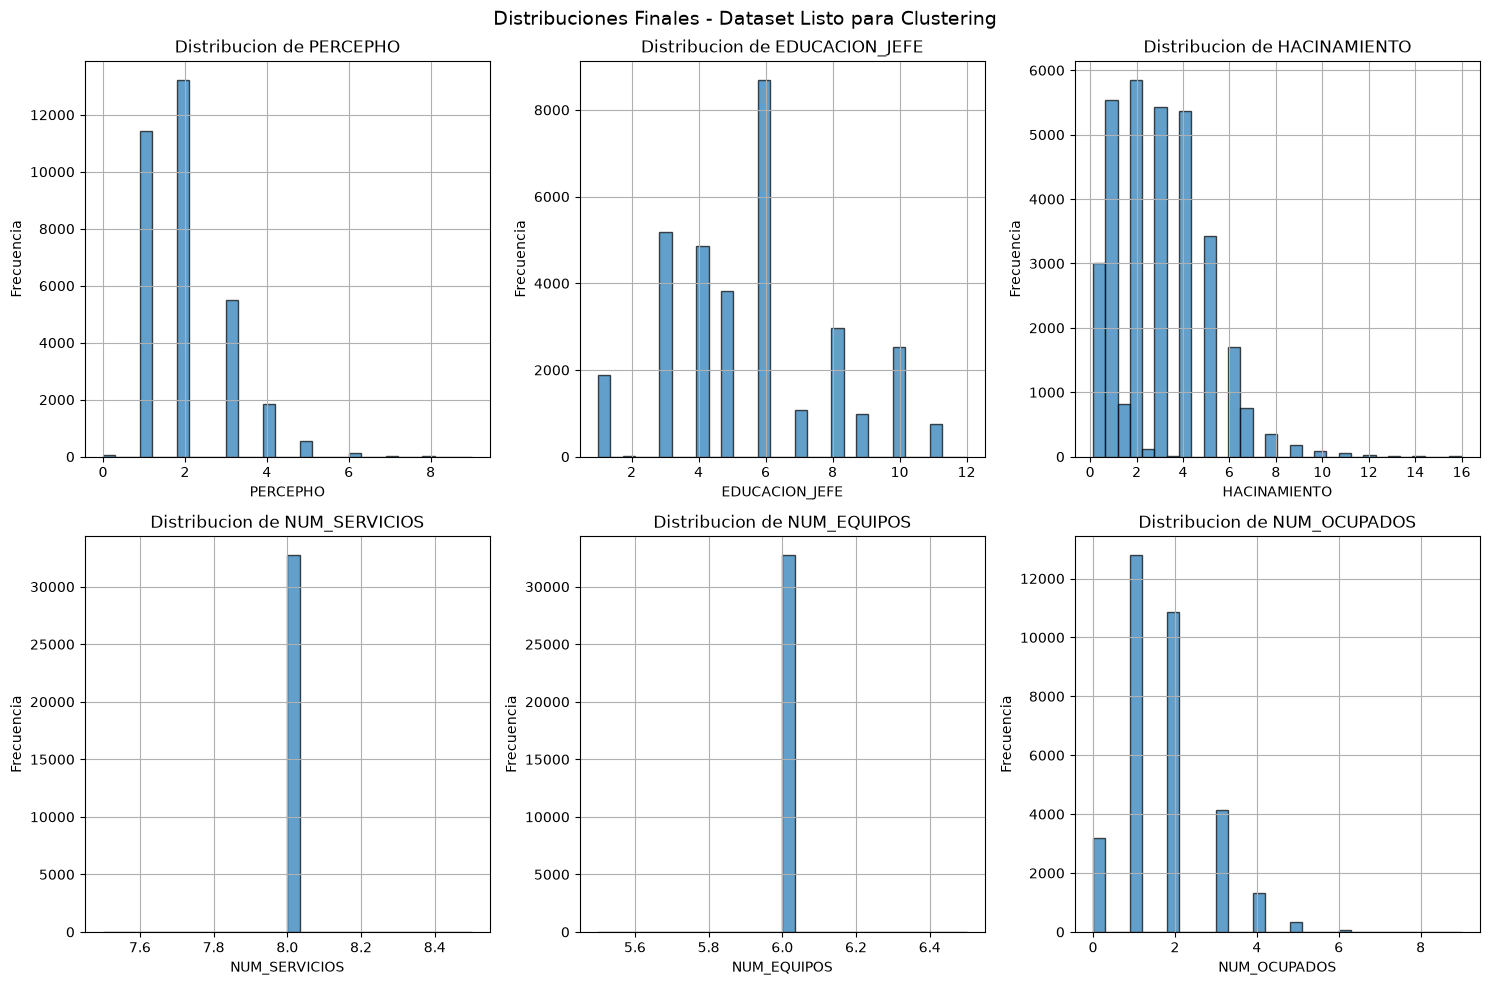

In [98]:
vars_hist = ['PERCEPHO', 'EDUCACION_JEFE', 'HACINAMIENTO', 'NUM_SERVICIOS', 'NUM_EQUIPOS', 'NUM_OCUPADOS']
vars_existentes = [var for var in vars_hist if var in df_seleccionado.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(vars_existentes):
    if i < 6:
        df_seleccionado[var].hist(bins=30, ax=axes[i], edgecolor='black', alpha=0.7)
        axes[i].set_title(f'Distribucion de {var}')
        axes[i].set_xlabel(var)
        axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribuciones Finales - Dataset Listo para Clustering', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/eda_validacion_histogramas.png', dpi=300, bbox_inches='tight')
plt.show()

### BLOQUE 4: Boxplots finales

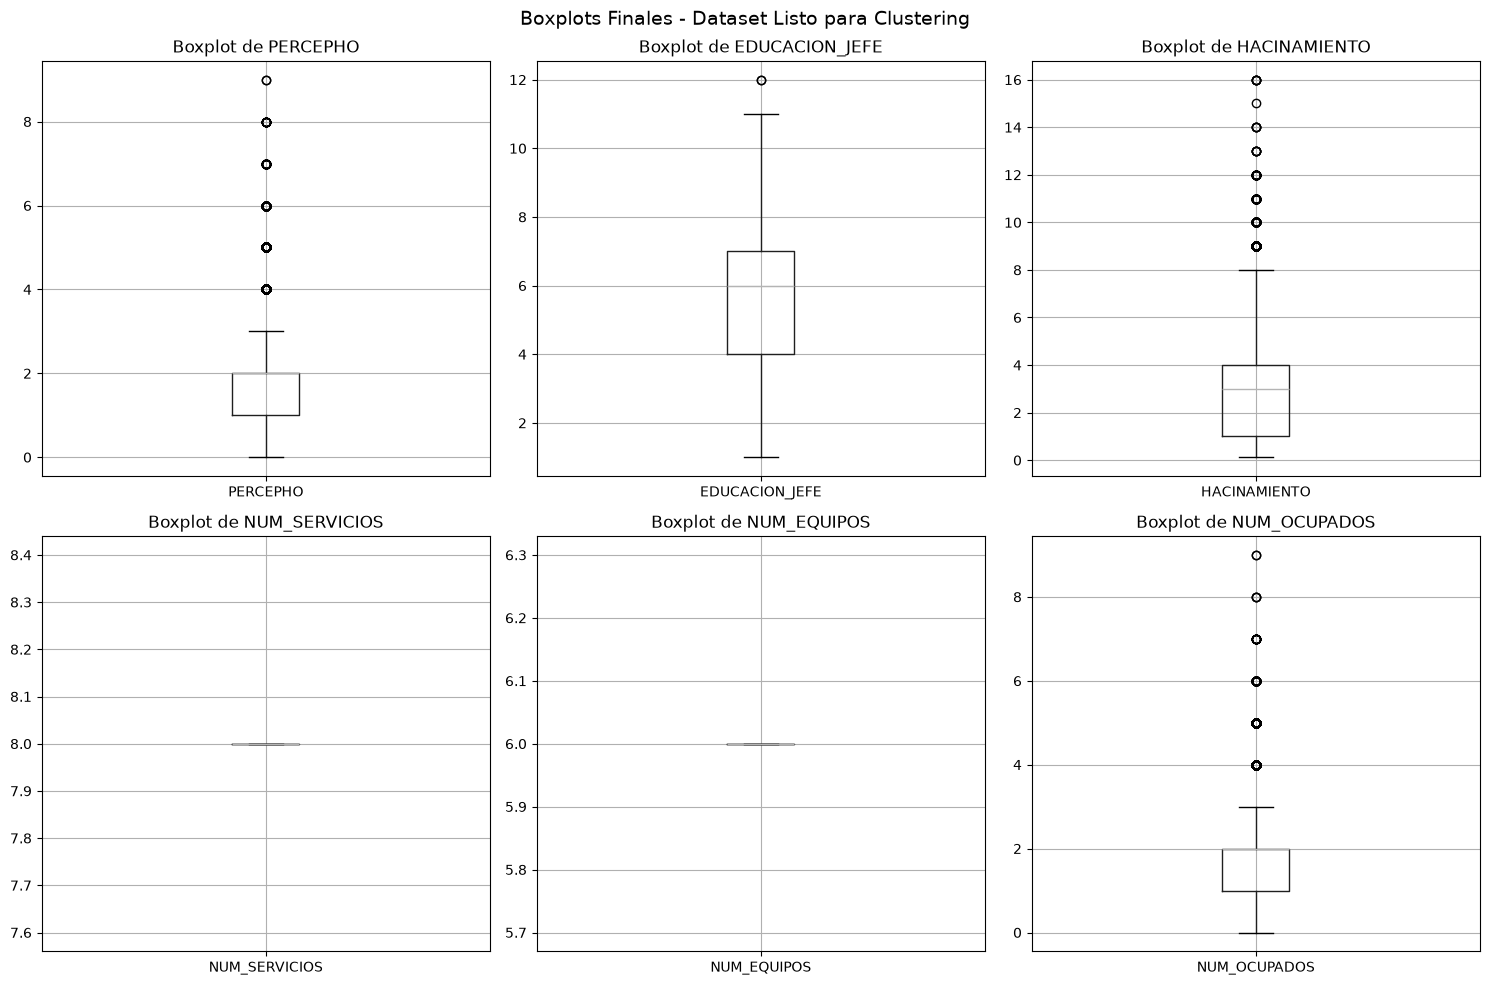

In [99]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(vars_existentes):
    if i < 6:
        df_seleccionado.boxplot(column=var, ax=axes[i])
        axes[i].set_title(f'Boxplot de {var}')

plt.suptitle('Boxplots Finales - Dataset Listo para Clustering', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/eda_validacion_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

### BLOQUE 5: Matriz de correlación

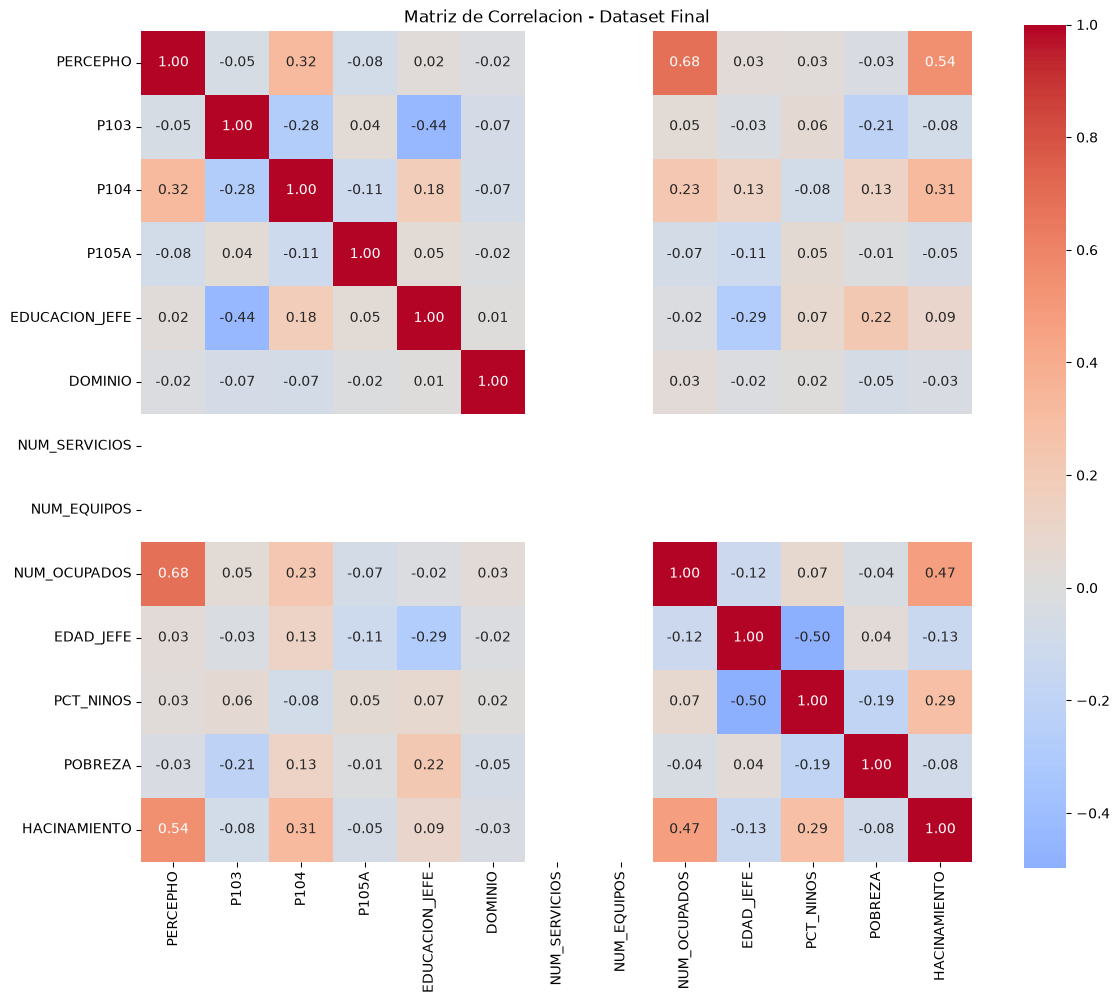

In [100]:
plt.figure(figsize=(12, 10))
corr = df_seleccionado.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Matriz de Correlacion - Dataset Final')
plt.tight_layout()
plt.savefig('../figures/eda_validacion_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

### BLOQUE 6: Resumen de calidad


In [101]:
print(f"  Filas: {df_seleccionado.shape[0]:,}")
print(f"  Columnas: {df_seleccionado.shape[1]}")
print(f"  Nulos: {df_seleccionado.isna().sum().sum()}")
print(f"  Duplicados: {df_seleccionado.duplicated().sum()}")
print(f"  Completitud: {100 - (df_seleccionado.isna().sum().sum() / (df_seleccionado.shape[0] * df_seleccionado.shape[1]) * 100):.1f}%")

print("\nVariables finales:")
for col in df_seleccionado.columns:
    print(f"  {col}")

print("\n" + "="*80)
print("PARTE 6 COMPLETADA")
print("="*80)

  Filas: 32,764
  Columnas: 13
  Nulos: 0
  Duplicados: 0
  Completitud: 100.0%

Variables finales:
  PERCEPHO
  P103
  P104
  P105A
  EDUCACION_JEFE
  DOMINIO
  NUM_SERVICIOS
  NUM_EQUIPOS
  NUM_OCUPADOS
  EDAD_JEFE
  PCT_NINOS
  POBREZA
  HACINAMIENTO

PARTE 6 COMPLETADA
